In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, accuracy_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import BayesianRidge
from sklearn.utils.class_weight import compute_class_weight
import time
import random
import keras
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix
import logging

In [3]:
tf.get_logger().setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

In [4]:
seed = 42
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

set_seed(seed)

In [5]:
experiments = [
    # plain baseline
    { 'name': '1L-64-ReLU-Adam', 'hidden_layers': 1, 'neurons': [64], 'activation': 'relu', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 32, 'optimizer': 'adam', 'lr': 1e-3 },

    # 1 layer
    { 'name': '1L-128-ReLU-Adam', 'hidden_layers': 1, 'neurons': [128], 'activation': 'relu', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 32, 'optimizer': 'adam', 'lr': 1e-3 },
    { 'name': '1L-256-ReLU-Adam', 'hidden_layers': 1, 'neurons': [256], 'activation': 'relu', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 32, 'optimizer': 'adam', 'lr': 1e-3 },

    # 2 layers
    { 'name': '2L-64-32-ReLU-Adam', 'hidden_layers': 2, 'neurons': [64, 32], 'activation': 'relu', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 32, 'optimizer': 'adam', 'lr': 1e-3 },
    { 'name': '2L-128-64-ReLU-Adam', 'hidden_layers': 2, 'neurons': [128, 64], 'activation': 'relu', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 32, 'optimizer': 'adam', 'lr': 1e-3 },
    { 'name': '2L-256-128-ReLU-Adam', 'hidden_layers': 2, 'neurons': [256, 128], 'activation': 'relu', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 32, 'optimizer': 'adam', 'lr': 1e-3 },

    # 3 layers
    { 'name': '3L-128-64-32-ReLU-Adam', 'hidden_layers': 3, 'neurons': [128, 64, 32], 'activation': 'relu', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 32, 'optimizer': 'adam', 'lr': 1e-3 },
    { 'name': '3L-256-128-64-ReLU-Adam', 'hidden_layers': 3, 'neurons': [256, 128, 64], 'activation': 'relu', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 32, 'optimizer': 'adam', 'lr': 1e-3 },

    # activation function
    { 'name': '2L-128-64-Tanh-Adam', 'hidden_layers': 2, 'neurons': [128, 64], 'activation': 'tanh', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 32, 'optimizer': 'adam', 'lr': 1e-3 },
    { 'name': '2L-128-64-ELU-Adam', 'hidden_layers': 2, 'neurons': [128, 64], 'activation': 'elu', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 32, 'optimizer': 'adam', 'lr': 1e-3 },
    { 'name': '2L-128-64-Sigmoid-Adam', 'hidden_layers': 2, 'neurons': [128, 64], 'activation': 'sigmoid', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 32, 'optimizer': 'adam', 'lr': 1e-3 },

    # dropout rate
    { 'name': '2L-128-64-ReLU-Drop0.1', 'hidden_layers': 2, 'neurons': [128, 64], 'activation': 'relu', 'dropout_rate': 0.1, 'epochs': 100, 'batch_size': 32, 'optimizer': 'adam', 'lr': 1e-3 },
    { 'name': '2L-128-64-ReLU-Drop0.5', 'hidden_layers': 2, 'neurons': [128, 64], 'activation': 'relu', 'dropout_rate': 0.5, 'epochs': 100, 'batch_size': 32, 'optimizer': 'adam', 'lr': 1e-3 },

    # optimizer
    { 'name': '2L-128-64-ReLU-SGD', 'hidden_layers': 2, 'neurons': [128, 64], 'activation': 'relu', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 32, 'optimizer': 'sgd', 'lr': 1e-3 },
    { 'name': '2L-128-64-ReLU-RMSprop', 'hidden_layers': 2, 'neurons': [128, 64], 'activation': 'relu', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 32, 'optimizer': 'rmsprop', 'lr': 1e-3 },
    { 'name': '2L-128-64-ReLU-Adamax', 'hidden_layers': 2, 'neurons': [128, 64], 'activation': 'relu', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 32, 'optimizer': 'adamax', 'lr': 1e-3 },

    # learning rate
    { 'name': '2L-128-64-ReLU-Adam-LR0.01', 'hidden_layers': 2, 'neurons': [128, 64], 'activation': 'relu', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 32, 'optimizer': 'adam', 'lr': 1e-2 },
    { 'name': '2L-128-64-ReLU-Adam-LR0.0001', 'hidden_layers': 2, 'neurons': [128, 64], 'activation': 'relu', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 32, 'optimizer': 'adam', 'lr': 1e-4 },

    # batch size
    { 'name': '2L-128-64-ReLU-Adam-Batch16', 'hidden_layers': 2, 'neurons': [128, 64], 'activation': 'relu', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 16, 'optimizer': 'adam', 'lr': 1e-3 },
    { 'name': '2L-128-64-ReLU-Adam-Batch64', 'hidden_layers': 2, 'neurons': [128, 64], 'activation': 'relu', 'dropout_rate': 0.0, 'epochs': 100, 'batch_size': 64, 'optimizer': 'adam', 'lr': 1e-3 },
]

print(f"Total experiments: {len(experiments)}")

Total experiments: 20


## Formatting Functions

In [6]:
# For readable print
def header_format(title):
  print("\n" + "=" * 55)
  print(f"{title}")
  print("=" * 55)

def print_row(idx, name, train_acc, test_acc, test_auc, test_prec, test_rec, epochs, elapsed, gap, best=False):
    flag = " ★" if best else "  "
    print(f"{idx:<3} {name:<55} "
          f"{train_acc*100:>10.2f}% "
          f"{test_acc*100:>10.2f}% "
          f"{test_auc*100:>10.2f}% "
          f"{test_prec*100:>10.2f}% "
          f"{test_rec*100:>10.2f}% "
          f"{gap*100:>8.2f}% "
          f"{epochs:>7} "
          f"{elapsed:>7.1f}s{flag}")

## Plot Functions

In [7]:
# Plot functions
def plot_training_history(history, title_suffix=""):
    fig, axes = plt.subplots(2, 3, figsize=(14, 6))
    fig.suptitle(f'Training History {title_suffix}', fontsize=14, fontweight='bold')

    metrics = [
        ('loss', 'Loss', 'Loss vs Validation Loss'),
        ('accuracy', 'Accuracy', 'Accuracy vs Validation Accuracy'),
        ('auc', 'AUC', 'AUC vs Validation AUC'),
        ('precision', 'Precision', 'Precision vs Validation Precision'),
        ('recall', 'Recall', 'Recall vs Validation Recall'),
    ]

    # Flatten axes for easy iteration
    axes_flat = axes.flatten()

    for idx, (metric, ylabel, title) in enumerate(metrics):
        ax = axes_flat[idx]

        train_key = metric
        val_key   = f'val_{metric}'

        # Check metric exists in history before plotting
        if train_key in history.history:
            ax.plot(history.history[train_key], label='Train')
        if val_key in history.history:
            ax.plot(history.history[val_key],   label='Val')

        ax.set_title(title)
        ax.set_xlabel('Epochs')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Hide the last empty subplot (2x3 grid has 6 slots, we use 5)
    axes_flat[-1].set_visible(False)

    plt.tight_layout()
    plt.show()

def class_accuracy_report(model, class_names, x_test, y_test):
    header_format("Per-Class Accuracy Report")
    preds = np.argmax(model.predict(x_test, verbose=0), axis=1)
    print(f"\n  {'Class':<14} {'Correct':>8} {'Total':>7} {'Accuracy':>10}")
    print(f"  {'─'*44}")
    for c in range(10):
        mask    = y_test == c
        correct = np.sum(preds[mask] == y_test[mask])
        total   = np.sum(mask)
        print(f"  {class_names[c]:<14} {correct:>8} {total:>7} {correct/total:>9.1%}")

## Data Loading

In [8]:
# Loading the dataset
df_original = pd.read_csv('./data/student_data.csv')
print(df_original.head())
print(df_original.shape)

df_original.drop(columns=['School'], inplace=True)

  First Term Gpa Second Term Gpa First Language  Funding  School  FastTrack  \
0              0               0              1        2       6          2   
1            2.5               2              3        4       6          1   
2           4.25        3.923077              1        1       6          2   
3       3.020833        2.321429              3        4       6          1   
4          4.275        4.326923              1        2       6          1   

   Coop  Residency  Gender Previous Education Age Group  \
0     1          1       2                  1         1   
1     2          2       2                  1         3   
2     1          1       1                  2         3   
3     2          2       2                  2         3   
4     1          1       1                  2         3   

  High School Average Mark Math Score English Grade  FirstYearPersistence  
0                       59         16             7                     1  
1                 

In [9]:
df_original.replace('?', np.nan, inplace=True)
df_original = df_original.apply(pd.to_numeric, errors='coerce')

df_original.replace('?', np.nan, inplace=True)

In [10]:
# Target
target_col = 'FirstYearPersistence'

# continuous
continuous_cols = [
    'First Term Gpa',
    'Second Term Gpa',
    'High School Average Mark',
    'Math Score'
]

# categoricals
categorical_cols = [
    'First Language',
    'Funding',
    'school',
    'FastTrack',
    'Coop',
    'Residency',
    'Gender',
    'Previous Education',
    'Age Group',
    'English Grade'
]

cols_to_scale = continuous_cols + categorical_cols 

In [11]:
# validation of values
numerical_bounds = {
    'First Term Gpa': {'min': 0.0, 'max': 4.5},
    'Second Term Gpa': {'min': 0.0, 'max': 4.5},
    'High School Average Mark': {'min': 0.0, 'max': 100.0},
    'Math Score': {'min': 0.0, 'max': 50.0}
}

for col, bounds in numerical_bounds.items():
    if col in df_original.columns:
        df_original[col] = df_original[col].clip(lower=bounds['min'], upper=bounds['max'])
        print(f"Clipped '{col}' to range {bounds['min']} - {bounds['max']}")

categorical_allowed = {
    'First Language': [1,2,3],
    'Funding': [1,2,3,4,5,6,7,8,9],
    'FastTrack': [1,2],
    'Coop': [1,2],
    'Residency': [1,2],
    'Gender': [1,2,3],
    'Previous Education': [1,2],
    'Age Group': [1,2,3,4,5,6,7,8,9,10],
    'English Grade': [1,2,3,4,5,6,7,8,9,10,11]
}

for col, allowed_values in categorical_allowed.items():
    if col in df_original.columns:
        invalid_mask = ~df_original[col].isin(allowed_values) & df_original[col].notna()
        invalid_count = invalid_mask.sum()
        print(invalid_count)
        df_original.loc[invalid_mask, col] = np.nan
        
        if invalid_count > 0:
            print(f"Wiped {invalid_count} invalid entries in '{col}' to NaN.")

Clipped 'First Term Gpa' to range 0.0 - 4.5
Clipped 'Second Term Gpa' to range 0.0 - 4.5
Clipped 'High School Average Mark' to range 0.0 - 100.0
Clipped 'Math Score' to range 0.0 - 50.0
0
0
0
0
0
0
88
Wiped 88 invalid entries in 'Previous Education' to NaN.
0
0


In [12]:
df_original['hs_avg_missing'] = df_original['High School Average Mark'].isnull().astype(int)
df_original['math_score_missing'] = df_original['Math Score'].isnull().astype(int)
flag_cols = ['hs_avg_missing', 'math_score_missing']

In [13]:
df = df_original.copy()  # Keep original for the other approaches
missing_counts = df.isnull().sum()
print(missing_counts)
missing_percentages = (missing_counts / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage Missing (%)': missing_percentages.round(2) 
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
missing_summary = missing_summary.sort_values(by='Percentage Missing (%)', ascending=False)

print(missing_summary)

First Term Gpa               17
Second Term Gpa             160
First Language              111
Funding                       0
FastTrack                     0
Coop                          0
Residency                     0
Gender                        0
Previous Education           92
Age Group                     4
High School Average Mark    743
Math Score                  462
English Grade                45
FirstYearPersistence          0
hs_avg_missing                0
math_score_missing            0
dtype: int64
                          Missing Count  Percentage Missing (%)
High School Average Mark            743                   51.70
Math Score                          462                   32.15
Second Term Gpa                     160                   11.13
First Language                      111                    7.72
Previous Education                   92                    6.40
English Grade                        45                    3.13
First Term Gpa             

## Understanding first what type of imputation are suitable

## IMPUTATION FUNCTIONS

In [14]:
def simulation_of_missingness(df_temp, column, percentage, is_categorical=False):
    rnd = np.random.RandomState(42)
    df_known = df_temp[df_temp[column].notna()].copy()
    missing_mask = rnd.rand(len(df_known)) < percentage
    true_values  = df_known.loc[missing_mask, column].values

    df_test = df_known.copy()
    df_test.loc[missing_mask, column] = np.nan

    print(f"\nSimulated missing rows: {missing_mask.sum()}")
    if is_categorical:
        print(f"True value distribution: \n{pd.Series(true_values).value_counts()}")
    else:
        print(f"True values for Mean:   {true_values.mean():.4f}")
        print(f"True values for Median: {np.median(true_values):.4f}")

    print('\n')
    
    return df_known, df_test, missing_mask, true_values

# ------------------------------------------------------------------------------------------------------------------------------------------
def mode_imputer(df_temp, column, missing_mask, true_values, is_categorical=False):
    imputer = SimpleImputer(strategy='most_frequent')
    df_mode = df_temp[[column]].copy()
    df_mode_imputed = pd.DataFrame(
        imputer.fit_transform(df_mode),
        columns=df_mode.columns,
        index=df_mode.index
    )

    mode_preds = df_mode_imputed.loc[missing_mask, column].values

    if is_categorical:
        mode_acc = accuracy_score(true_values, mode_preds)
        print(f"Mode Imputation Accuracy: {mode_acc:.4f}")
    else:
        mode_rmse = np.sqrt(mean_squared_error(true_values, mode_preds))
        mode_mae = mean_absolute_error(true_values, mode_preds)
        print(f"Mode Imputation RMSE: {mode_rmse:.4f} with MAE: {mode_mae:.4f}")

# ------------------------------------------------------------------------------------------------------------------------------------------
def median_imputer(df_temp, column, missing_mask, true_values, is_categorical=False):
    imputer = SimpleImputer(strategy='median')
    df_median = df_temp[[column]].copy()
    df_median_imputed = pd.DataFrame(
        imputer.fit_transform(df_median),
        columns=df_median.columns,
        index=df_median.index
    )

    if is_categorical:
        df_median_imputed[column] = df_median_imputed[column].round().astype(int)
        median_preds = df_median_imputed.loc[missing_mask, column].values
        median_acc = accuracy_score(true_values, median_preds)
        print(f"Median Imputation Accuracy: {median_acc:.4f}")
    else:
        median_preds = df_median_imputed.loc[missing_mask, column].values
        median_rmse  = np.sqrt(mean_squared_error(true_values, median_preds))
        median_mae   = mean_absolute_error(true_values, median_preds)
        print(f"Median RMSE: {median_rmse:.4f} with MAE: {median_mae:.4f}")

# ------------------------------------------------------------------------------------------------------------------------------------------
def knn_imputer(df_temp, feature_cols, column, missing_mask, true_values, neighbors=5, weights='uniform', is_categorical=False):
    minmax_scaler = MinMaxScaler()
    df_knn = df_temp[feature_cols].copy()
    df_knn_scaled = pd.DataFrame(
        minmax_scaler.fit_transform(df_knn[feature_cols]),
        columns=feature_cols,
        index=df_knn.index
    )

    knn_imputer = KNNImputer(n_neighbors=neighbors, weights=weights)
    df_knn_imputed = pd.DataFrame(
        knn_imputer.fit_transform(df_knn_scaled),
        columns=feature_cols,
        index=df_knn.index
    )

    df_knn_inversed = pd.DataFrame(
        minmax_scaler.inverse_transform(df_knn_imputed),
        columns=feature_cols,
        index=df_knn.index
    )
    knn_preds = df_knn_inversed.loc[missing_mask, column].round().astype(int).values

    if is_categorical:
        knn_acc = accuracy_score(true_values, knn_preds)
        print(f"KNN Imputation Accuracy ({neighbors} neighbors, {weights} weights): {knn_acc:.4f}")
    else:
        knn_rmse = np.sqrt(mean_squared_error(true_values, knn_preds))
        knn_mae = mean_absolute_error(true_values, knn_preds)
        print(f"KNN Imputation RMSE: {knn_rmse:.4f} with MAE: {knn_mae:.4f}")

# ------------------------------------------------------------------------------------------------------------------------------------------
def rf_imputer(df_temp, feature_cols, column, missing_mask, true_values, is_categorical=False):
    df_rf = df_temp.copy()
    feature_cols_rf = [col for col in feature_cols if col != column]
    observed = df_rf[column].notna()

    X_train_rf = df_rf.loc[observed, feature_cols_rf]
    y_train_rf = df_rf.loc[observed, column]
    X_pred_rf  = df_rf.loc[missing_mask, feature_cols_rf]

    if is_categorical:
        rf_cls = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_cls.fit(X_train_rf, y_train_rf)
        rf_preds = rf_cls.predict(X_pred_rf)
        rf_acc   = accuracy_score(true_values, rf_preds)
        print(f"RF Classifier Accuracy: {rf_acc:.4f}")
    else:
        rf_cls = RandomForestRegressor(n_estimators=100, random_state=42)
        rf_cls.fit(X_train_rf, y_train_rf)
        rf_preds = rf_cls.predict(X_pred_rf)
        rf_rmse  = np.sqrt(mean_squared_error(true_values, rf_preds))
        rf_mae   = mean_absolute_error(true_values, rf_preds)
        print(f"RF Regressor RMSE: {rf_rmse:.4f} with MAE: {rf_mae:.4f}")

# ------------------------------------------------------------------------------------------------------------------------------------------
def iterative_imputer(df_temp, feature_cols_iter, column, missing_mask, true_values, estimator, estimater_name):
    iter_bay = IterativeImputer(
        estimator=estimator,
        max_iter=20, # 10 is too small to converge
        random_state=42
    )
    df_iter_bay = df_temp[feature_cols_iter].copy()
    df_iter_bay_imputed = pd.DataFrame(
        iter_bay.fit_transform(df_iter_bay),
        columns=feature_cols_iter,
        index=df_iter_bay.index
    )
    iter_bay_preds = df_iter_bay_imputed.loc[missing_mask, column].values
    iter_bay_rmse  = np.sqrt(mean_squared_error(true_values, iter_bay_preds))
    iter_bay_mae   = mean_absolute_error(true_values, iter_bay_preds)
    print(f"IterativeImputer ({estimater_name}) RMSE: {iter_bay_rmse:.4f} with MAE: {iter_bay_mae:.4f}")


## PREDICTION FUNCTIONS

In [15]:
def apply_rf_imputation(df, feature_cols, column_to_be_imputed, is_categorical=False):
    df_temp = df.copy()
    existing_data = df_temp[column_to_be_imputed].notna()
    missing_data = df_temp[column_to_be_imputed].isna()
    feature_cols_rf = [col for col in feature_cols if col != column_to_be_imputed]
    X_train_rf = df_temp.loc[existing_data, feature_cols_rf]
    y_train_rf = df_temp.loc[existing_data, column_to_be_imputed]

    X_pred_rf = df_temp.loc[missing_data, feature_cols_rf]
    if is_categorical:
        rf_cls = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_cls.fit(X_train_rf, y_train_rf)
        predicted = rf_cls.predict(X_pred_rf)
        df_temp.loc[missing_data, column_to_be_imputed] = predicted
    else:
        rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
        rf_reg.fit(X_train_rf, y_train_rf)
        predicted = rf_reg.predict(X_pred_rf)
        df_temp.loc[missing_data, column_to_be_imputed] = predicted
    return df_temp

def apply_iterative_imputation(df, feature_cols_iter, column_to_be_imputed):
    df_temp = df.copy()
    iter_bay = IterativeImputer(
        estimator=BayesianRidge(),
        max_iter=20,
        tol=1e-2,
        random_state=42
    )

    # Fit and transform only the relevant columns
    df_iter_cols = df_temp[feature_cols_iter].copy()
    df_iter_imputed = pd.DataFrame(
        iter_bay.fit_transform(df_iter_cols),
        columns=feature_cols_iter,
        index=df_iter_cols.index
    )

    # Fill only the specified column back into original df
    df_temp[column_to_be_imputed] = df_iter_imputed[column_to_be_imputed]
    return df_temp

## Approach #1 : Attempt to handle missing data by simulation

In [16]:
# As the result of above code snippet, 'Age Group' have 0.28 percent of missing data or 4 entries in the dataset.
# Since it is quite small, I'll apply siimple mode imputation to these two columns.
age_group_mode = df['Age Group'].mode()[0]
df['Age Group'] = df['Age Group'].fillna(age_group_mode)

print('\nValidation after imputation:')
print(df['Age Group'].isnull().sum())


Validation after imputation:
0


In [17]:
# Same with 'Age Group', the percentage for 'First Term Gpa' is also quite small.
column_to_be_imputed = 'First Term Gpa'
print(df[column_to_be_imputed].describe())
print(f"Mean: {df[column_to_be_imputed].mean():.4f}")
print(f"Median: {df[column_to_be_imputed].median():.4f}")
print(f"Skew: {df[column_to_be_imputed].skew():.4f}")
print(f"Missing count: {df[column_to_be_imputed].isnull().sum()}")

# 'First Term Gpa' is a little skewed, applying median mputation would be more appropriate.
first_term_median = df[column_to_be_imputed].median()
df[column_to_be_imputed] = df[column_to_be_imputed].fillna(first_term_median)
print('\nValidation after imputation:')
print(df[column_to_be_imputed].isnull().sum())

count    1420.000000
mean        2.846073
std         1.175098
min         0.000000
25%         2.250000
50%         3.102632
75%         3.739130
max         4.500000
Name: First Term Gpa, dtype: float64
Mean: 2.8461
Median: 3.1026
Skew: -0.9499
Missing count: 17

Validation after imputation:
0


In [18]:
# 'English Grade' has around 3.13% of missing data.
# One thing I noted is that this is an ordinal column

# I wanted to compare different imputation methods for 'English Grade'
# This is done so by using the rows where there is actual data and removing the English Grade value and is saved as a true value for comparison...
column_to_be_imputed = 'English Grade'
df_known, df_test, missing_mask, true_values = simulation_of_missingness(df, column_to_be_imputed, percentage=0.0313, is_categorical=True) # 3.13% missing data

# mode imputation
mode_imputer(df_test, column_to_be_imputed, missing_mask, true_values, is_categorical=True)

# median imputation
median_imputer(df_test, column_to_be_imputed, missing_mask, true_values, is_categorical=True)

# knn imputation
feature_cols = ['First Term Gpa', 'Age Group', 'English Grade', 'Funding', 'FastTrack', 'Coop', 'Residency', 'Gender']
knn_imputer(df_test, feature_cols, column_to_be_imputed, missing_mask, true_values, neighbors=11, weights='distance', is_categorical=True)

english_grade_mode = df[column_to_be_imputed].mode()[0]
df[column_to_be_imputed] = df[column_to_be_imputed].fillna(english_grade_mode)
print('\nValidation after imputation:')
print(df[column_to_be_imputed].isnull().sum())

# The results are not that high, with mode having the highest accuracy.
# Still thinking if I should drop it or apply the mode imputation


Simulated missing rows: 45
True value distribution: 
9.0     14
7.0      9
10.0     8
8.0      7
4.0      4
3.0      2
2.0      1
Name: count, dtype: int64


Mode Imputation Accuracy: 0.3111
Median Imputation Accuracy: 0.1556
KNN Imputation Accuracy (11 neighbors, distance weights): 0.2667

Validation after imputation:
0


In [19]:
# 'Previous Education' has 6.40% missing rows
print(df['Previous Education'].value_counts().sort_index())
print(df['Previous Education'].value_counts(normalize=True))
print(df.groupby('Previous Education')['FirstYearPersistence'].mean())
column_to_be_imputed = 'Previous Education'

feature_cols = ['First Term Gpa', 'Previous Education', 'Age Group', 'English Grade', 'Funding', 'FastTrack', 'Coop', 'Residency', 'Gender']
df_known, df_test, missing_mask, true_values = simulation_of_missingness(df, column_to_be_imputed, percentage=0.0640, is_categorical=True)

# mode imputation
mode_imputer(df_test, column_to_be_imputed, missing_mask, true_values, is_categorical=True)

# knn imputation
knn_imputer(df_test, feature_cols, column_to_be_imputed, missing_mask, true_values, neighbors=11, weights='distance', is_categorical=True)

# rf imputation
rf_imputer(df_test, feature_cols, column_to_be_imputed, missing_mask, true_values, is_categorical=True)

# apply rf imputation
df = apply_rf_imputation(df, feature_cols, column_to_be_imputed, is_categorical=True)

Previous Education
1.0    863
2.0    482
Name: count, dtype: int64
Previous Education
1.0    0.641636
2.0    0.358364
Name: proportion, dtype: float64
Previous Education
1.0    0.772885
2.0    0.852697
Name: FirstYearPersistence, dtype: float64

Simulated missing rows: 89
True value distribution: 
1.0    59
2.0    30
Name: count, dtype: int64


Mode Imputation Accuracy: 0.6629
KNN Imputation Accuracy (11 neighbors, distance weights): 0.6742
RF Classifier Accuracy: 0.7079


In [20]:
# 'First Language' has around 7.72% of missing data.
column_to_be_imputed = 'First Language'
print(df[column_to_be_imputed].value_counts())
print(df[column_to_be_imputed].value_counts(normalize=True))
print(df.groupby(column_to_be_imputed)[ 'FirstYearPersistence'].mean())

df_known, df_test, missing_mask, true_values = simulation_of_missingness(df, column_to_be_imputed, percentage=0.0772, is_categorical=True) # 7.72% missing data

# mode imputation
print('\n')
mode_imputer(df_test, column_to_be_imputed, missing_mask, true_values, is_categorical=True)

# knn imputation
feature_cols = ['First Term Gpa', 'English Grade', 'Previous Education', 'Age Group', 'Funding', 'FastTrack', 'Coop', 'Residency', 'Gender', column_to_be_imputed]
knn_imputer(df_test, feature_cols, column_to_be_imputed, missing_mask, true_values, neighbors=5, weights='distance', is_categorical=True)

# rf classifier imputation
rf_imputer(df_test, feature_cols, column_to_be_imputed, missing_mask, true_values, is_categorical=True)

# APplying the RF Classifier imputation since it has the highest accuracy
df = apply_rf_imputation(df, feature_cols, column_to_be_imputed, is_categorical=True)

print('\nValidation after imputation:')
print(df[column_to_be_imputed].isnull().sum())

First Language
1.0    720
3.0    602
2.0      4
Name: count, dtype: int64
First Language
1.0    0.542986
3.0    0.453997
2.0    0.003017
Name: proportion, dtype: float64
First Language
1.0    0.713889
2.0    0.500000
3.0    0.868771
Name: FirstYearPersistence, dtype: float64

Simulated missing rows: 109
True value distribution: 
1.0    67
3.0    42
Name: count, dtype: int64




Mode Imputation Accuracy: 0.6147
KNN Imputation Accuracy (5 neighbors, distance weights): 0.8257
RF Classifier Accuracy: 0.9174

Validation after imputation:
0


In [21]:
# 'Second Term Gpa' has around 11.13% of missing data, which is quite high.
column_to_be_imputed = 'Second Term Gpa'
print(df[column_to_be_imputed].describe())
print(f"\nMean: {df[column_to_be_imputed].mean():.4f}")
print(f"Median: {df[column_to_be_imputed].median():.4f}")
print(f"Skew: {df[column_to_be_imputed].skew():.4f}")
print(f"\nCorrelation with First Term GPA: {df[column_to_be_imputed].corr(df['First Term Gpa']):.4f}")
print(f"Correlation with Persistence: {df[column_to_be_imputed].corr(df['FirstYearPersistence']):.4f}")

feature_cols = ['First Term Gpa', 'English Grade', 'Previous Education', 'Age Group', 'Funding', 'FastTrack', 'Coop', 'Residency', 'Gender', 'First Language', column_to_be_imputed]

df_known, df_test, missing_mask, true_values = simulation_of_missingness(df, column_to_be_imputed, percentage=0.1113, is_categorical=False) # 11.13% missing data

# median imputation
median_imputer(df_test, column_to_be_imputed, missing_mask, true_values, is_categorical=False)

# knn imputation
knn_imputer(df_test, feature_cols, column_to_be_imputed, missing_mask, true_values, neighbors=5, weights='distance', is_categorical=False)

# rf regressor imputation
rf_imputer(df_test, feature_cols, column_to_be_imputed, missing_mask, true_values, is_categorical=False)

# Applying RF Regressor imputation since it has the lowest RMSE and MAE
df = apply_rf_imputation(df, feature_cols, column_to_be_imputed, is_categorical=False)

print('\nValidation after imputation:')
print(df[column_to_be_imputed].isnull().sum())


count    1277.000000
mean        2.820176
std         1.128632
min         0.000000
25%         2.260000
50%         3.027778
75%         3.680000
max         4.500000
Name: Second Term Gpa, dtype: float64

Mean: 2.8202
Median: 3.0278
Skew: -0.9157

Correlation with First Term GPA: 0.8047
Correlation with Persistence: 0.3950

Simulated missing rows: 153
True values for Mean:   2.7857
True values for Median: 2.9583


Median RMSE: 1.1971 with MAE: 0.9149
KNN Imputation RMSE: 0.8919 with MAE: 0.6430
RF Regressor RMSE: 0.6963 with MAE: 0.5099

Validation after imputation:
0


In [22]:
# 'Math Score' has around 32.15% of missing data 
column_to_be_imputed = 'Math Score'
feature_cols = ['First Term Gpa', 'English Grade', 'Previous Education', 'Age Group', 'Funding', 'FastTrack', 'Coop', 'Residency', 'Gender', 'First Language', 'Second Term Gpa', column_to_be_imputed]
feature_cols_iterative = feature_cols + ['High School Average Mark']

print(df[column_to_be_imputed].describe())
print(f"\nMean: {df[column_to_be_imputed].mean():.4f}")
print(f"Median: {df[column_to_be_imputed].median():.4f}")
print(f"Skew: {df[column_to_be_imputed].skew():.4f}")

print(f"\nCorrelation with First Term GPA: {df[column_to_be_imputed].corr(df['First Term Gpa']):.4f}")
print(f"Correlation with Second Term GPA: {df[column_to_be_imputed].corr(df['Second Term Gpa']):.4f}")
print(f"Correlation with Persistence: {df[column_to_be_imputed].corr(df['FirstYearPersistence']):.4f}")

print(f"\nMissing count: {df[column_to_be_imputed].isnull().sum()}")
print(f"Missing %: {df[column_to_be_imputed].isnull().mean()*100:.2f}%")

df_known, df_test, missing_mask, true_values = simulation_of_missingness(df, column_to_be_imputed, percentage=0.3215, is_categorical=False) # 32.15% missing data

# median imputation
median_imputer(df_test, column_to_be_imputed, missing_mask, true_values, is_categorical=False)

# knn imputation
knn_imputer(df_test, feature_cols, column_to_be_imputed, missing_mask, true_values, neighbors=5, weights='distance', is_categorical=False)

# rf regressor imputation
rf_imputer(df_test, feature_cols, column_to_be_imputed, missing_mask, true_values, is_categorical=False)

# iterative imputer Bayesian Ridge
iterative_imputer(df_test, feature_cols_iterative, column_to_be_imputed, missing_mask, true_values, estimator=BayesianRidge(), estimater_name='BayesianRidge')

# iterative imputer Random Forest
# I tried but it wont converge at all. Skipping this estimator.
#iterative_imputer(df_test, feature_cols_iterative, column_to_be_imputed, missing_mask, true_values, estimator=RandomForestRegressor(n_estimators=100, random_state=42), estimater_name='RandomForestRegressor')

# apply iterative imputer
df = apply_iterative_imputation(df, feature_cols_iterative, column_to_be_imputed)
print('\nValidation after imputation:')
print(df[column_to_be_imputed].isnull().sum())

count    975.000000
mean      32.557949
std       10.709458
min        6.000000
25%       23.000000
50%       32.000000
75%       43.000000
max       50.000000
Name: Math Score, dtype: float64

Mean: 32.5579
Median: 32.0000
Skew: -0.0306

Correlation with First Term GPA: 0.4538
Correlation with Second Term GPA: 0.4626
Correlation with Persistence: 0.2373

Missing count: 462
Missing %: 32.15%

Simulated missing rows: 326
True values for Mean:   31.8620
True values for Median: 31.0000


Median RMSE: 10.5541 with MAE: 9.2239
KNN Imputation RMSE: 8.8255 with MAE: 6.8712
RF Regressor RMSE: 8.6425 with MAE: 6.8603
IterativeImputer (BayesianRidge) RMSE: 8.3457 with MAE: 6.6469

Validation after imputation:
0


In [23]:
#'High School Average Mark' has around 51.70% of missing data
print(df['High School Average Mark'].describe())
print(f"\nMean: {df['High School Average Mark'].mean():.4f}")
print(f"Median: {df['High School Average Mark'].median():.4f}")
print(f"Skew: {df['High School Average Mark'].skew():.4f}")
print(f"\nCorrelation with First Term GPA: {df['High School Average Mark'].corr(df['First Term Gpa']):.4f}")
print(f"Correlation with Second Term GPA: {df['High School Average Mark'].corr(df['Second Term Gpa']):.4f}")
print(f"Correlation with Math Score: {df['High School Average Mark'].corr(df['Math Score']):.4f}")
print(f"Correlation with Persistence: {df['High School Average Mark'].corr(df['FirstYearPersistence']):.4f}")

column_to_be_imputed = 'High School Average Mark'
feature_cols = ['First Term Gpa', 'English Grade', 'Previous Education', 'Age Group', 'Funding', 'FastTrack', 'Coop', 'Residency', 'Gender', 'First Language', 'Second Term Gpa', 'Math Score', column_to_be_imputed]
df_known, df_test, missing_mask, true_values = simulation_of_missingness(df, column_to_be_imputed, percentage=0.5170, is_categorical=False) # 51.70% missing data

# median imputation
median_imputer(df_test, column_to_be_imputed, missing_mask, true_values, is_categorical=False)

# knn imputation
knn_imputer(df_test, feature_cols, column_to_be_imputed, missing_mask, true_values, neighbors=5, weights='distance', is_categorical=False)

# rf regressor
rf_imputer(df_test, feature_cols, column_to_be_imputed, missing_mask, true_values, is_categorical=False)

# iterative imputer Bayesian Ridge
iterative_imputer(df_test, feature_cols, column_to_be_imputed, missing_mask, true_values, estimator=BayesianRidge(), estimater_name='BayesianRidge')

# iterative imputer Random Forest
iterative_imputer(df_test, feature_cols_iterative, column_to_be_imputed, missing_mask, true_values, estimator=RandomForestRegressor(n_estimators=100, random_state=42), estimater_name='RandomForestRegressor')

# apply iterative imputer with bayesian ridge
df = apply_iterative_imputation(df, feature_cols_iterative, column_to_be_imputed)
df[column_to_be_imputed] = df[column_to_be_imputed].clip(lower=0.0, upper=100.0)
print('\nValidation after imputation:')
print(df[column_to_be_imputed].isnull().sum())


count    694.000000
mean      77.082133
std       11.922569
min       17.000000
25%       70.000000
50%       77.500000
75%       85.000000
max      100.000000
Name: High School Average Mark, dtype: float64

Mean: 77.0821
Median: 77.5000
Skew: -0.4806

Correlation with First Term GPA: 0.5750
Correlation with Second Term GPA: 0.5524
Correlation with Math Score: 0.5850
Correlation with Persistence: 0.2678

Simulated missing rows: 359
True values for Mean:   77.1838
True values for Median: 78.0000


Median RMSE: 11.6750 with MAE: 9.2312
KNN Imputation RMSE: 8.6686 with MAE: 6.7214
RF Regressor RMSE: 8.7438 with MAE: 6.8426
IterativeImputer (BayesianRidge) RMSE: 8.4088 with MAE: 6.4905
IterativeImputer (RandomForestRegressor) RMSE: 8.7438 with MAE: 6.8426

Validation after imputation:
0


In [24]:
# final check
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

First Term Gpa              0
Second Term Gpa             0
First Language              0
Funding                     0
FastTrack                   0
Coop                        0
Residency                   0
Gender                      0
Previous Education          0
Age Group                   0
High School Average Mark    0
Math Score                  0
English Grade               0
FirstYearPersistence        0
hs_avg_missing              0
math_score_missing          0
dtype: int64

Total missing values: 0


# Model training

## Model Functions

In [ ]:
def select_features_phik(df, target_col, threshold=0.25, exclude_cols=None, verbose=False):

    if exclude_cols is None:
        exclude_cols = []

    exclude_cols = list(set(exclude_cols + [target_col]))
    feature_cols = [c for c in df.columns if c not in exclude_cols]

    cols_to_use = feature_cols + [target_col]
    phik_corr = df[cols_to_use].phik_matrix()

    # Extract correlations with target only
    phik_scores  = phik_corr[target_col].drop(target_col)
    phik_scores  = phik_scores.sort_values(ascending=False)

    # Select features above threshold
    selected_features = phik_scores[phik_scores >= threshold].index.tolist()

    if verbose:
        header_format(f"Phik Correlation with '{target_col}'")

        plt.figure(figsize=(15, 8))
        sns.heatmap(phik_scores.to_frame(), annot=True, cmap='coolwarm', vmin=0, vmax=1)
        plt.title('Phik Correlation Matrix')
        plt.show()
        
        print(f"{'='*55}")
        print(f"Threshold: {threshold}")
        print(f"Selected features: {len(selected_features)}")
        print(f"Excluded features: {len(phik_scores) - len(selected_features)}")
        print(f"{'='*55}")
        print(f"\nSelected: {selected_features}")

    return selected_features, phik_scores

def get_best_result(results):
    valid_results = [r for r in results if r['test_rec'] < 1.0]
    
    if not valid_results:
        print("WARNING  experiments collapsed to 100% recall!")
        print("Falling back to highest AUC regardless of recall...")
        return max(results, key=lambda x: x['test_auc'])
    
    # Among valid results pick best AUC
    best = max(valid_results, key=lambda x: x['test_auc'])
    collapsed = len(results) - len(valid_results)
    if collapsed > 0:
        print(f"{collapsed} experiment(s) excluded due to 100% recall")
    
    return best

def build_model(input_dim, hidden_layers, neurons, activation, dropout_rate=0.3):
    model = keras.Sequential(name="StudentSuccess")
    model.add(layers.Input(shape=(input_dim,)))

    # Batch normalise the input
    model.add(layers.BatchNormalization())

    for i in range(hidden_layers):
        n = neurons[i] if i < len(neurons) else neurons[-1]
        model.add(layers.Dense(n, activation=activation))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))

    # sigmoid for binary classification
    model.add(layers.Dense(1, activation='sigmoid'))

    return model


def get_optimizer(name, lr):
    if name == 'sgd':
        return keras.optimizers.SGD(learning_rate=lr)
    elif name == 'adam':
        return keras.optimizers.Adam(learning_rate=lr)
    elif name == 'rmsprop':
        return keras.optimizers.RMSprop(learning_rate=lr)
    elif name == 'adamax':
        return keras.optimizers.Adamax(learning_rate=lr)
    else:
        raise ValueError(f"Unsupported optimizer: {name}")


def train_experiment(exp, X_train, y_train, X_test, y_test, class_weight_dict):
    set_seed(42)
    keras.backend.clear_session()
    header_format(f"Running {exp['name']}...")
    input_dim = X_train.shape[1]
    model = build_model(
        input_dim=input_dim,
        hidden_layers=exp['hidden_layers'],
        neurons=exp['neurons'],
        activation=exp['activation'],
        dropout_rate=exp['dropout_rate']
    )

    model.compile(
        optimizer=get_optimizer(exp['optimizer'], exp['lr']),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            'accuracy'
        ]
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=10,
            restore_best_weights=True,
            mode='max'
        )
    ]

    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=exp['epochs'],
        batch_size=exp['batch_size'],
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=0
    )
    end_time = time.time()
    elapsed  = end_time - start_time


    best_ep = int(np.argmax(history.history['val_auc']))
    best_train_acc  = history.history['accuracy'][best_ep]
    best_train_auc  = history.history['auc'][best_ep]
    best_train_prec = history.history['precision'][best_ep]
    best_train_rec  = history.history['recall'][best_ep]
    test_loss, test_auc, test_prec, test_rec, test_acc = model.evaluate(
        X_test, y_test, verbose=0)

    epochs_run = len(history.history['loss'])
    gap        = abs(best_train_acc - test_acc)

    return (model,
            best_train_acc, best_train_auc, best_train_prec, best_train_rec,
            test_acc, test_auc, test_prec, test_rec,
            epochs_run, elapsed, history, gap)


def run_experiments(experiments, X_train, y_train, X_test, y_test, class_weight_dict, plot_history=True):
    results         = []
    best_experiment = None

    for idx, exp in enumerate(experiments, 1):
        (model,
         train_acc, train_auc, train_prec, train_rec,
         test_acc,  test_auc,  test_prec,  test_rec,
         epochs_run, elapsed, history, gap) = train_experiment(
            exp, X_train, y_train, X_test, y_test, class_weight_dict)

        results.append({
            'experiment': exp['name'],
            'train_acc':  train_acc,
            'train_auc':  train_auc,
            'train_prec': train_prec,
            'train_rec':  train_rec,
            'test_acc':   test_acc,
            'test_auc':   test_auc,
            'test_prec':  test_prec,
            'test_rec':   test_rec,
            'epochs_run': epochs_run,
            'elapsed':    elapsed,
            'gap':        gap
        })

        if plot_history:
            plot_training_history(history, title_suffix=f"({exp['name']})")

    # Best experiment by test_auc — most reliable metric
    best_result = get_best_result(results) #max(results, key=lambda x: x['test_auc'])
    best_experiment = next(
        exp for exp in experiments if exp['name'] == best_result['experiment'])

    header_format("Experiments Results")
    print(f"{'#':<3} {'Experiment':<55} "
          f"{'Train Acc':>10} "
          f"{'Test Acc':>10} "
          f"{'Test AUC':>10} "
          f"{'Precision':>10} "
          f"{'Recall':>10} "
          f"{'Gap':>8} "
          f"{'Epochs':>7} "
          f"{'Time':>8}")
    print(f"{'-'*145}")

    for idx, result in enumerate(results, 1):
        print_row(
            idx,
            result['experiment'],
            result['train_acc'],
            result['test_acc'],
            result['test_auc'],
            result['test_prec'],
            result['test_rec'],
            result['epochs_run'],
            result['elapsed'],
            result['gap'],
            best=result['experiment'] == best_result['experiment']
        )

    return model, best_result, best_experiment

## Start Training for approach 1

In [26]:
df['Average Gpa'] = (df['First Term Gpa'] + df['Second Term Gpa']) / 2

print("Average GPA distribution:")
print(df['Average Gpa'].describe())

for threshold in [1.5, 2.0, 2.5, 3.0]:
    gpa_pass = (df['Average Gpa'] >= threshold).sum()
    combined = ((df['Average Gpa'] >= threshold) & 
                (df['FirstYearPersistence'] == 1)).sum()
    print(f"\nThreshold GPA >= {threshold}:")
    print(f"  GPA only:          {gpa_pass} students ({gpa_pass/len(df)*100:.1f}%)")
    print(f"  GPA + Persistence: {combined} students ({combined/len(df)*100:.1f}%)")


Average GPA distribution:
count    1437.000000
mean        2.757712
std         1.141767
min         0.000000
25%         2.139620
50%         2.969461
75%         3.635416
max         4.500000
Name: Average Gpa, dtype: float64

Threshold GPA >= 1.5:
  GPA only:          1218 students (84.8%)
  GPA + Persistence: 1078 students (75.0%)

Threshold GPA >= 2.0:
  GPA only:          1117 students (77.7%)
  GPA + Persistence: 1009 students (70.2%)

Threshold GPA >= 2.5:
  GPA only:          958 students (66.7%)
  GPA + Persistence: 875 students (60.9%)

Threshold GPA >= 3.0:
  GPA only:          704 students (49.0%)
  GPA + Persistence: 661 students (46.0%)


In [27]:
threshold = 2.5

df['Student_Success'] = ((df['Average Gpa'] >= threshold) & (df['FirstYearPersistence'] == 1)).astype(int)

# Verify distribution
print("Student Success Distribution:")
print(df['Student_Success'].value_counts())
print(df['Student_Success'].value_counts(normalize=True))

# Cross check with components
print(f"\nBreakdown:")
print(f"Persisted AND GPA >= {threshold}: {(df['Student_Success']==1).sum()}")
print(f"Did not persist:                  {(df['FirstYearPersistence']==0).sum()}")
print(f"Persisted but low GPA:            {((df['FirstYearPersistence']==1) & (df['Average Gpa'] < threshold)).sum()}")
print(f"Did not persist but high GPA:     {((df['FirstYearPersistence']==0) & (df['Average Gpa'] >= threshold)).sum()}")

Student Success Distribution:
Student_Success
1    875
0    562
Name: count, dtype: int64
Student_Success
1    0.608907
0    0.391093
Name: proportion, dtype: float64

Breakdown:
Persisted AND GPA >= 2.5: 875
Did not persist:                  299
Persisted but low GPA:            263
Did not persist but high GPA:     83


interval columns not set, guessing: ['First Term Gpa', 'First Language', 'Funding', 'FastTrack', 'Coop', 'Residency', 'Gender', 'Previous Education', 'Age Group', 'High School Average Mark', 'Math Score', 'English Grade', 'Student_Success']

Phik Correlation with 'Student_Success'


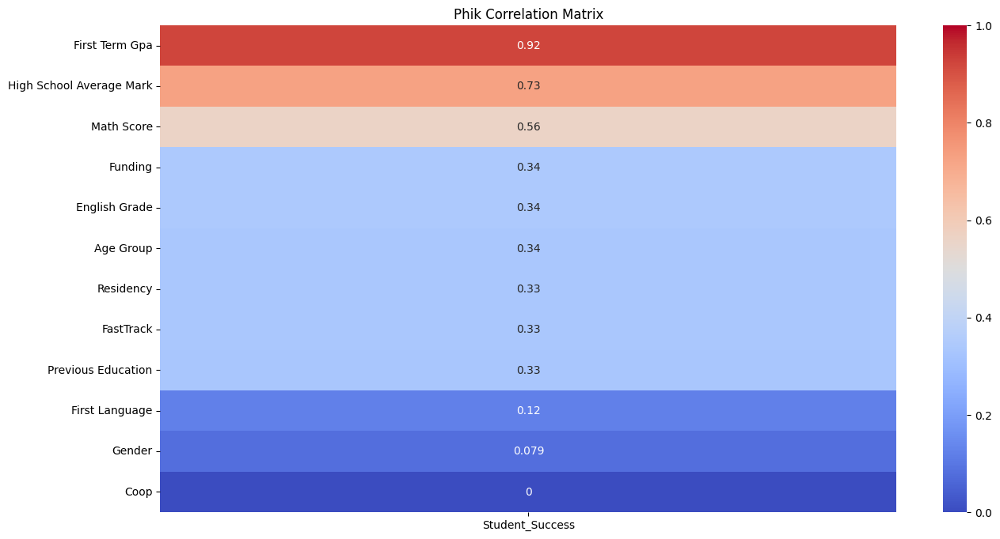

Threshold: 0.25
Selected features: 9
Excluded features: 3

Selected: ['First Term Gpa', 'High School Average Mark', 'Math Score', 'Funding', 'English Grade', 'Age Group', 'Residency', 'FastTrack', 'Previous Education']


In [28]:
always_exclude = [
    'Student_Success',      # target
    'FirstYearPersistence', # used to create target
    'Average Gpa',          # used to create target
    'Second Term Gpa',      # used to create Average GPA
    'hs_avg_missing',       # flag columns
    'math_score_missing'
]

features_success, scores_success = select_features_phik(
    df=df,
    target_col='Student_Success',
    threshold=0.25,
    exclude_cols=always_exclude,
    verbose=True
)

In [29]:
target_column = 'Student_Success'
X = df[features_success]
y = df[target_column]

# Attempt to handle class imbalance with class weights
classes = np.unique(y)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
class_weight_dict = dict(zip(classes, class_weights))

print(f"\nClasses: {classes}")
print(f"\nClass Weights: {class_weight_dict}")


Classes: [0 1]

Class Weights: {np.int64(0): np.float64(1.2784697508896796), np.int64(1): np.float64(0.8211428571428572)}


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain persistence rate: {y_train.mean():.2%}")
print(f"Test persistence rate:  {y_test.mean():.2%}")

Train: (1149, 9), Test: (288, 9)

Train persistence rate: 60.92%
Test persistence rate:  60.76%


In [31]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Running 1L-64-ReLU-Adam...


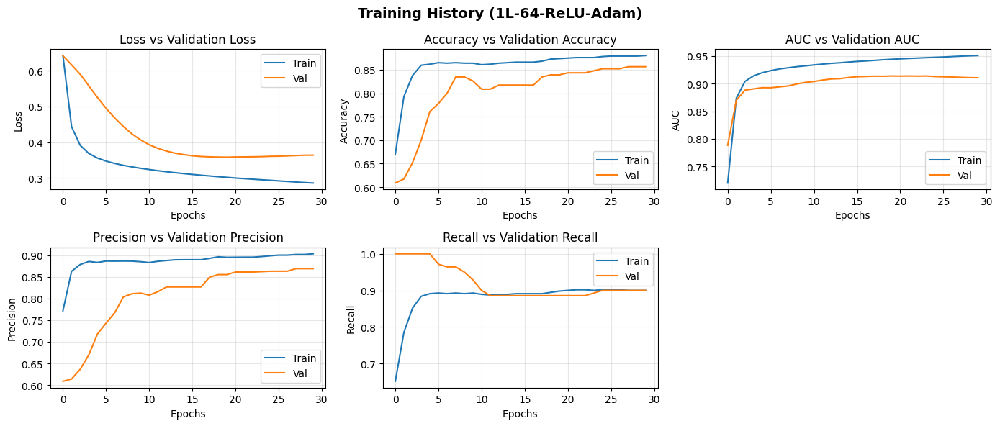


Running 1L-128-ReLU-Adam...


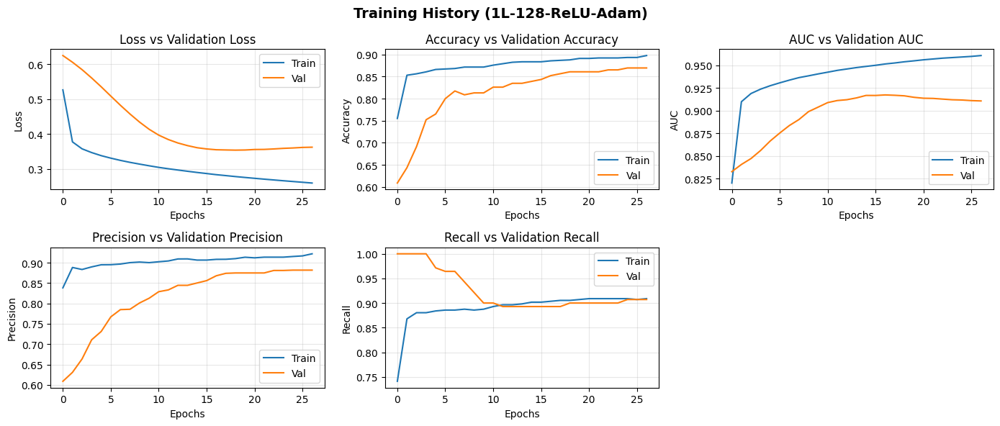


Running 1L-256-ReLU-Adam...


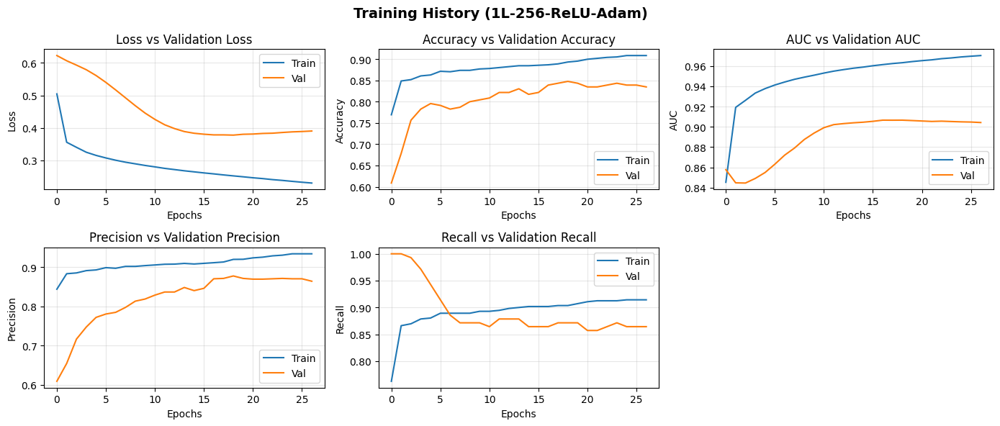


Running 2L-64-32-ReLU-Adam...


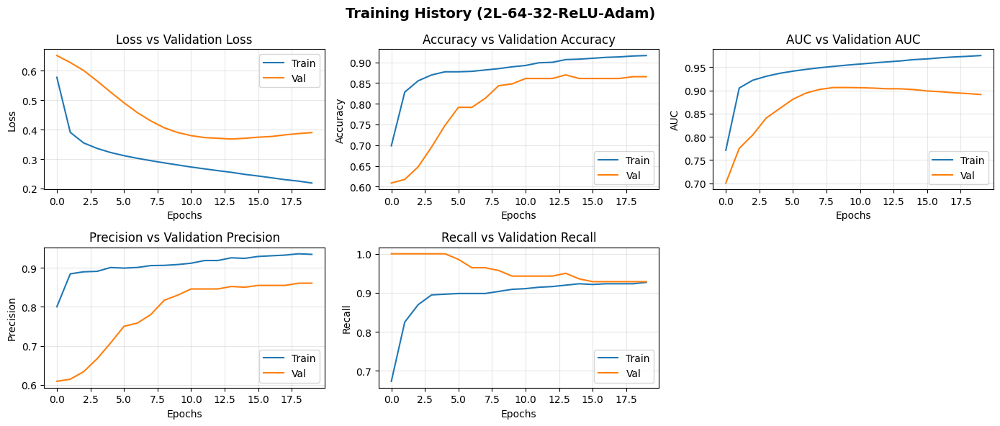


Running 2L-128-64-ReLU-Adam...


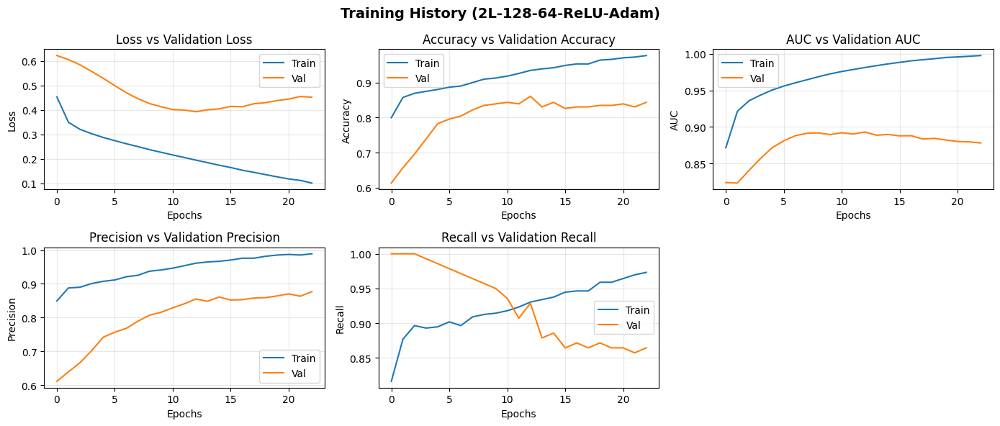


Running 2L-256-128-ReLU-Adam...


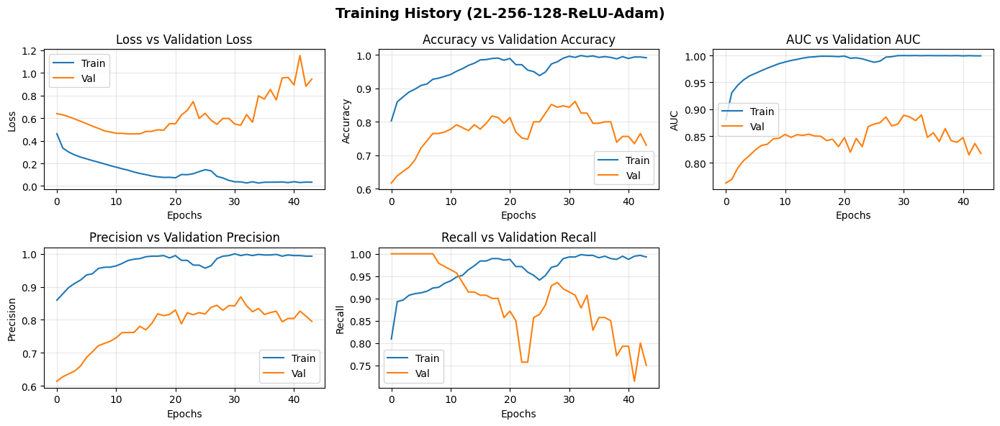


Running 3L-128-64-32-ReLU-Adam...


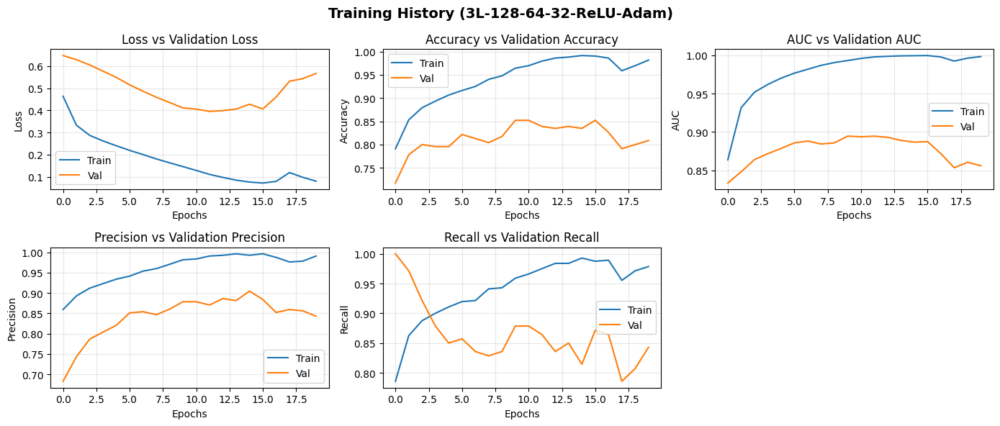


Running 3L-256-128-64-ReLU-Adam...


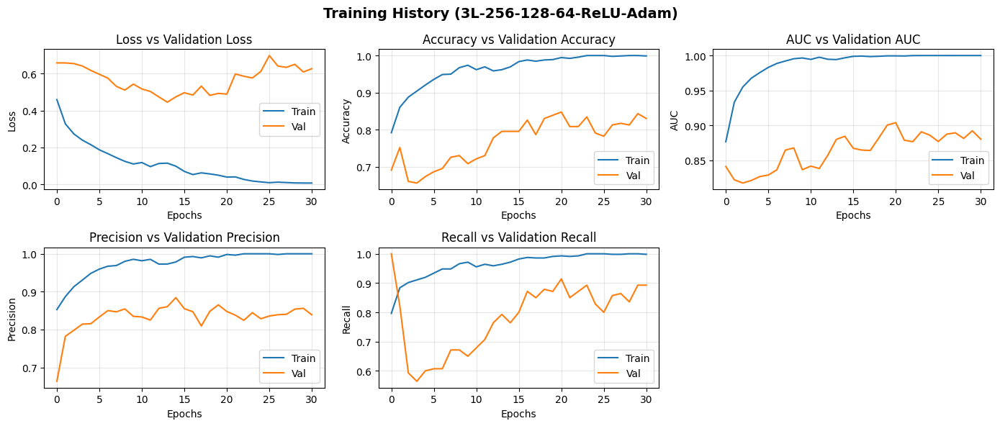


Running 2L-128-64-Tanh-Adam...


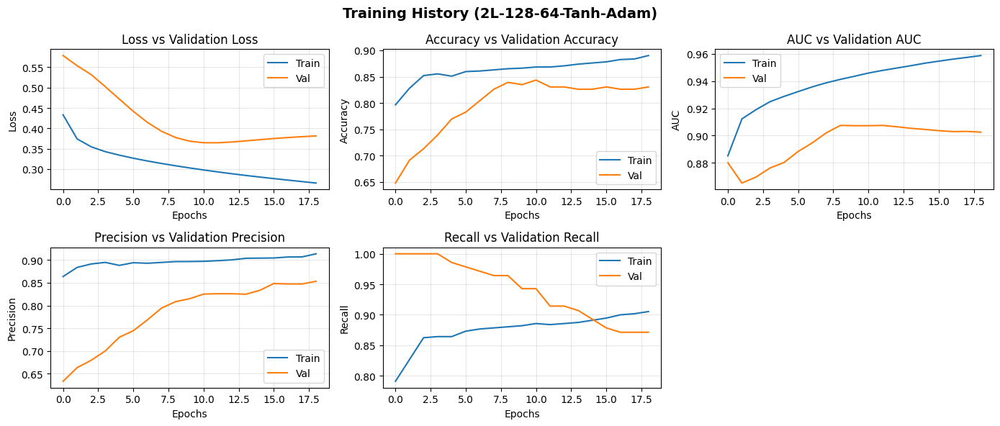


Running 2L-128-64-ELU-Adam...


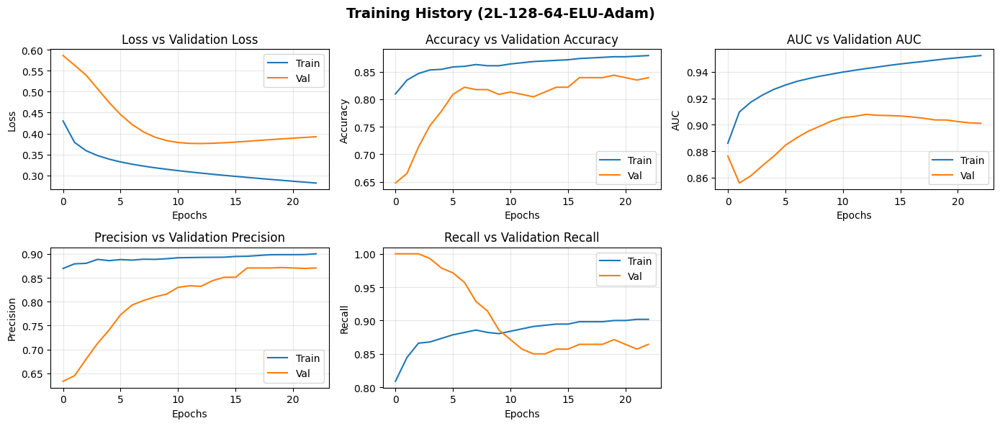


Running 2L-128-64-Sigmoid-Adam...


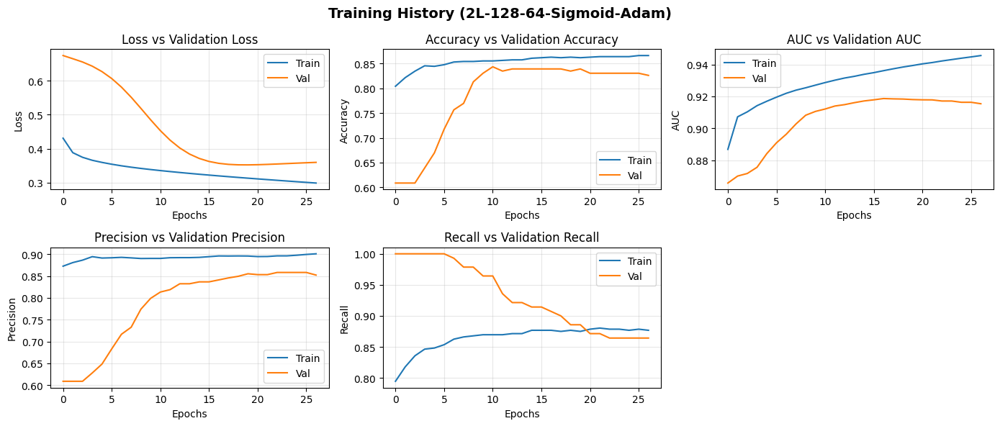


Running 2L-128-64-ReLU-Drop0.1...


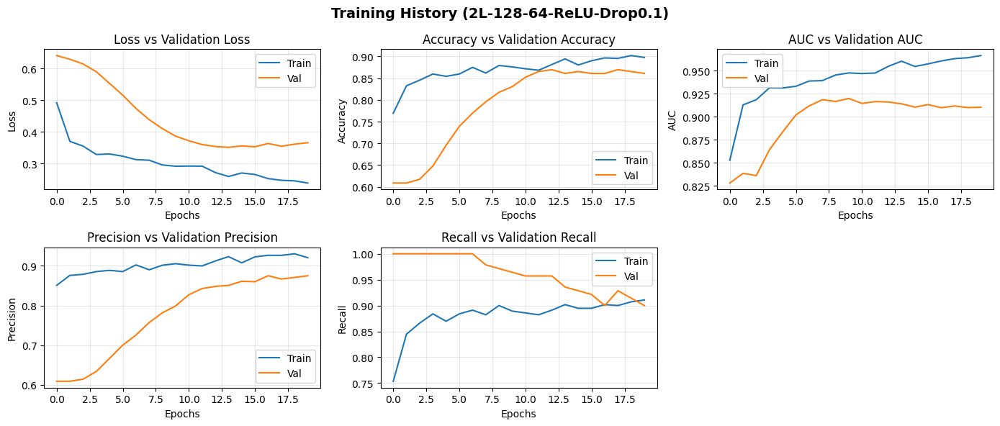


Running 2L-128-64-ReLU-Drop0.5...


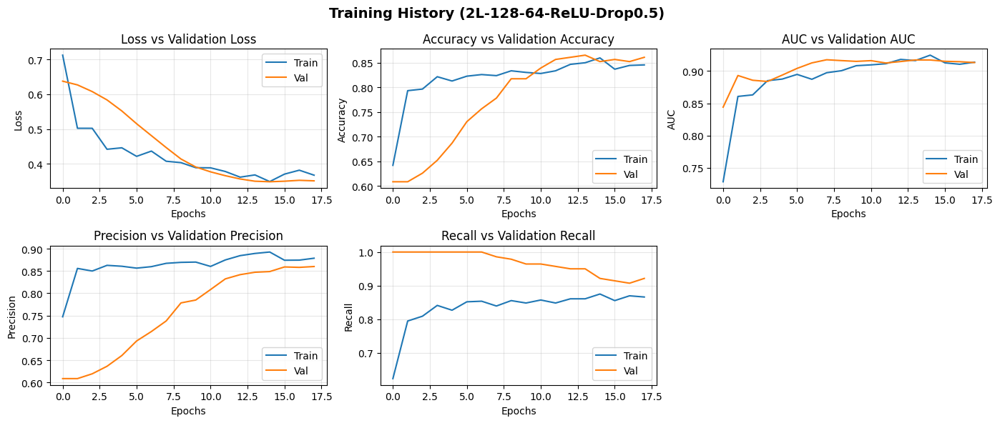


Running 2L-128-64-ReLU-SGD...


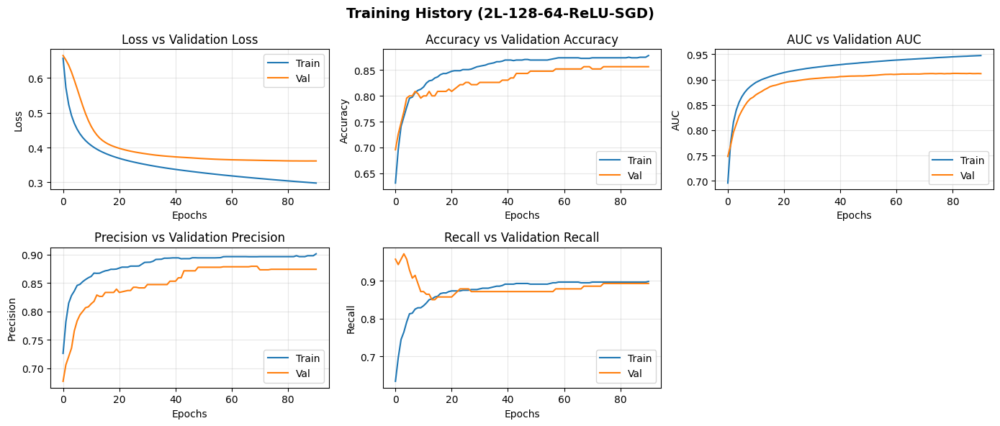


Running 2L-128-64-ReLU-RMSprop...


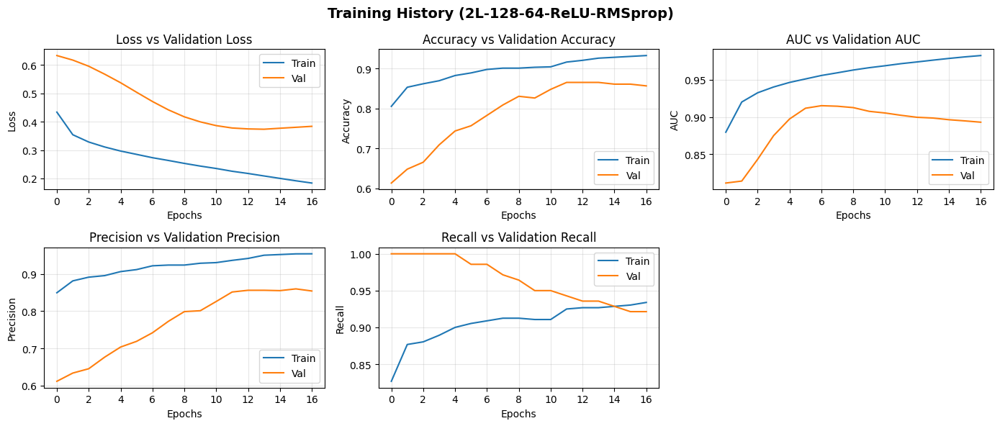


Running 2L-128-64-ReLU-Adamax...


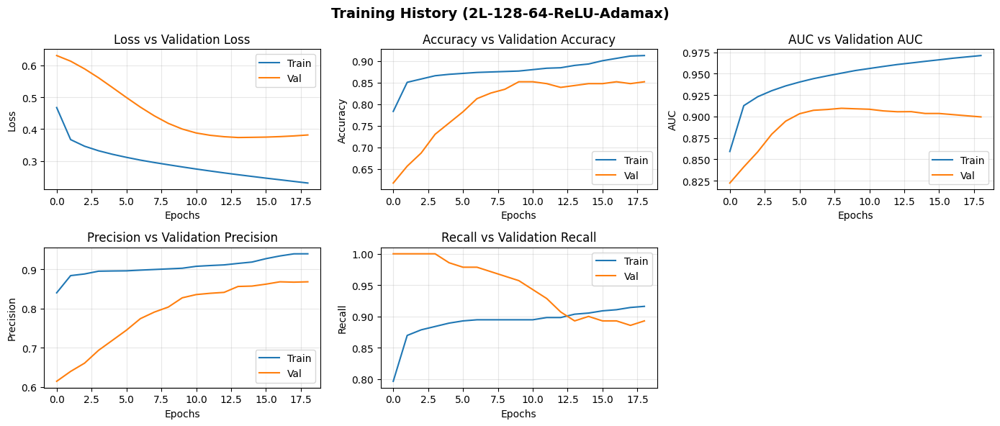


Running 2L-128-64-ReLU-Adam-LR0.01...


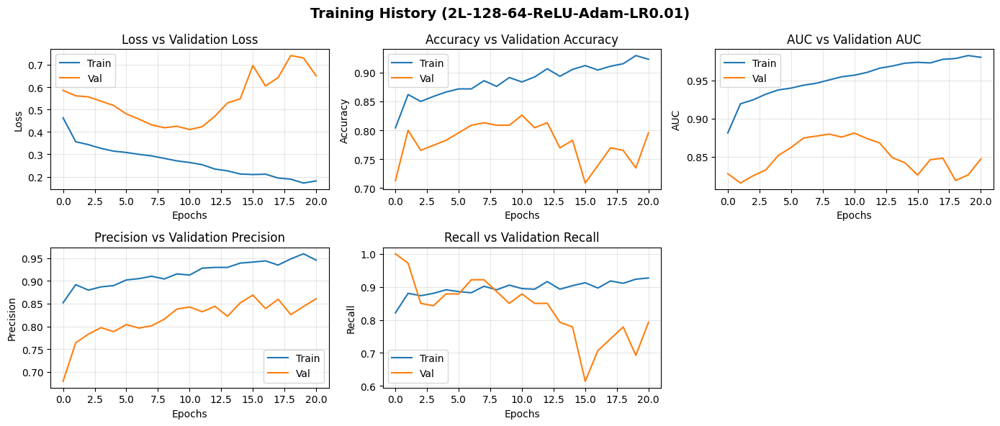


Running 2L-128-64-ReLU-Adam-LR0.0001...


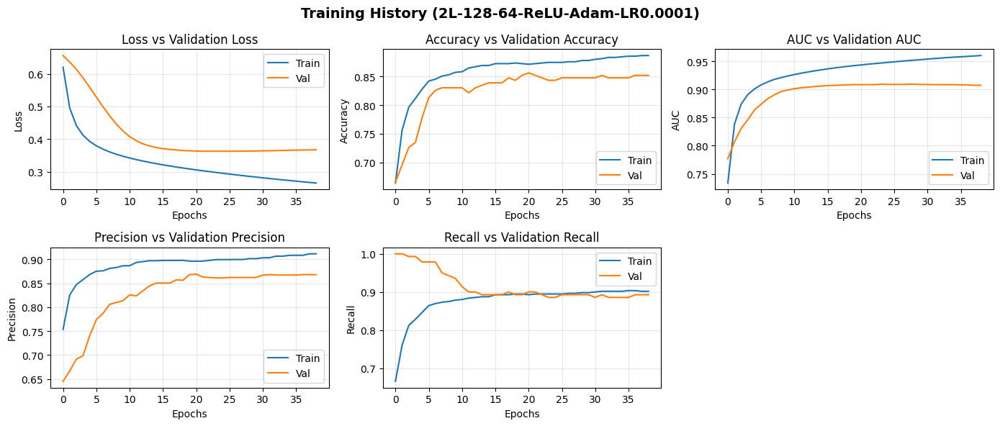


Running 2L-128-64-ReLU-Adam-Batch16...


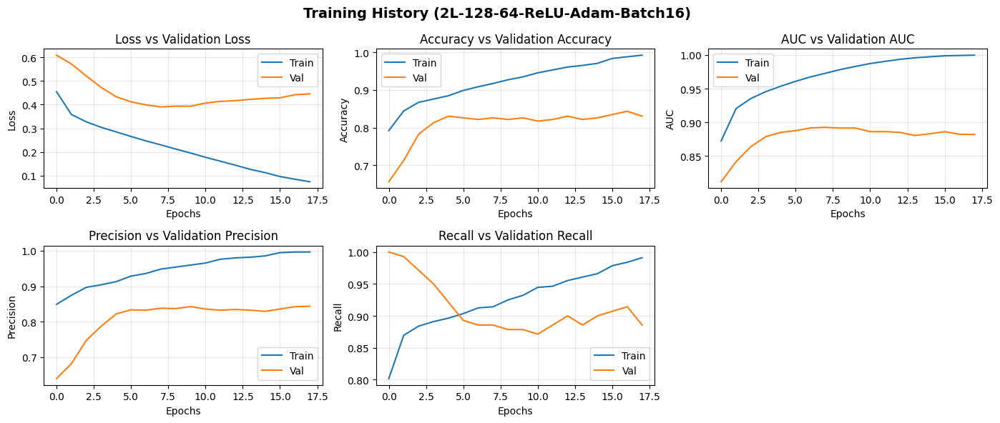


Running 2L-128-64-ReLU-Adam-Batch64...


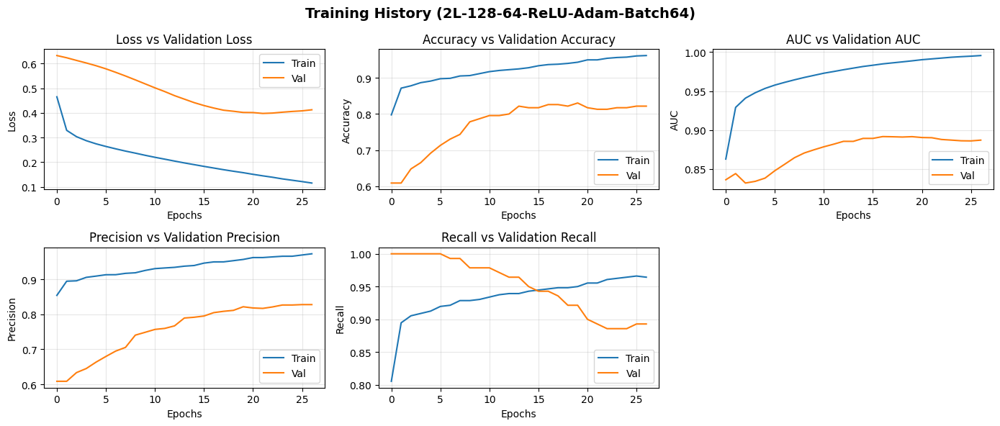


Experiments Results
#   Experiment                                               Train Acc   Test Acc   Test AUC  Precision     Recall      Gap  Epochs     Time
-------------------------------------------------------------------------------------------------------------------------------------------------
1   1L-64-ReLU-Adam                                              87.38%      87.50%      94.60%      87.98%      92.00%     0.12%      30     2.5s ★
2   1L-128-ReLU-Adam                                             88.57%      87.50%      93.79%      87.17%      93.14%     1.07%      27     2.4s  
3   1L-256-ReLU-Adam                                             88.68%      86.46%      93.42%      87.36%      90.86%     2.23%      27     2.3s  
4   2L-64-32-ReLU-Adam                                           88.90%      86.81%      92.54%      83.09%      98.29%     2.10%      20     2.1s  
5   2L-128-64-ReLU-Adam                                          93.47%      85.07%      91.95% 

In [32]:
a1_model, a1_best_architecture_results, a1_best_architecture_exp_parameters = run_experiments(experiments, X_train_scaled, y_train, X_test_scaled, y_test, class_weight_dict, plot_history=True)

## Approach #2: Drop All Rows with Missing Values

In [33]:
print(df_original.isnull().sum())

First Term Gpa               17
Second Term Gpa             160
First Language              111
Funding                       0
FastTrack                     0
Coop                          0
Residency                     0
Gender                        0
Previous Education           92
Age Group                     4
High School Average Mark    743
Math Score                  462
English Grade                45
FirstYearPersistence          0
hs_avg_missing                0
math_score_missing            0
dtype: int64


In [34]:
print(f"Total rows:           {len(df_original)}")
print(f"Rows with no missing: {df_original.dropna().shape[0]}")
print(f"Rows dropped:         {len(df_original) - df_original.dropna().shape[0]}")
print(f"Percentage lost:      {(len(df_original) - df_original.dropna().shape[0]) / len(df_original) * 100:.2f}%")

df_dropped = df_original.dropna().copy()
print(f"\nTarget distribution after dropping:")
print(df_dropped['FirstYearPersistence'].value_counts())
print(df_dropped['FirstYearPersistence'].value_counts(normalize=True))
print(f"Shape after dropping: {df_dropped.shape}")

Total rows:           1437
Rows with no missing: 470
Rows dropped:         967
Percentage lost:      67.29%

Target distribution after dropping:
FirstYearPersistence
1    391
0     79
Name: count, dtype: int64
FirstYearPersistence
1    0.831915
0    0.168085
Name: proportion, dtype: float64
Shape after dropping: (470, 16)


Average GPA distribution:
count    470.000000
mean       2.660931
std        1.091020
min        0.000000
25%        1.948012
50%        2.805182
75%        3.466055
max        4.500000
Name: Average Gpa, dtype: float64

Threshold GPA >= 1.5:
  GPA only:          397 students (84.5%)
  GPA + Persistence: 360 students (76.6%)

Threshold GPA >= 2.0:
  GPA only:          345 students (73.4%)
  GPA + Persistence: 318 students (67.7%)

Threshold GPA >= 2.5:
  GPA only:          291 students (61.9%)
  GPA + Persistence: 270 students (57.4%)

Threshold GPA >= 3.0:
  GPA only:          194 students (41.3%)
  GPA + Persistence: 185 students (39.4%)
Student Success Distribution:
Student_Success
1    270
0    200
Name: count, dtype: int64
Student_Success
1    0.574468
0    0.425532
Name: proportion, dtype: float64

Breakdown:
Persisted AND GPA >= 2.5: 270
Did not persist:                  79
Persisted but low GPA:            121
Did not persist but high GPA:     21
interval columns not set, guess

/Users/phoenix/.pyenv/versions/3.12.5/lib/python3.12/site-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable FastTrack for analysis 1. Dropping this column
  warnings.warn(


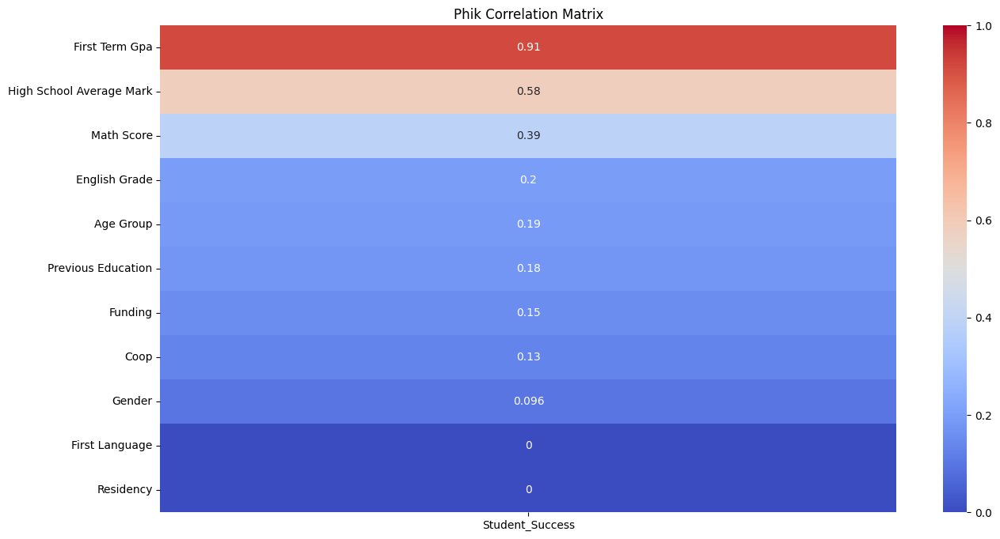

Threshold: 0.25
Selected features: 3
Excluded features: 8

Selected: ['First Term Gpa', 'High School Average Mark', 'Math Score']


In [35]:
df_dropped['Average Gpa'] = (df_dropped['First Term Gpa'] + df_dropped['Second Term Gpa']) / 2

print("Average GPA distribution:")
print(df_dropped['Average Gpa'].describe())

for threshold in [1.5, 2.0, 2.5, 3.0]:
    gpa_pass = (df_dropped['Average Gpa'] >= threshold).sum()
    combined = ((df_dropped['Average Gpa'] >= threshold) & 
                (df_dropped['FirstYearPersistence'] == 1)).sum()
    print(f"\nThreshold GPA >= {threshold}:")
    print(f"  GPA only:          {gpa_pass} students ({gpa_pass/len(df_dropped)*100:.1f}%)")
    print(f"  GPA + Persistence: {combined} students ({combined/len(df_dropped)*100:.1f}%)")

threshold = 2.5

df_dropped['Student_Success'] = ((df_dropped['Average Gpa'] >= threshold) & (df_dropped['FirstYearPersistence'] == 1)).astype(int)

# Verify distribution
print("Student Success Distribution:")
print(df_dropped['Student_Success'].value_counts())
print(df_dropped['Student_Success'].value_counts(normalize=True))

# Cross check with components
print(f"\nBreakdown:")
print(f"Persisted AND GPA >= {threshold}: {(df_dropped['Student_Success']==1).sum()}")
print(f"Did not persist:                  {(df_dropped['FirstYearPersistence']==0).sum()}")
print(f"Persisted but low GPA:            {((df_dropped['FirstYearPersistence']==1) & (df_dropped['Average Gpa'] < threshold)).sum()}")
print(f"Did not persist but high GPA:     {((df_dropped['FirstYearPersistence']==0) & (df_dropped['Average Gpa'] >= threshold)).sum()}")

always_exclude = [
    'Student_Success',      # target
    'FirstYearPersistence', # used to create target
    'Average Gpa',          # used to create target
    'Second Term Gpa',      # used to create Average GPA
    'hs_avg_missing',       # flag columns
    'math_score_missing'
]

features_success, scores_success = select_features_phik(
    df=df_dropped,
    target_col='Student_Success',
    threshold=0.25,
    exclude_cols=always_exclude,
    verbose=True
)

In [36]:
X_drop = df_dropped[features_success]
y_drop = df_dropped[target_column]

classes_drop = np.unique(y_drop)
weights_drop = compute_class_weight(class_weight='balanced', classes=classes_drop, y=y_drop)
cw_drop = dict(zip(classes_drop, weights_drop))

print(f"\nClass weights: {cw_drop}")
print(f"Dropout weight: {cw_drop[0]:.4f}")
print(f"Persist weight: {cw_drop[1]:.4f}")


Class weights: {np.int64(0): np.float64(1.175), np.int64(1): np.float64(0.8703703703703703)}
Dropout weight: 1.1750
Persist weight: 0.8704


In [37]:
X_train_drop, X_test_drop, y_train_drop, y_test_drop = train_test_split(X_drop, y_drop, test_size=0.2, random_state=42, stratify=y_drop)
print(f"Train persistence rate: {y_train_drop.mean():.2%}")
print(f"Test persistence rate:  {y_test_drop.mean():.2%}")

Train persistence rate: 57.45%
Test persistence rate:  57.45%


In [38]:
scaler_drop      = MinMaxScaler()
X_train_drop_sc  = scaler_drop.fit_transform(X_train_drop)
X_test_drop_sc   = scaler_drop.transform(X_test_drop)
print(f"Input features: {X_train_drop_sc.shape[1]}")

Input features: 3



Running 1L-64-ReLU-Adam...


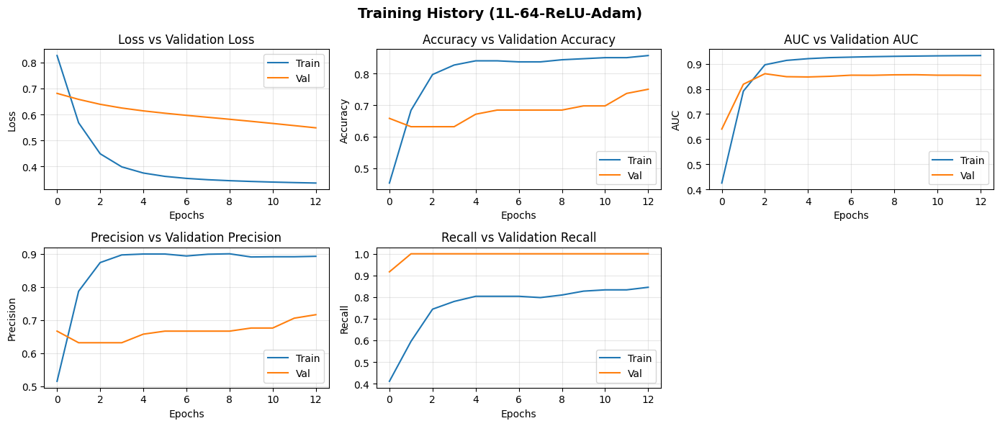


Running 1L-128-ReLU-Adam...


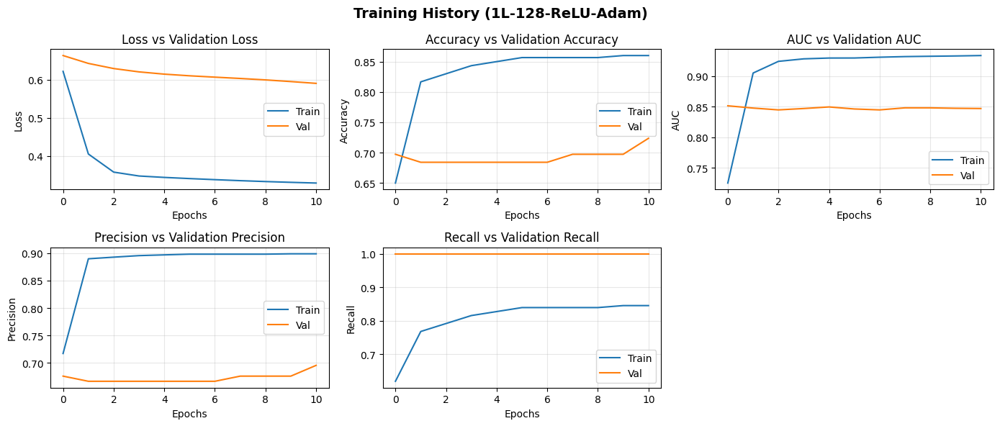


Running 1L-256-ReLU-Adam...


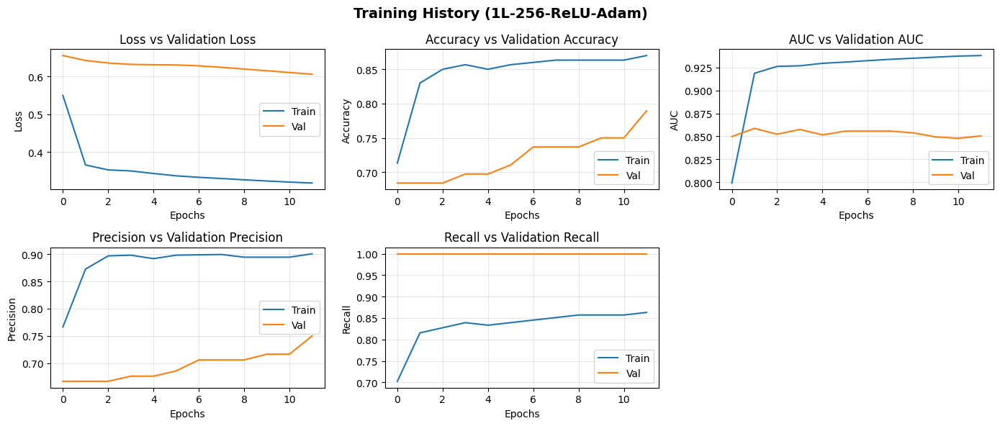


Running 2L-64-32-ReLU-Adam...


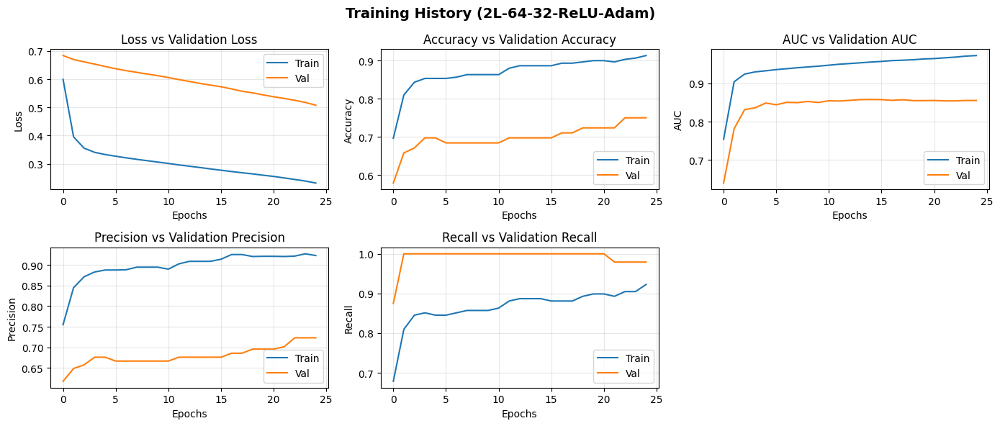


Running 2L-128-64-ReLU-Adam...


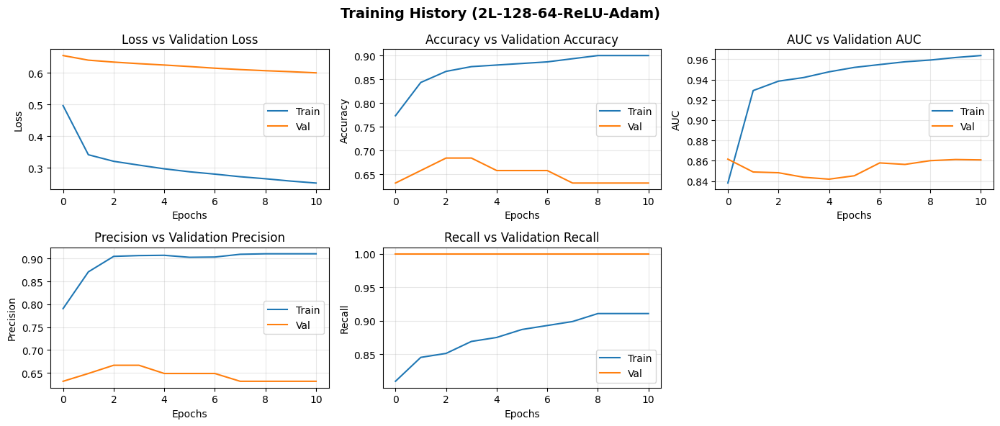


Running 2L-256-128-ReLU-Adam...


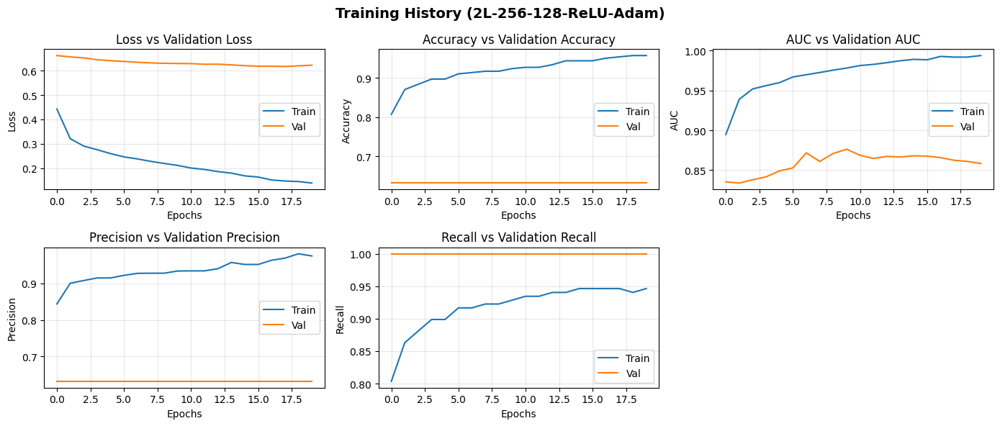


Running 3L-128-64-32-ReLU-Adam...


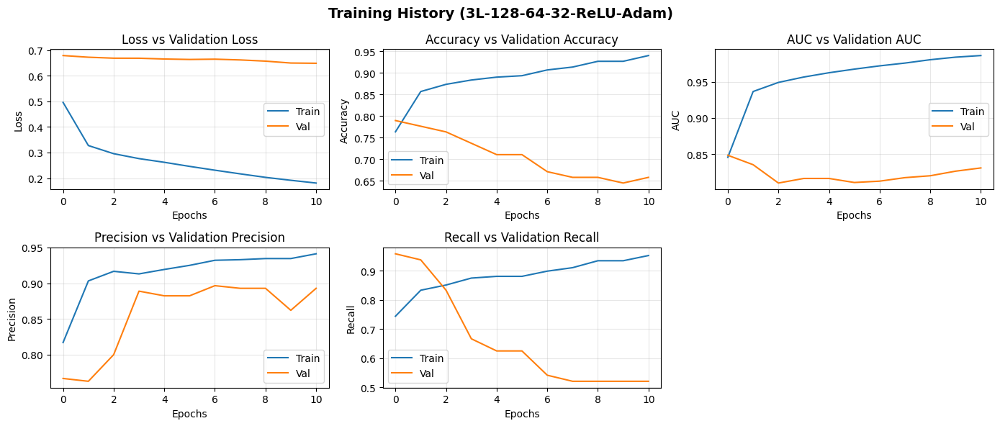


Running 3L-256-128-64-ReLU-Adam...


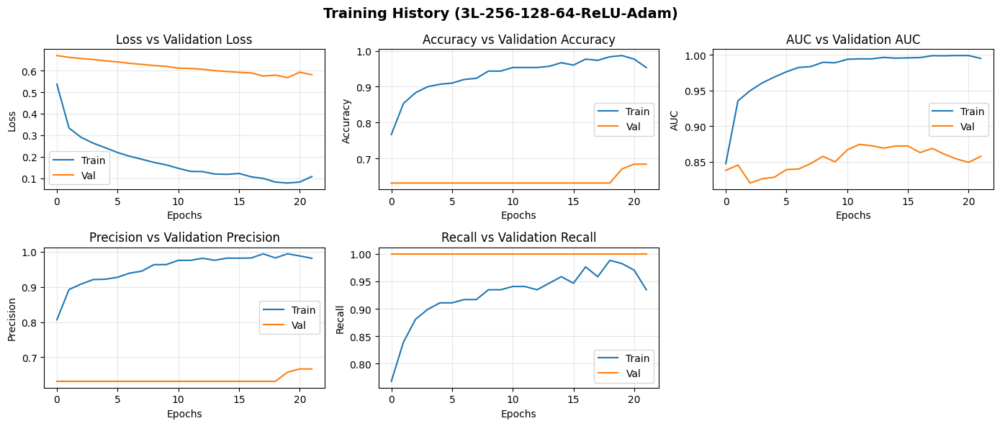


Running 2L-128-64-Tanh-Adam...


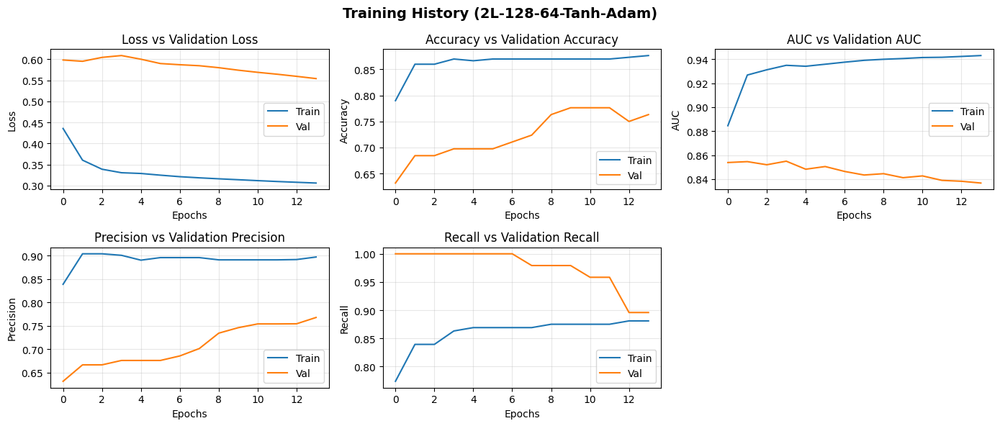


Running 2L-128-64-ELU-Adam...


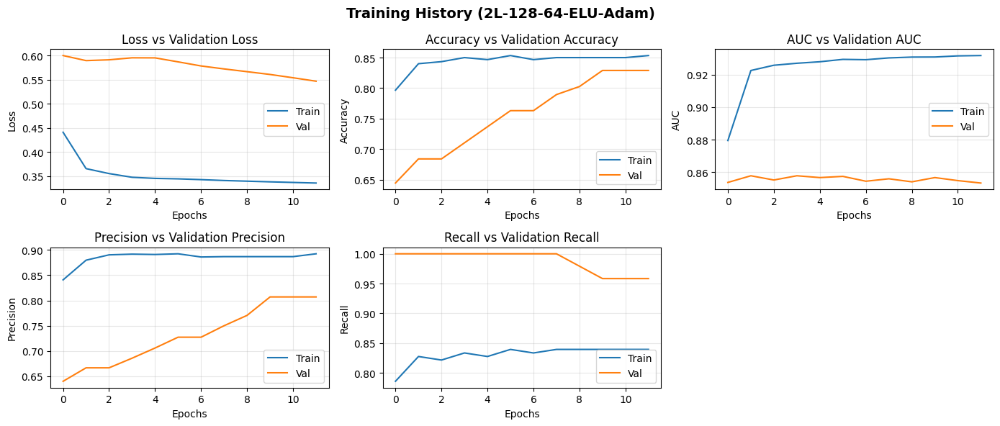


Running 2L-128-64-Sigmoid-Adam...


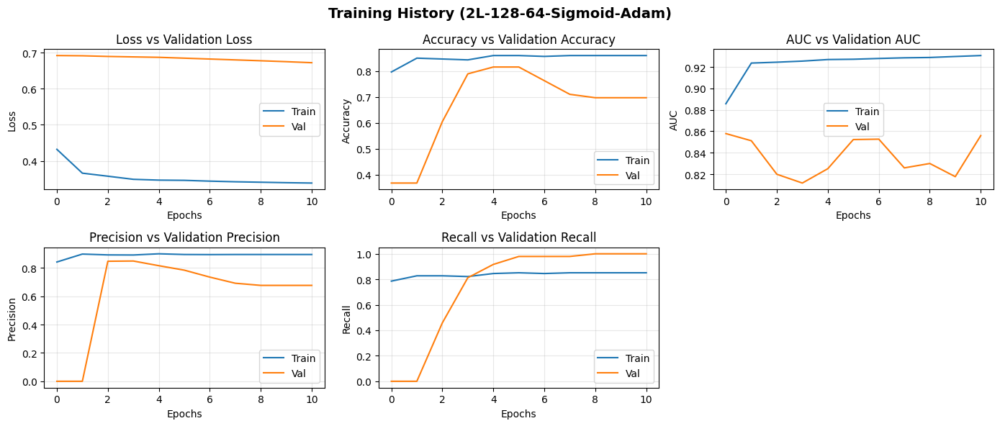


Running 2L-128-64-ReLU-Drop0.1...


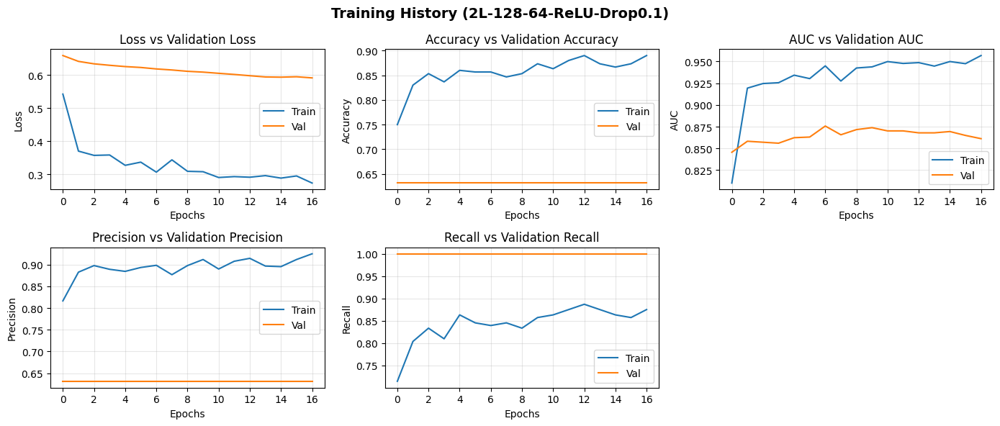


Running 2L-128-64-ReLU-Drop0.5...


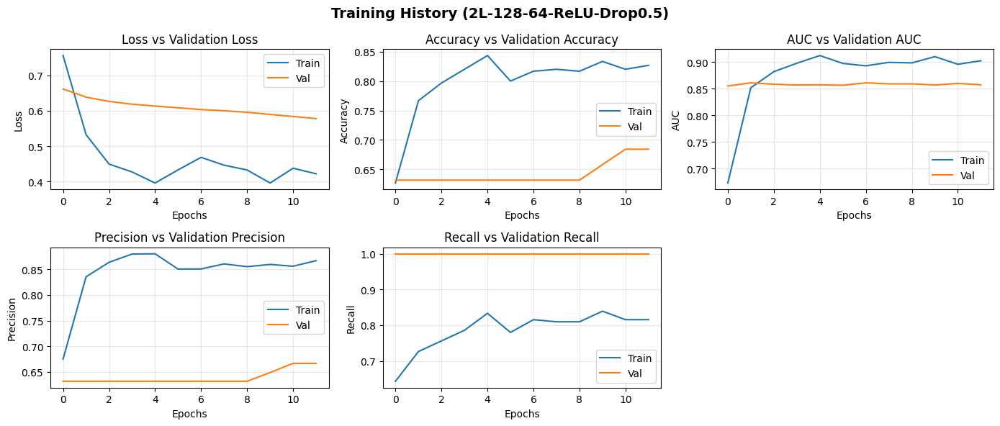


Running 2L-128-64-ReLU-SGD...


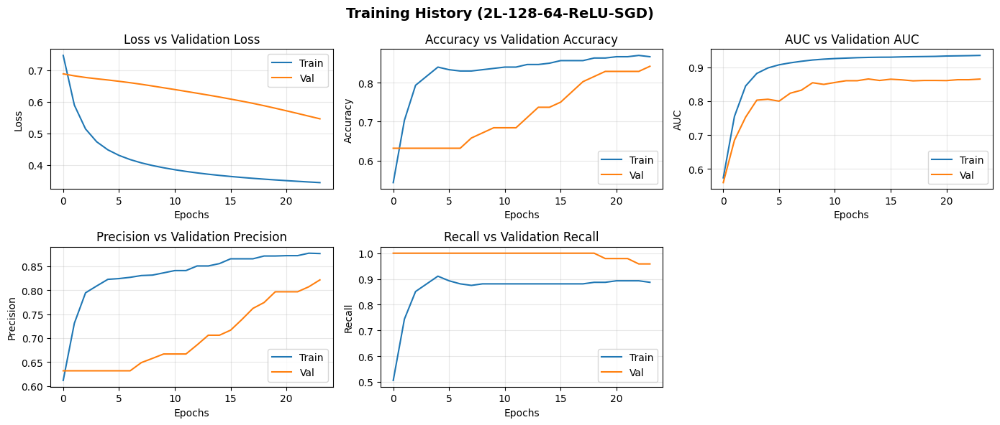


Running 2L-128-64-ReLU-RMSprop...


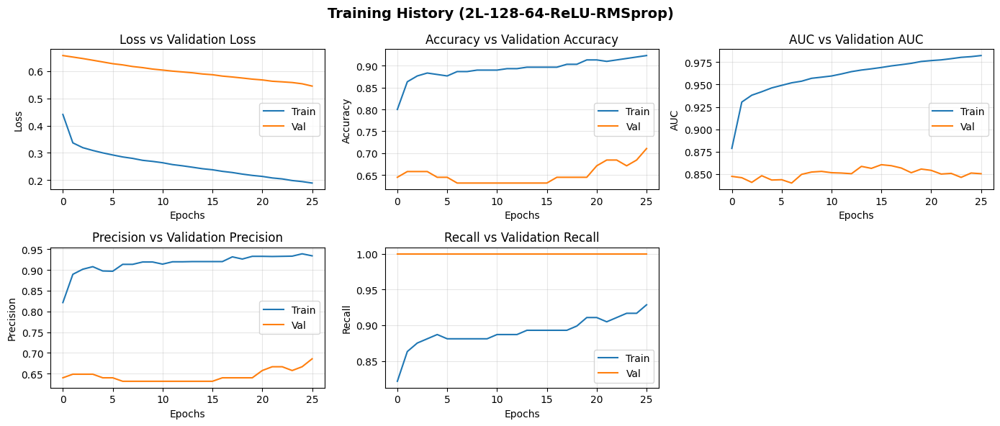


Running 2L-128-64-ReLU-Adamax...


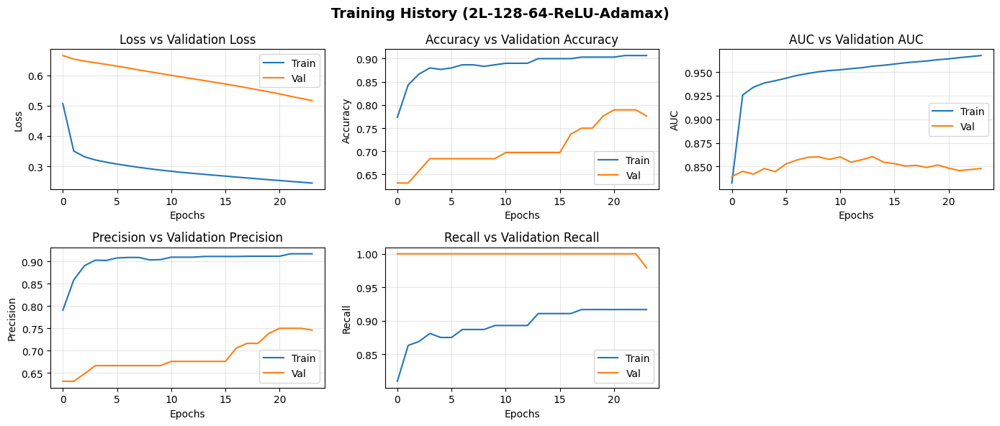


Running 2L-128-64-ReLU-Adam-LR0.01...


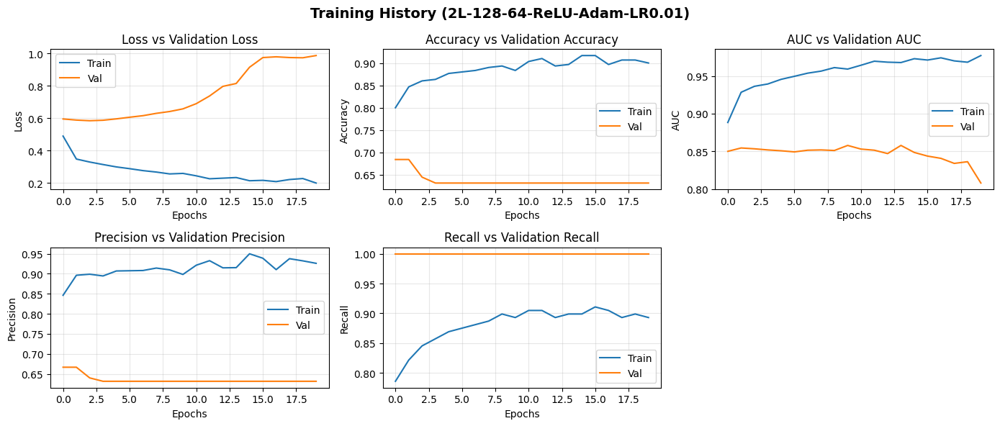


Running 2L-128-64-ReLU-Adam-LR0.0001...


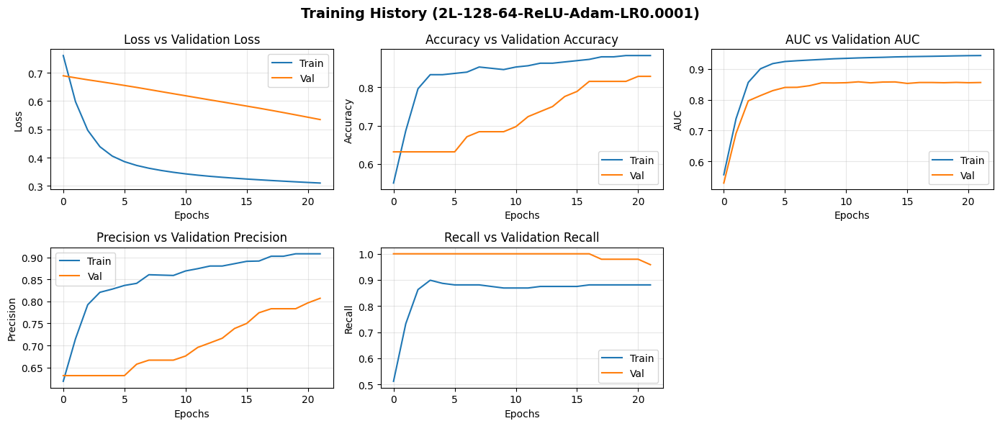


Running 2L-128-64-ReLU-Adam-Batch16...


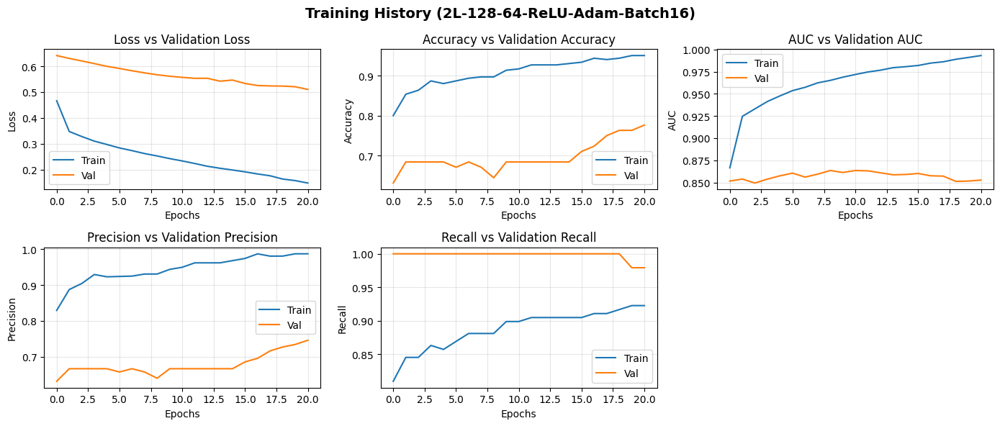


Running 2L-128-64-ReLU-Adam-Batch64...


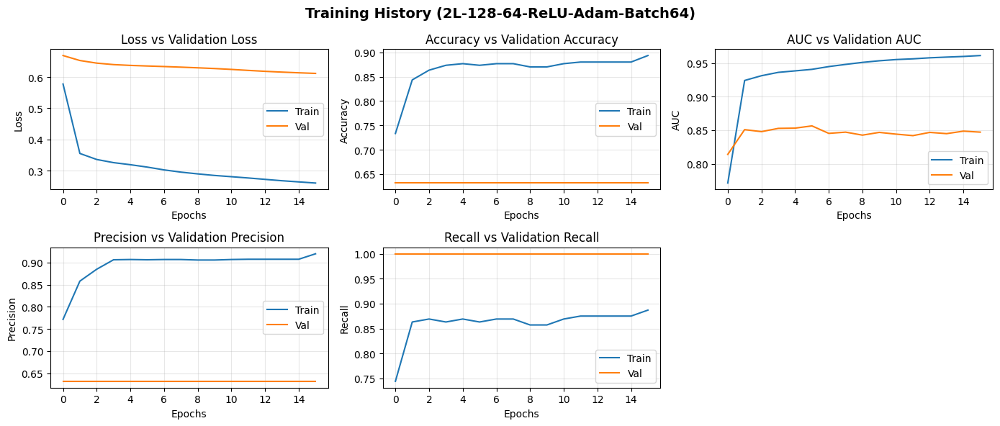

18 experiment(s) excluded due to 100% recall

Experiments Results
#   Experiment                                               Train Acc   Test Acc   Test AUC  Precision     Recall      Gap  Epochs     Time
-------------------------------------------------------------------------------------------------------------------------------------------------
1   1L-64-ReLU-Adam                                              79.67%      59.57%      92.94%      58.70%     100.00%    20.09%      13     1.4s  
2   1L-128-ReLU-Adam                                             65.00%      65.96%      93.13%      62.79%     100.00%     0.96%      11     1.4s  
3   1L-256-ReLU-Adam                                             83.00%      63.83%      94.19%      61.36%     100.00%    19.17%      12     1.4s  
4   2L-64-32-ReLU-Adam                                           88.67%      68.09%      93.03%      64.29%     100.00%    20.58%      25     2.1s  
5   2L-128-64-ReLU-Adam                            

In [39]:
a2_model, a2_best_architecture_results, a2_best_architecture_exp_parameters = run_experiments(experiments, X_train_drop_sc, y_train_drop, X_test_drop_sc, y_test_drop, cw_drop, plot_history=True)

## Approach #3: Drop high missing columns + simple median/mode for remaining columns

In [40]:
cols_to_drop = ['High School Average Mark', 'Math Score', 'hs_avg_missing', 'math_score_missing']
continuous_cols = ['First Term Gpa', 'Second Term Gpa']
categorical_cols = ['First Language', 'Previous Education', 
                    'Age Group', 'English Grade']

df_col_dropped = df_original.drop(columns=cols_to_drop).copy()

print(f"Original shape:      {df_original.shape}")
print(f"After drop shape:    {df_col_dropped.shape}")
print(f"Columns removed:     {cols_to_drop}")

print(f"\nRemaining missing values:")
print(df_col_dropped.isnull().sum())
print(f"\nTotal missing: {df_col_dropped.isnull().sum().sum()}")

print(f"\nTarget distribution:")
print(df_col_dropped['FirstYearPersistence'].value_counts())
print(df_col_dropped['FirstYearPersistence'].value_counts(normalize=True))

Original shape:      (1437, 16)
After drop shape:    (1437, 12)
Columns removed:     ['High School Average Mark', 'Math Score', 'hs_avg_missing', 'math_score_missing']

Remaining missing values:
First Term Gpa           17
Second Term Gpa         160
First Language          111
Funding                   0
FastTrack                 0
Coop                      0
Residency                 0
Gender                    0
Previous Education       92
Age Group                 4
English Grade            45
FirstYearPersistence      0
dtype: int64

Total missing: 429

Target distribution:
FirstYearPersistence
1    1138
0     299
Name: count, dtype: int64
FirstYearPersistence
1    0.791928
0    0.208072
Name: proportion, dtype: float64


In [41]:
median_imp = SimpleImputer(strategy='median')
df_col_dropped[continuous_cols] = median_imp.fit_transform(df_col_dropped[continuous_cols])

mode_imp = SimpleImputer(strategy='most_frequent')
df_col_dropped[categorical_cols] = mode_imp.fit_transform(df_col_dropped[categorical_cols])

print(f"Missing after imputation: {df_col_dropped.isnull().sum().sum()}")
print(f"\nFinal shape: {df_col_dropped.shape}")
print(f"\nColumns used:\n{df_col_dropped.columns.tolist()}")

Missing after imputation: 0

Final shape: (1437, 12)

Columns used:
['First Term Gpa', 'Second Term Gpa', 'First Language', 'Funding', 'FastTrack', 'Coop', 'Residency', 'Gender', 'Previous Education', 'Age Group', 'English Grade', 'FirstYearPersistence']


Average GPA distribution:
count    1437.000000
mean        2.846199
std         1.002668
min         0.000000
25%         2.220000
50%         3.000000
75%         3.627500
max         4.500000
Name: Average Gpa, dtype: float64

Threshold GPA >= 1.5:
  GPA only:          1313 students (91.4%)
  GPA + Persistence: 1078 students (75.0%)

Threshold GPA >= 2.0:
  GPA only:          1141 students (79.4%)
  GPA + Persistence: 1009 students (70.2%)

Threshold GPA >= 2.5:
  GPA only:          974 students (67.8%)
  GPA + Persistence: 875 students (60.9%)

Threshold GPA >= 3.0:
  GPA only:          719 students (50.0%)
  GPA + Persistence: 661 students (46.0%)
Student Success Distribution:
Student_Success
1    875
0    562
Name: count, dtype: int64
Student_Success
1    0.608907
0    0.391093
Name: proportion, dtype: float64

Breakdown:
Persisted AND GPA >= 2.5: 875
Did not persist:                  299
Persisted but low GPA:            263
Did not persist but high GPA:     99
interval columns n

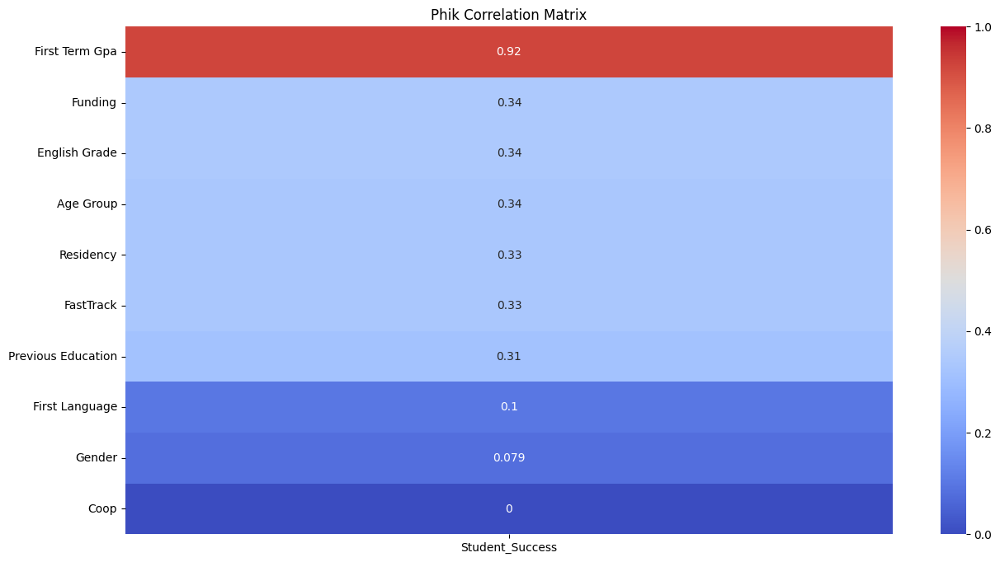

Threshold: 0.25
Selected features: 7
Excluded features: 3

Selected: ['First Term Gpa', 'Funding', 'English Grade', 'Age Group', 'Residency', 'FastTrack', 'Previous Education']


In [42]:
df_col_dropped['Average Gpa'] = (df_col_dropped['First Term Gpa'] + df_col_dropped['Second Term Gpa']) / 2

print("Average GPA distribution:")
print(df_col_dropped['Average Gpa'].describe())

for threshold in [1.5, 2.0, 2.5, 3.0]:
    gpa_pass = (df_col_dropped['Average Gpa'] >= threshold).sum()
    combined = ((df_col_dropped['Average Gpa'] >= threshold) & 
                (df_col_dropped['FirstYearPersistence'] == 1)).sum()
    print(f"\nThreshold GPA >= {threshold}:")
    print(f"  GPA only:          {gpa_pass} students ({gpa_pass/len(df_col_dropped)*100:.1f}%)")
    print(f"  GPA + Persistence: {combined} students ({combined/len(df_col_dropped)*100:.1f}%)")

threshold = 2.5

df_col_dropped['Student_Success'] = ((df_col_dropped['Average Gpa'] >= threshold) & (df_col_dropped['FirstYearPersistence'] == 1)).astype(int)

# Verify distribution
print("Student Success Distribution:")
print(df_col_dropped['Student_Success'].value_counts())
print(df_col_dropped['Student_Success'].value_counts(normalize=True))

# Cross check with components
print(f"\nBreakdown:")
print(f"Persisted AND GPA >= {threshold}: {(df_col_dropped['Student_Success']==1).sum()}")
print(f"Did not persist:                  {(df_col_dropped['FirstYearPersistence']==0).sum()}")
print(f"Persisted but low GPA:            {((df_col_dropped['FirstYearPersistence']==1) & (df_col_dropped['Average Gpa'] < threshold)).sum()}")
print(f"Did not persist but high GPA:     {((df_col_dropped['FirstYearPersistence']==0) & (df_col_dropped['Average Gpa'] >= threshold)).sum()}")

always_exclude = [
    'Student_Success',      # target
    'FirstYearPersistence', # used to create target
    'Average Gpa',          # used to create target
    'Second Term Gpa',      # used to create Average GPA
    'hs_avg_missing',       # flag columns
    'math_score_missing'
]

features_success, scores_success = select_features_phik(
    df=df_col_dropped,
    target_col='Student_Success',
    threshold=0.25,
    exclude_cols=always_exclude,
    verbose=True
)


Class weights: {np.int64(0): np.float64(1.2784697508896796), np.int64(1): np.float64(0.8211428571428572)}

Running 1L-64-ReLU-Adam...


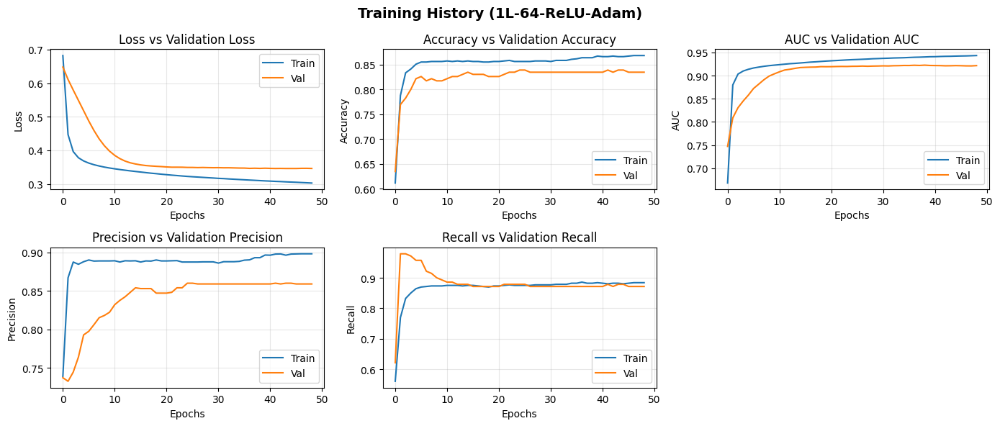


Running 1L-128-ReLU-Adam...


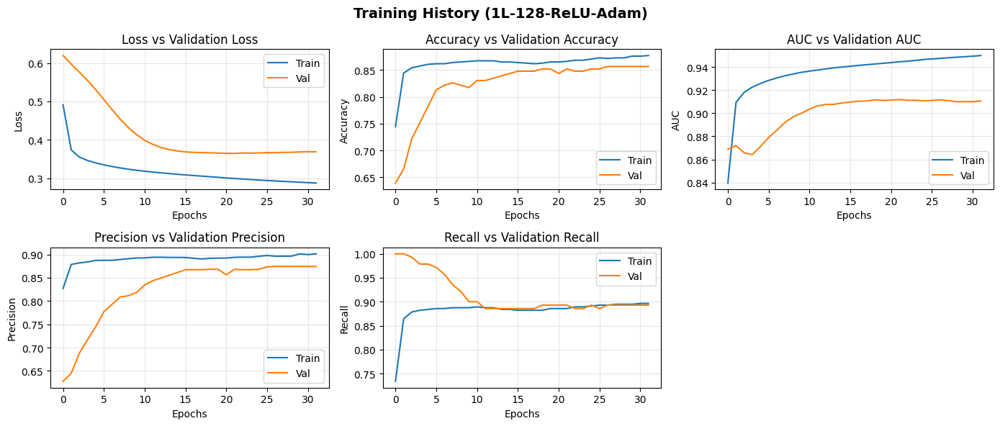


Running 1L-256-ReLU-Adam...


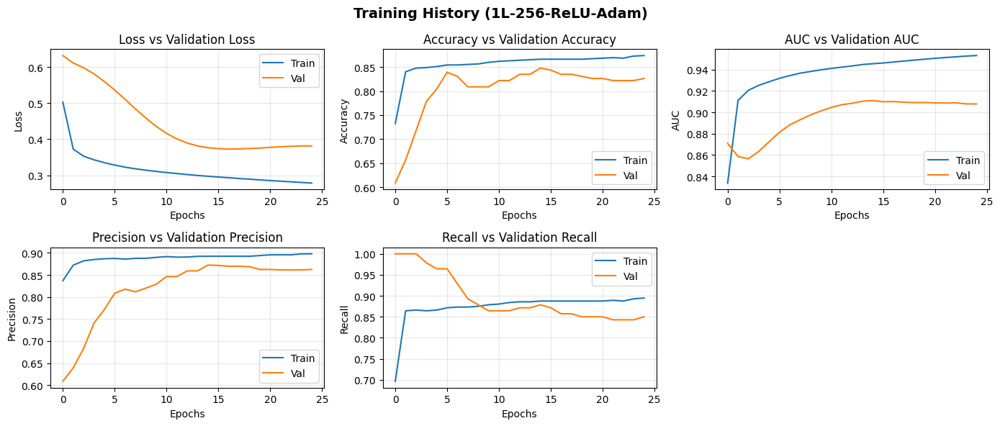


Running 2L-64-32-ReLU-Adam...


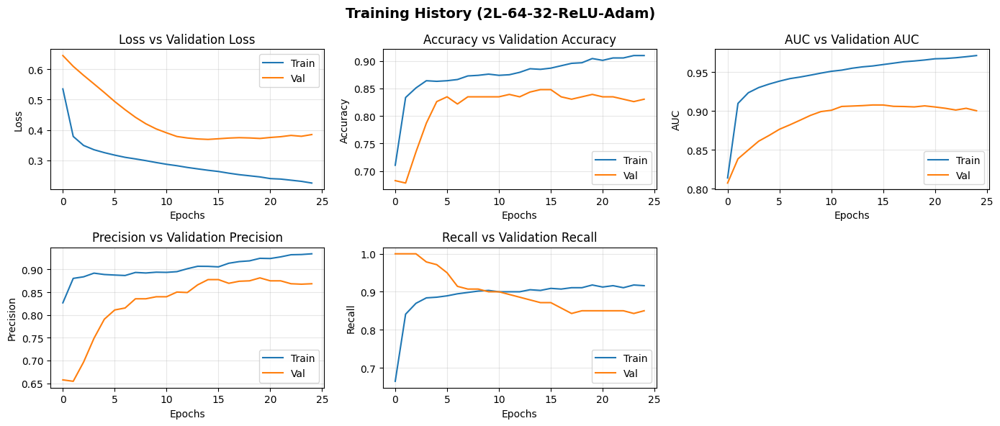


Running 2L-128-64-ReLU-Adam...


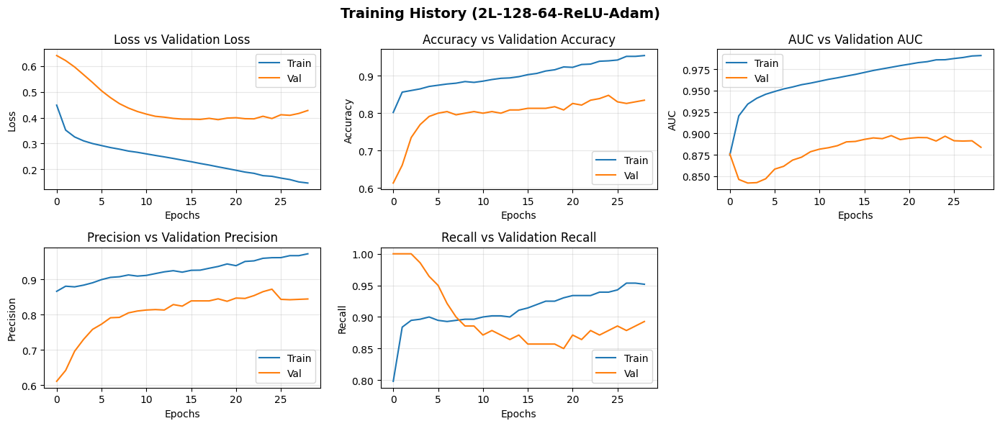


Running 2L-256-128-ReLU-Adam...


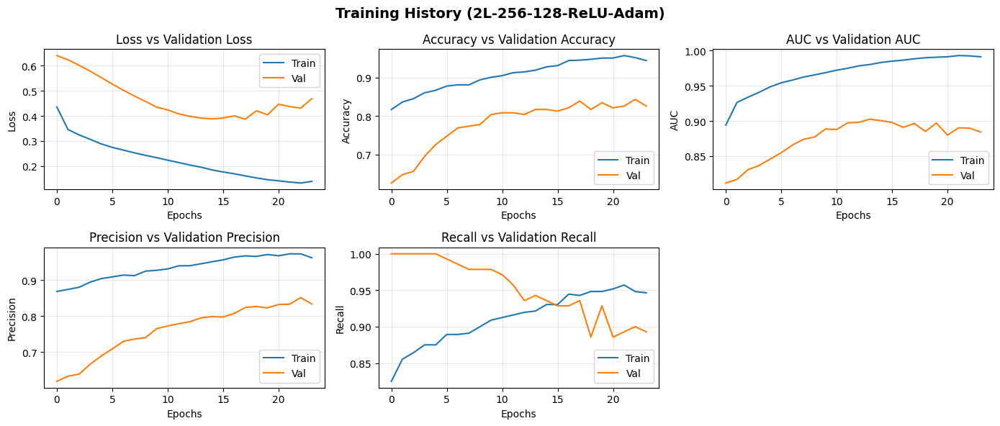


Running 3L-128-64-32-ReLU-Adam...


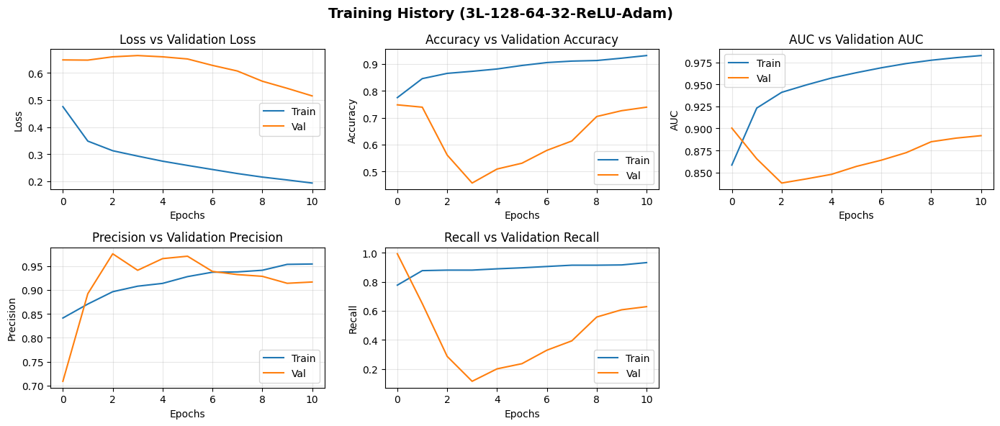


Running 3L-256-128-64-ReLU-Adam...


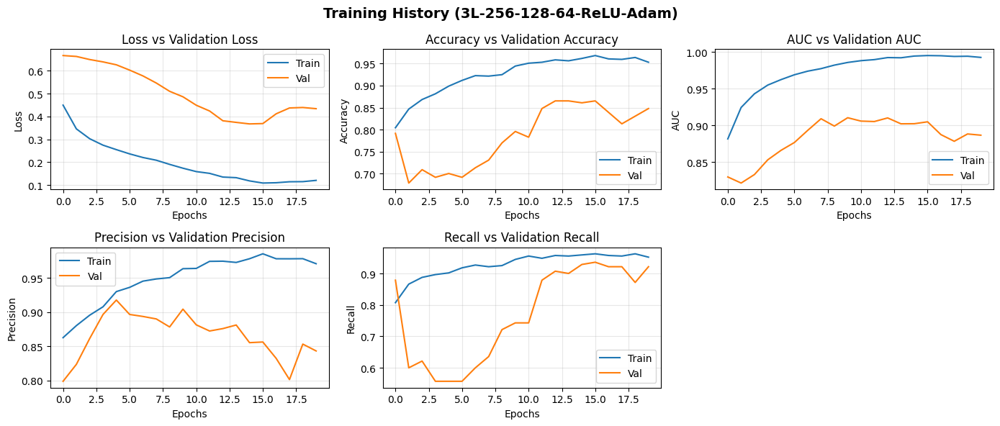


Running 2L-128-64-Tanh-Adam...


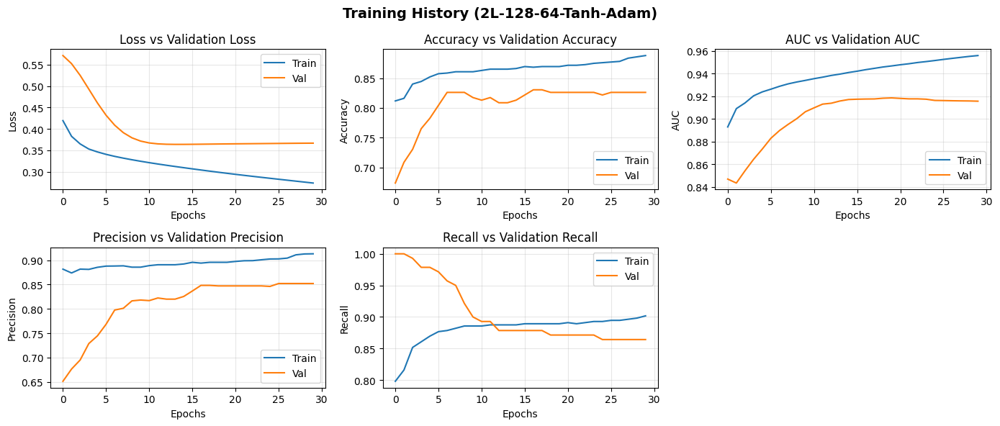


Running 2L-128-64-ELU-Adam...


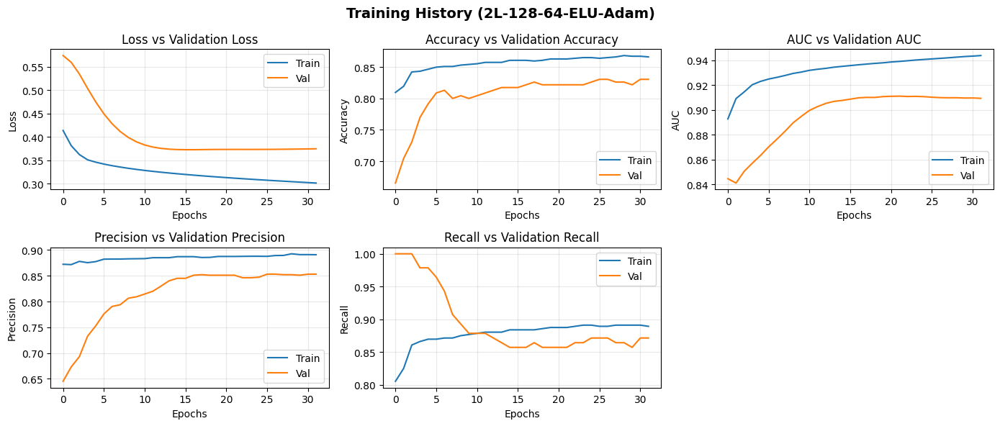


Running 2L-128-64-Sigmoid-Adam...


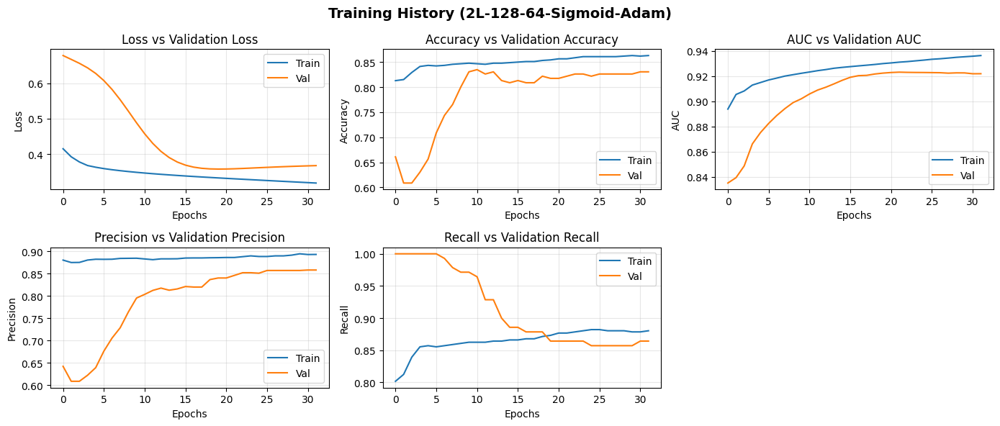


Running 2L-128-64-ReLU-Drop0.1...


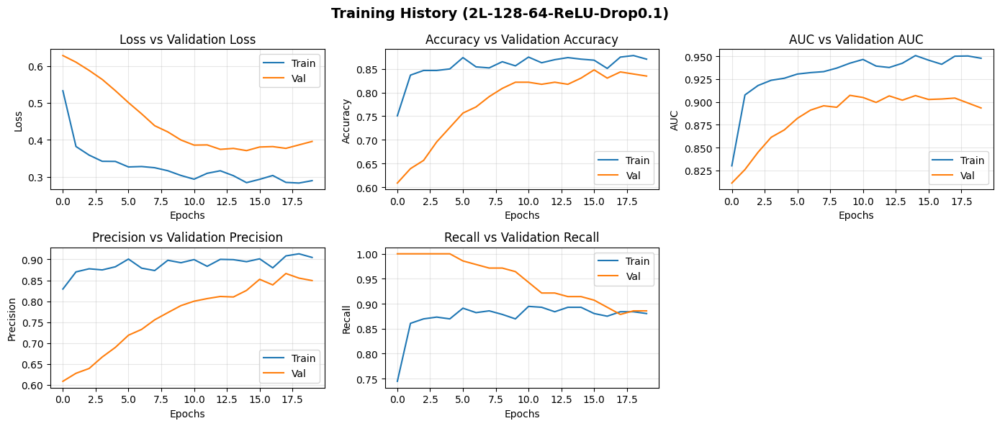


Running 2L-128-64-ReLU-Drop0.5...


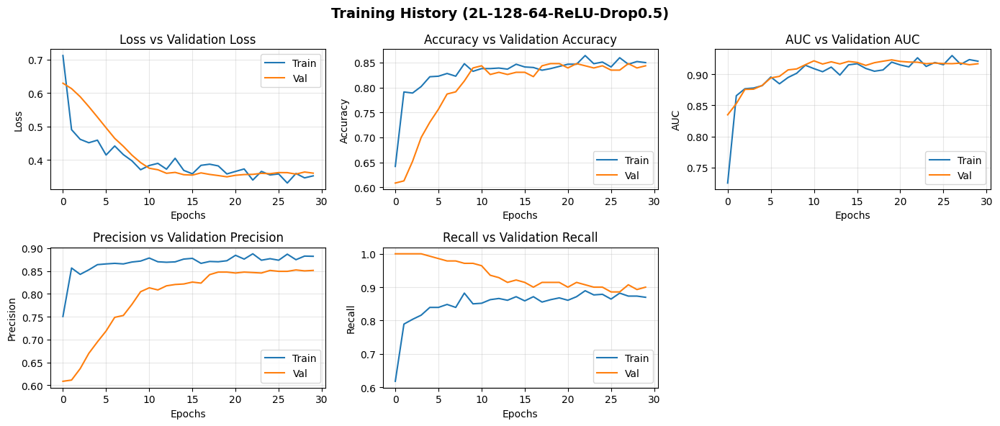


Running 2L-128-64-ReLU-SGD...


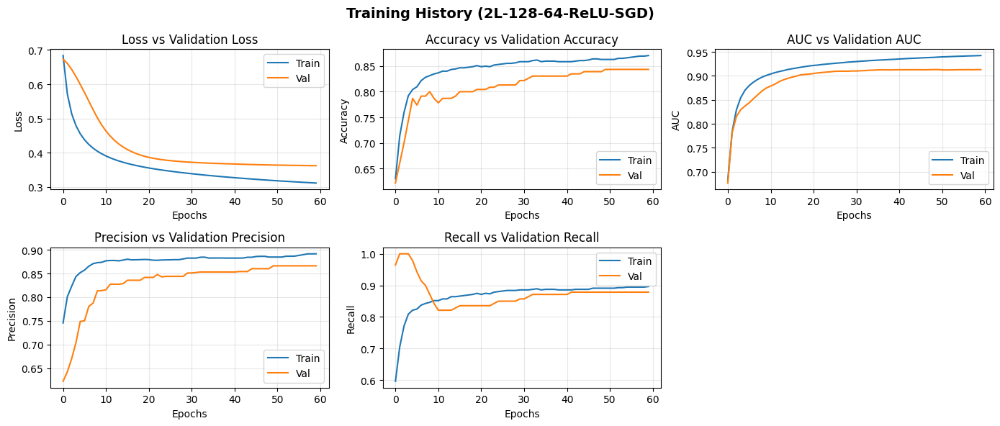


Running 2L-128-64-ReLU-RMSprop...


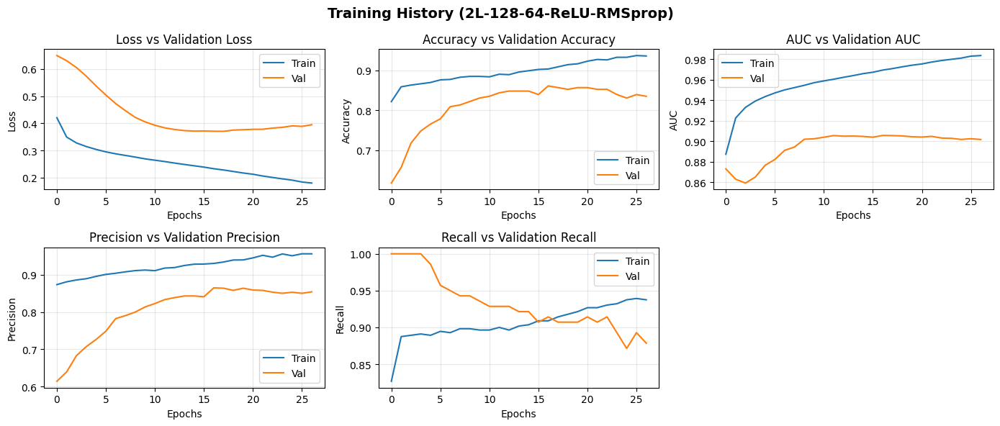


Running 2L-128-64-ReLU-Adamax...


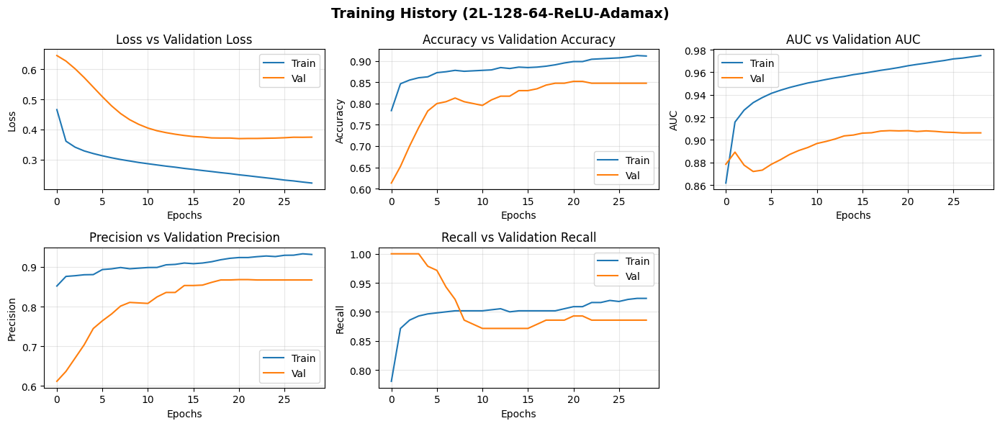


Running 2L-128-64-ReLU-Adam-LR0.01...


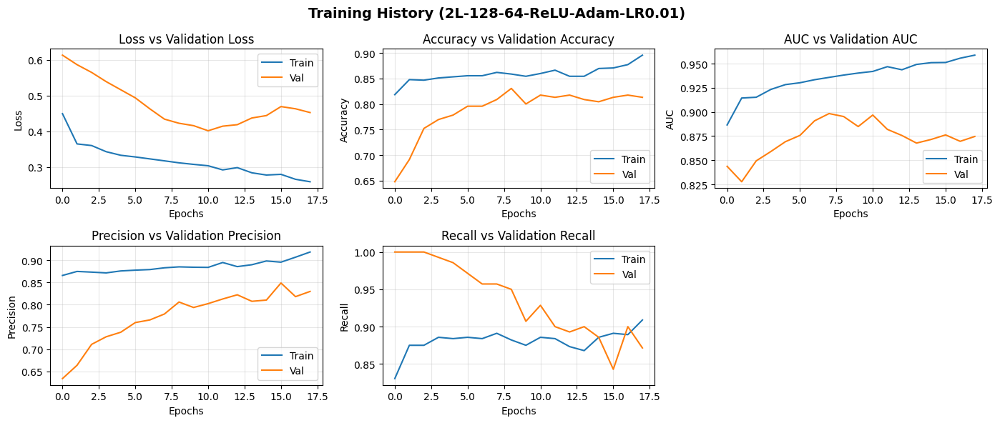


Running 2L-128-64-ReLU-Adam-LR0.0001...


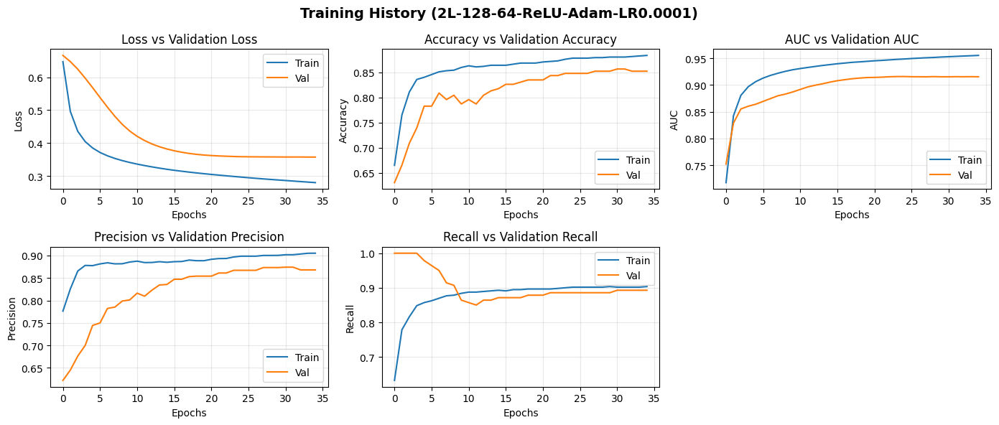


Running 2L-128-64-ReLU-Adam-Batch16...


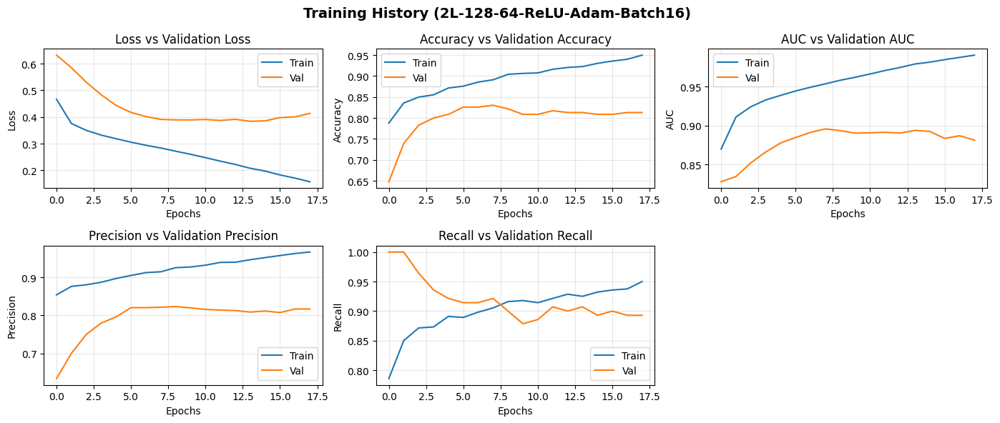


Running 2L-128-64-ReLU-Adam-Batch64...


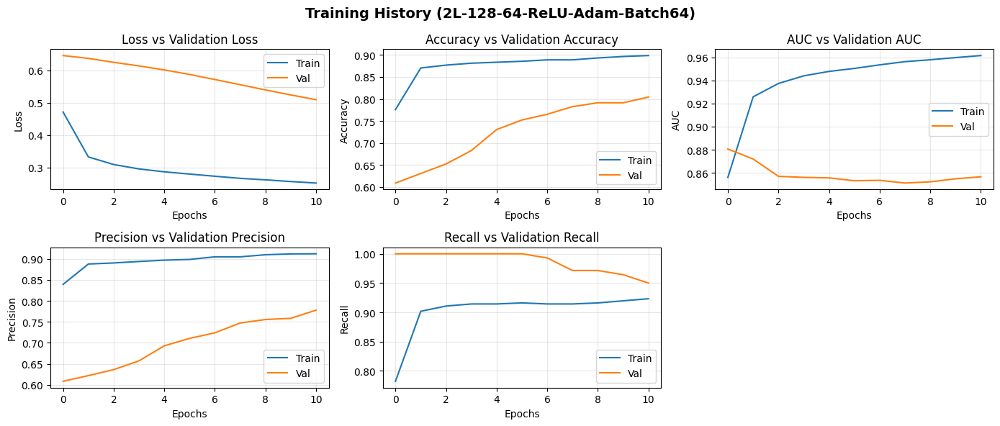

1 experiment(s) excluded due to 100% recall

Experiments Results
#   Experiment                                               Train Acc   Test Acc   Test AUC  Precision     Recall      Gap  Epochs     Time
-------------------------------------------------------------------------------------------------------------------------------------------------
1   1L-64-ReLU-Adam                                              86.40%      86.11%      93.94%      87.29%      90.29%     0.29%      49     3.4s  
2   1L-128-ReLU-Adam                                             86.62%      85.42%      93.29%      85.56%      91.43%     1.20%      32     2.5s  
3   1L-256-ReLU-Adam                                             86.62%      84.72%      92.80%      86.19%      89.14%     1.89%      25     2.1s  
4   2L-64-32-ReLU-Adam                                           88.47%      86.11%      93.43%      86.89%      90.86%     2.35%      25     2.4s  
5   2L-128-64-ReLU-Adam                             

In [43]:
X_drop_high_mis_col = df_col_dropped[features_success]
y_drop_high_mis_col = df_col_dropped[target_column]

classes_drop_high_mis_col  = np.unique(y_drop_high_mis_col)
weights_drop_high_mis_col  = compute_class_weight(class_weight='balanced', 
                                    classes=classes_drop_high_mis_col, 
                                    y=y_drop_high_mis_col)
cw_drop_high_mis_col = dict(zip(classes_drop_high_mis_col, weights_drop_high_mis_col))
print(f"\nClass weights: {cw_drop_high_mis_col}")

X_train_drop_high_mis_col, X_test_drop_high_mis_col, y_train_drop_high_mis_col, y_test_drop_high_mis_col = train_test_split(
    X_drop_high_mis_col, y_drop_high_mis_col,
    test_size=0.2,
    random_state=42,
    stratify=y_drop_high_mis_col
)

scaler_drop_high_mis_col = MinMaxScaler()
X_train_drop_high_mis_col_sc = scaler_drop_high_mis_col.fit_transform(X_train_drop_high_mis_col)
X_test_drop_high_mis_col_sc = scaler_drop_high_mis_col.transform(X_test_drop_high_mis_col)

a3_model, a3_best_architecture_results, a3_best_architecture_exp_parameters = run_experiments(experiments, X_train_drop_high_mis_col_sc, y_train_drop_high_mis_col, X_test_drop_high_mis_col_sc, y_test_drop_high_mis_col, cw_drop_high_mis_col, plot_history=True)

## Approach #4: Simple Imputation for ALL columns

In [44]:
df_simple_imputation = df_original.copy()
df_simple_imputation = df_simple_imputation.drop(
    columns=['hs_avg_missing', 'math_score_missing'], 
    errors='ignore'
)

continuous_cols  = ['First Term Gpa', 'Second Term Gpa', 'High School Average Mark', 'Math Score']
categorical_cols = ['First Language', 'Previous Education', 'Age Group', 'English Grade']

median_imp = SimpleImputer(strategy='median')
df_simple_imputation[continuous_cols] = median_imp.fit_transform(
    df_simple_imputation[continuous_cols])

mode_imp = SimpleImputer(strategy='most_frequent')
df_simple_imputation[categorical_cols] = mode_imp.fit_transform(
    df_simple_imputation[categorical_cols])

print(f"Shape: {df_simple_imputation.shape}")
print(f"Total missing: {df_simple_imputation.isnull().sum().sum()}")
print(f"\nMissing per column:")
print(df_simple_imputation.isnull().sum())

Shape: (1437, 14)
Total missing: 0

Missing per column:
First Term Gpa              0
Second Term Gpa             0
First Language              0
Funding                     0
FastTrack                   0
Coop                        0
Residency                   0
Gender                      0
Previous Education          0
Age Group                   0
High School Average Mark    0
Math Score                  0
English Grade               0
FirstYearPersistence        0
dtype: int64


Average GPA distribution:
count    1437.000000
mean        2.846199
std         1.002668
min         0.000000
25%         2.220000
50%         3.000000
75%         3.627500
max         4.500000
Name: Average Gpa, dtype: float64

Threshold GPA >= 1.5:
  GPA only:          1313 students (91.4%)
  GPA + Persistence: 1078 students (75.0%)

Threshold GPA >= 2.0:
  GPA only:          1141 students (79.4%)
  GPA + Persistence: 1009 students (70.2%)

Threshold GPA >= 2.5:
  GPA only:          974 students (67.8%)
  GPA + Persistence: 875 students (60.9%)

Threshold GPA >= 3.0:
  GPA only:          719 students (50.0%)
  GPA + Persistence: 661 students (46.0%)
Student Success Distribution:
Student_Success
1    875
0    562
Name: count, dtype: int64
Student_Success
1    0.608907
0    0.391093
Name: proportion, dtype: float64

Breakdown:
Persisted AND GPA >= 2.5: 875
Did not persist:                  299
Persisted but low GPA:            263
Did not persist but high GPA:     99
interval columns n

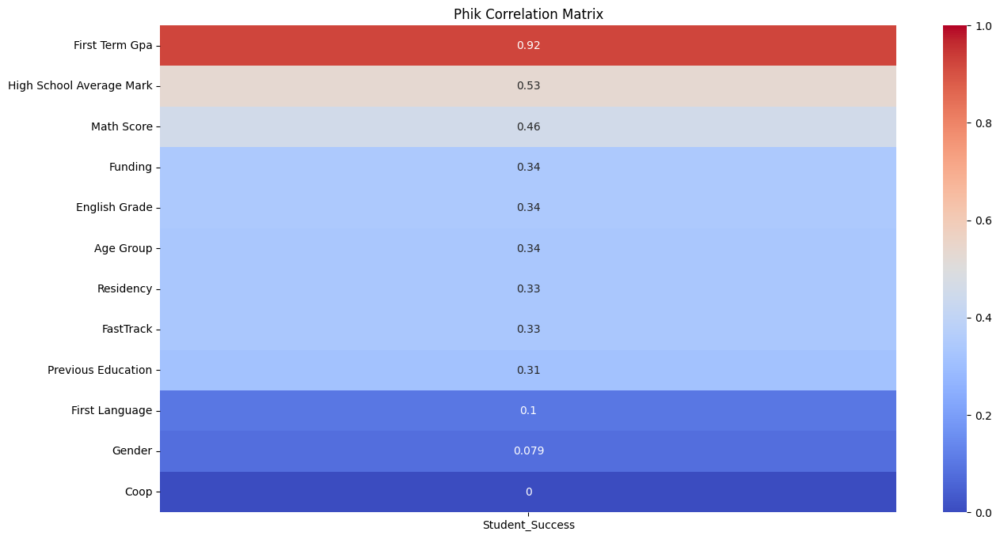

Threshold: 0.25
Selected features: 9
Excluded features: 3

Selected: ['First Term Gpa', 'High School Average Mark', 'Math Score', 'Funding', 'English Grade', 'Age Group', 'Residency', 'FastTrack', 'Previous Education']


In [45]:
df_simple_imputation['Average Gpa'] = (df_simple_imputation['First Term Gpa'] + df_simple_imputation['Second Term Gpa']) / 2

print("Average GPA distribution:")
print(df_simple_imputation['Average Gpa'].describe())

for threshold in [1.5, 2.0, 2.5, 3.0]:
    gpa_pass = (df_simple_imputation['Average Gpa'] >= threshold).sum()
    combined = ((df_simple_imputation['Average Gpa'] >= threshold) & 
                (df_simple_imputation['FirstYearPersistence'] == 1)).sum()
    print(f"\nThreshold GPA >= {threshold}:")
    print(f"  GPA only:          {gpa_pass} students ({gpa_pass/len(df_simple_imputation)*100:.1f}%)")
    print(f"  GPA + Persistence: {combined} students ({combined/len(df_simple_imputation)*100:.1f}%)")

threshold = 2.5

df_simple_imputation['Student_Success'] = ((df_simple_imputation['Average Gpa'] >= threshold) & (df_simple_imputation['FirstYearPersistence'] == 1)).astype(int)

# Verify distribution
print("Student Success Distribution:")
print(df_simple_imputation['Student_Success'].value_counts())
print(df_simple_imputation['Student_Success'].value_counts(normalize=True))

# Cross check with components
print(f"\nBreakdown:")
print(f"Persisted AND GPA >= {threshold}: {(df_simple_imputation['Student_Success']==1).sum()}")
print(f"Did not persist:                  {(df_simple_imputation['FirstYearPersistence']==0).sum()}")
print(f"Persisted but low GPA:            {((df_simple_imputation['FirstYearPersistence']==1) & (df_simple_imputation['Average Gpa'] < threshold)).sum()}")
print(f"Did not persist but high GPA:     {((df_simple_imputation['FirstYearPersistence']==0) & (df_simple_imputation['Average Gpa'] >= threshold)).sum()}")

always_exclude = [
    'Student_Success',      # target
    'FirstYearPersistence', # used to create target
    'Average Gpa',          # used to create target
    'Second Term Gpa',      # used to create Average GPA
    'hs_avg_missing',       # flag columns
    'math_score_missing'
]

features_success, scores_success = select_features_phik(
    df=df_simple_imputation,
    target_col='Student_Success',
    threshold=0.25,
    exclude_cols=always_exclude,
    verbose=True
)


Class weights: {np.int64(0): np.float64(1.2784697508896796), np.int64(1): np.float64(0.8211428571428572)}

Running 1L-64-ReLU-Adam...


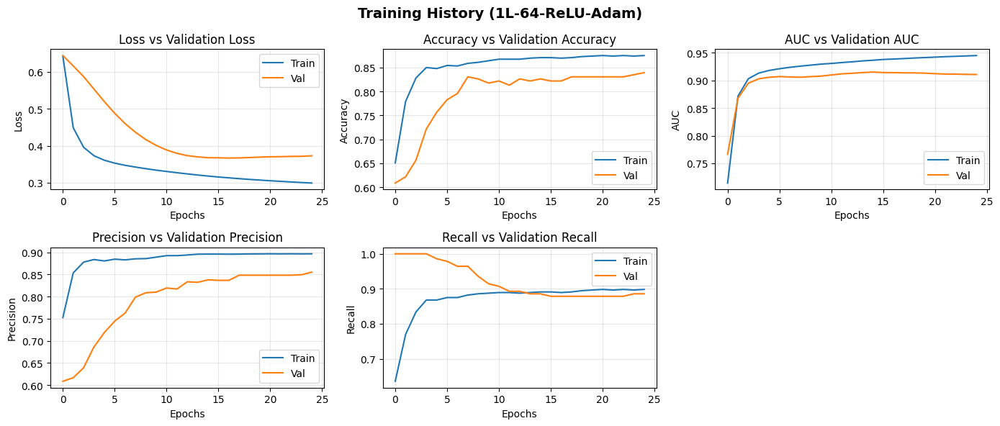


Running 1L-128-ReLU-Adam...


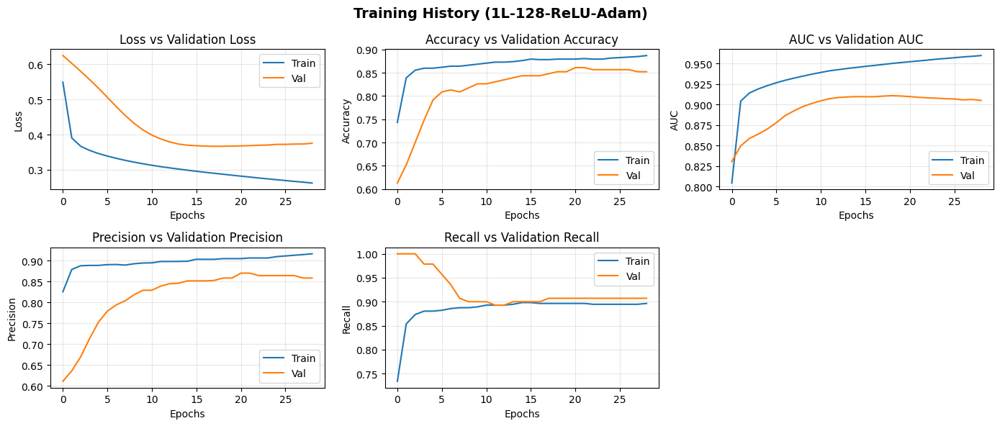


Running 1L-256-ReLU-Adam...


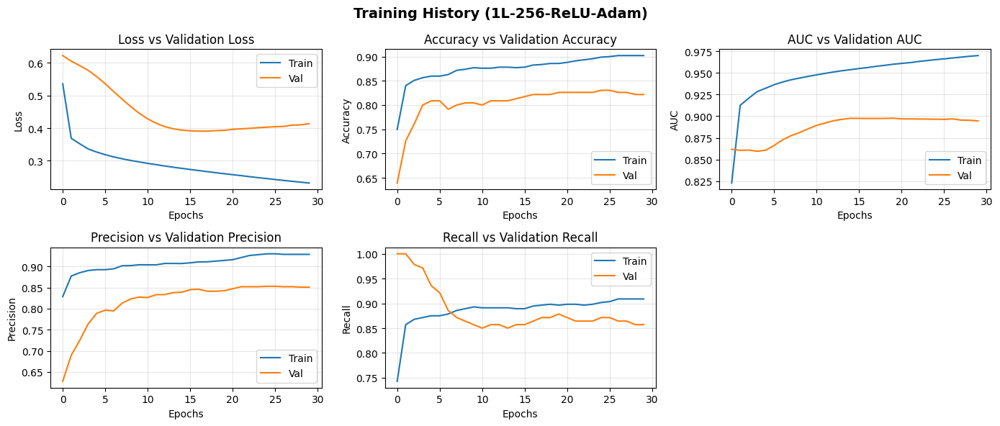


Running 2L-64-32-ReLU-Adam...


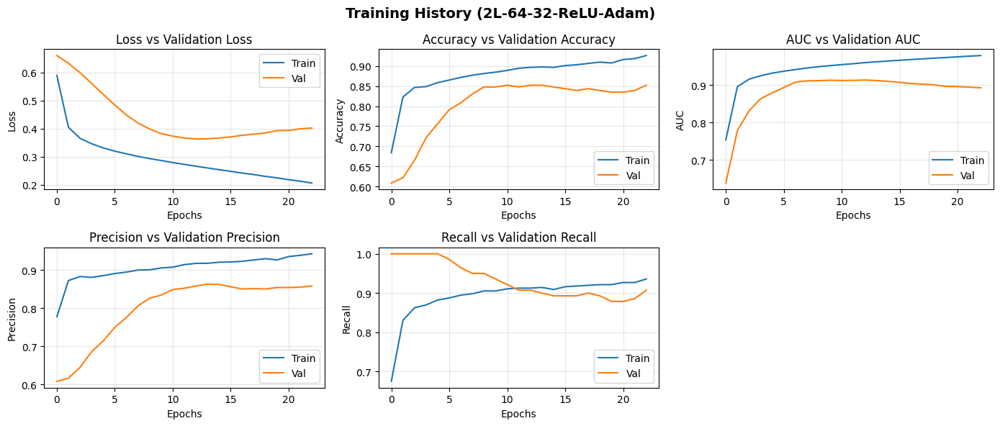


Running 2L-128-64-ReLU-Adam...


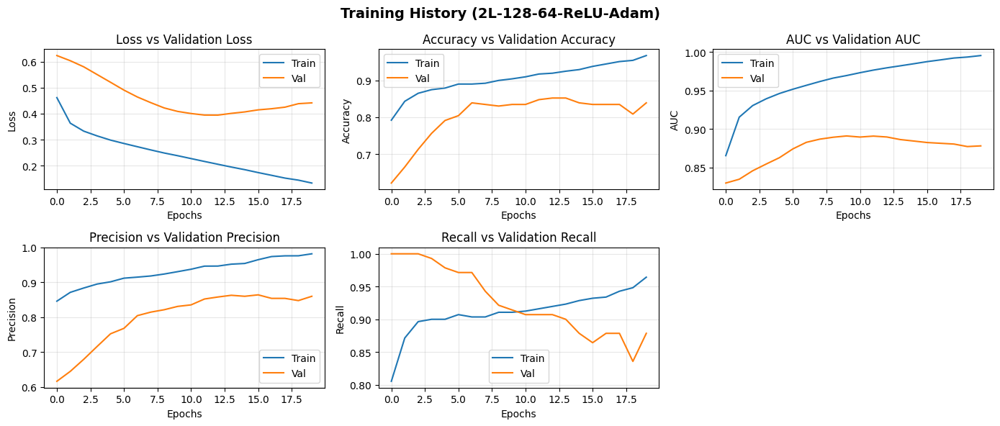


Running 2L-256-128-ReLU-Adam...


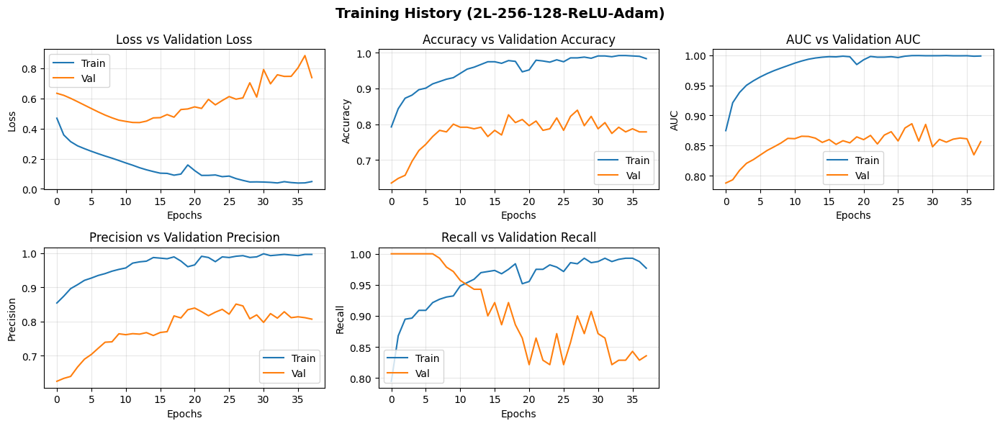


Running 3L-128-64-32-ReLU-Adam...


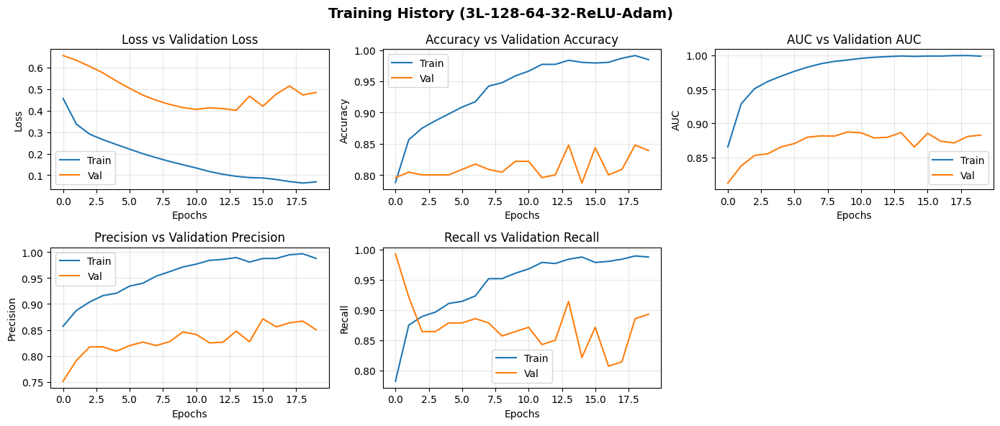


Running 3L-256-128-64-ReLU-Adam...


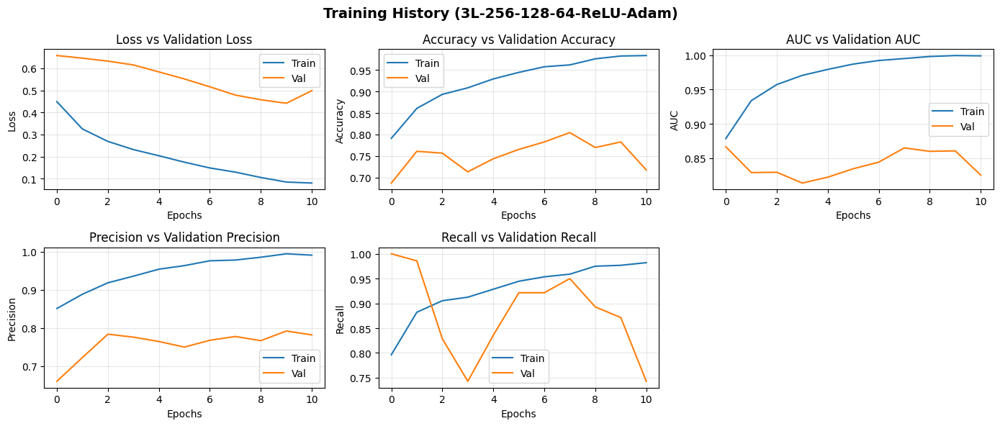


Running 2L-128-64-Tanh-Adam...


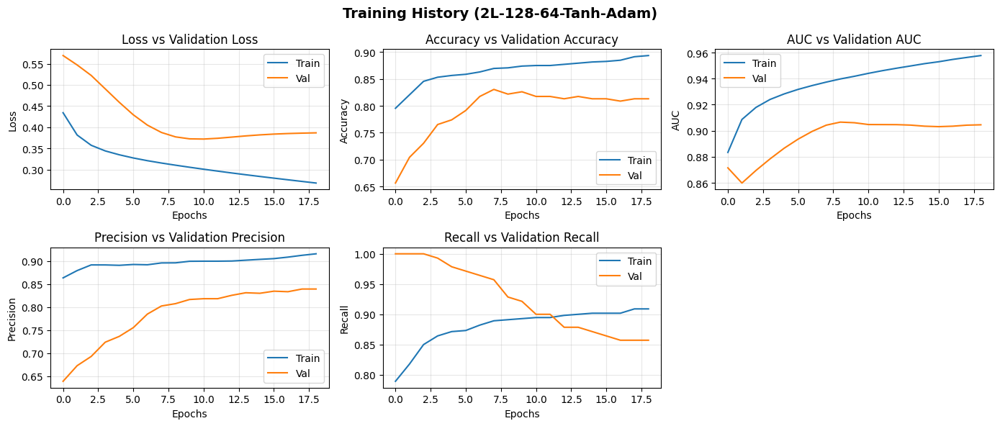


Running 2L-128-64-ELU-Adam...


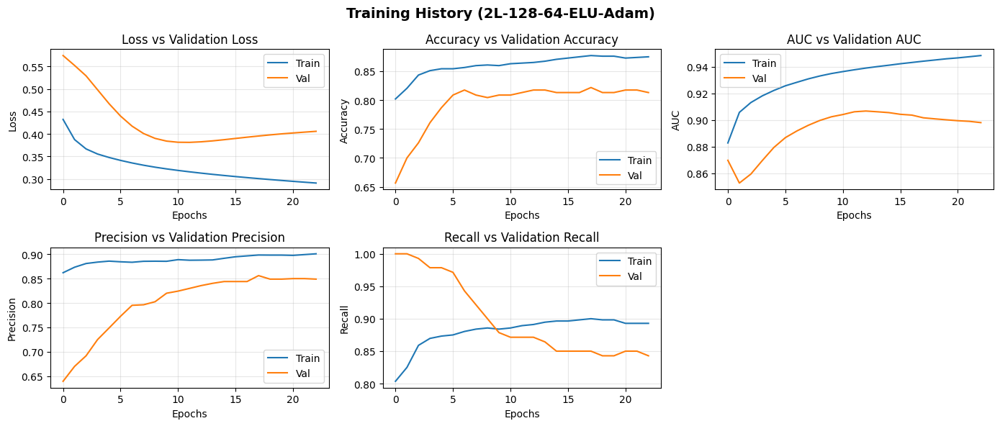


Running 2L-128-64-Sigmoid-Adam...


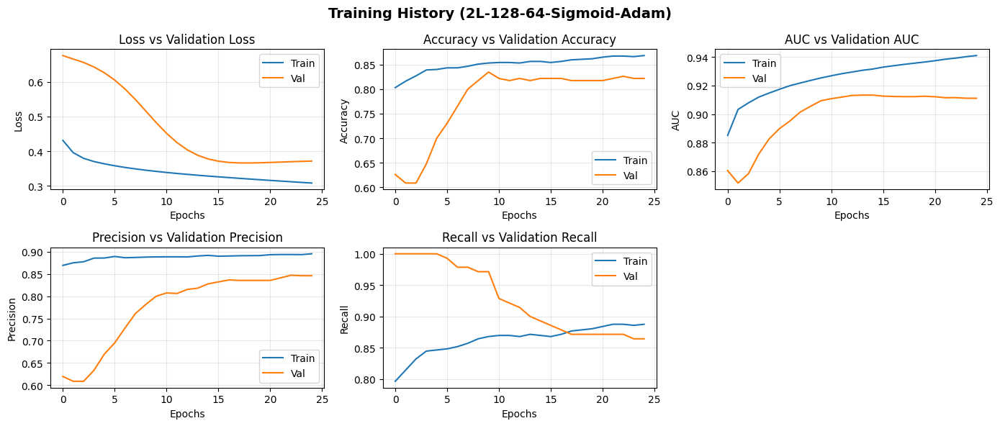


Running 2L-128-64-ReLU-Drop0.1...


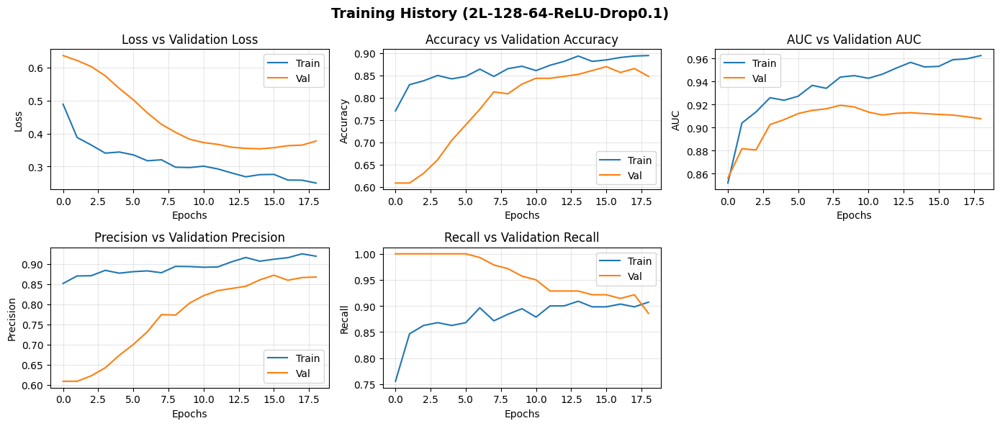


Running 2L-128-64-ReLU-Drop0.5...


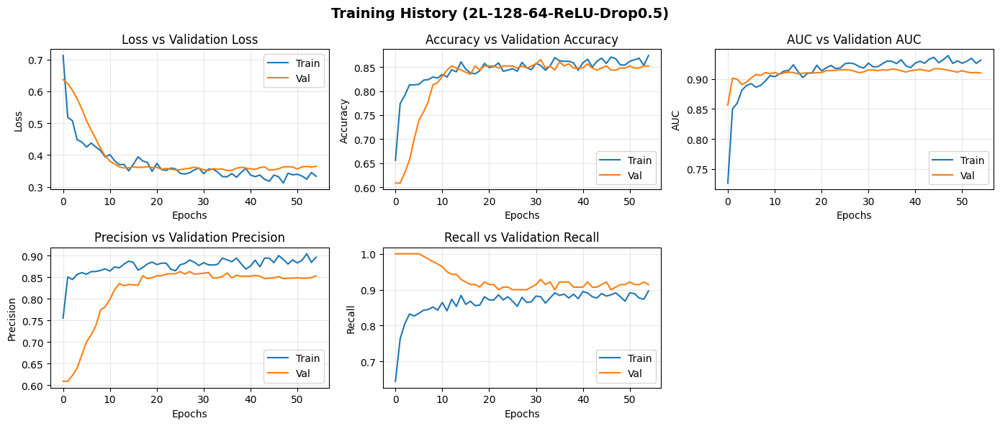


Running 2L-128-64-ReLU-SGD...


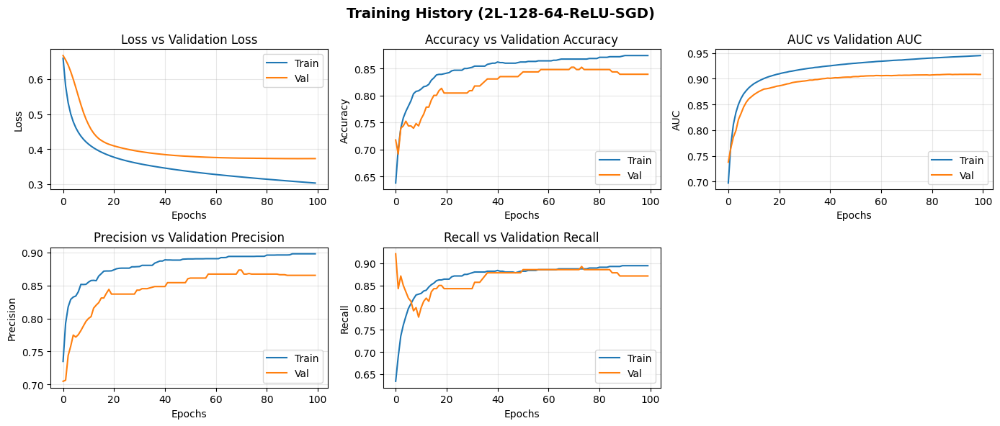


Running 2L-128-64-ReLU-RMSprop...


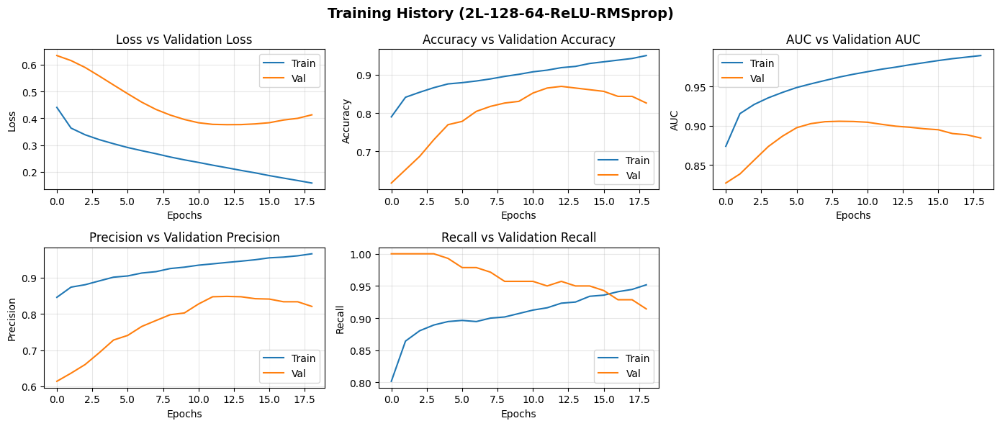


Running 2L-128-64-ReLU-Adamax...


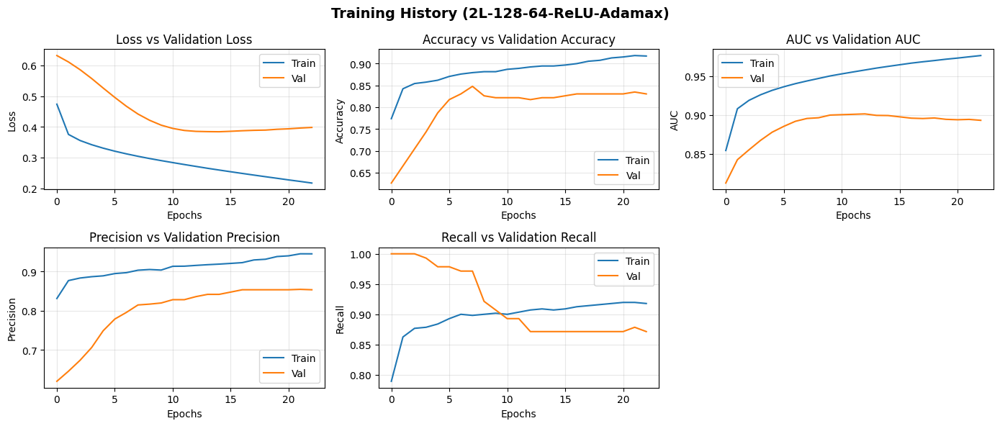


Running 2L-128-64-ReLU-Adam-LR0.01...


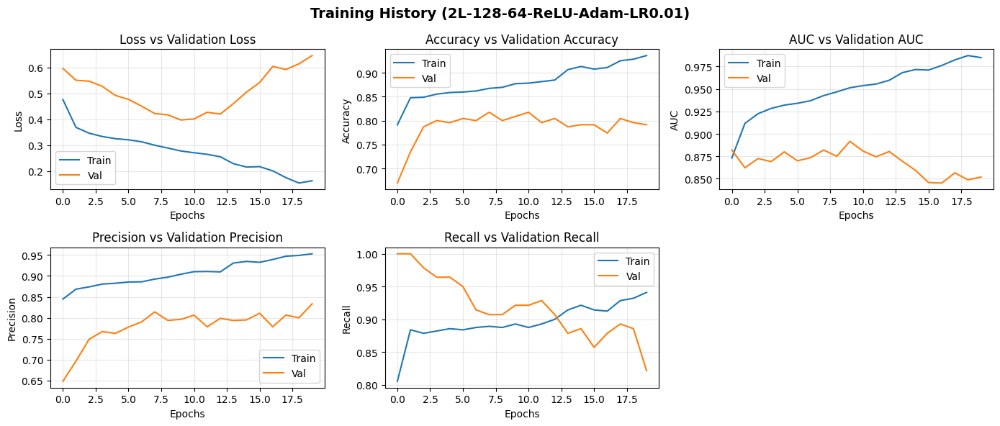


Running 2L-128-64-ReLU-Adam-LR0.0001...


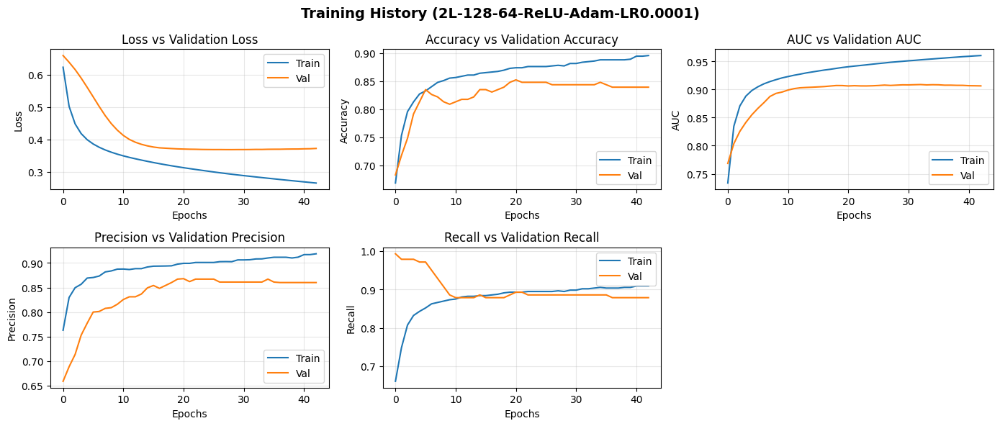


Running 2L-128-64-ReLU-Adam-Batch16...


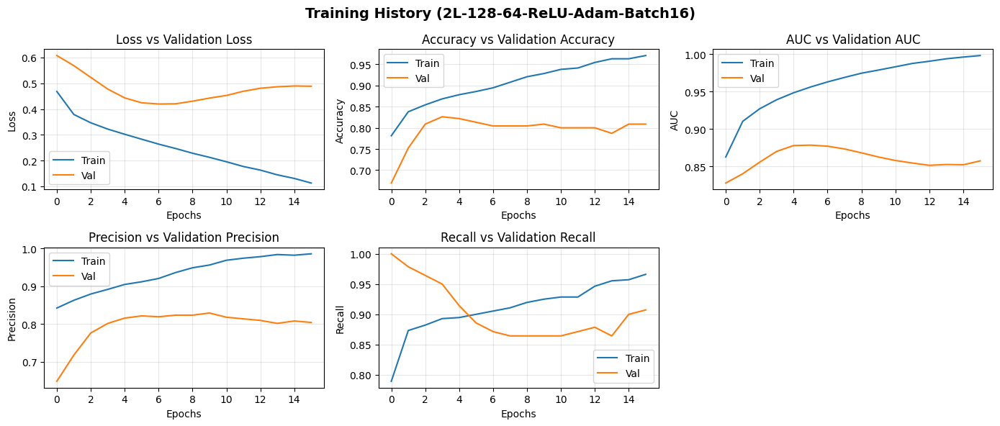


Running 2L-128-64-ReLU-Adam-Batch64...


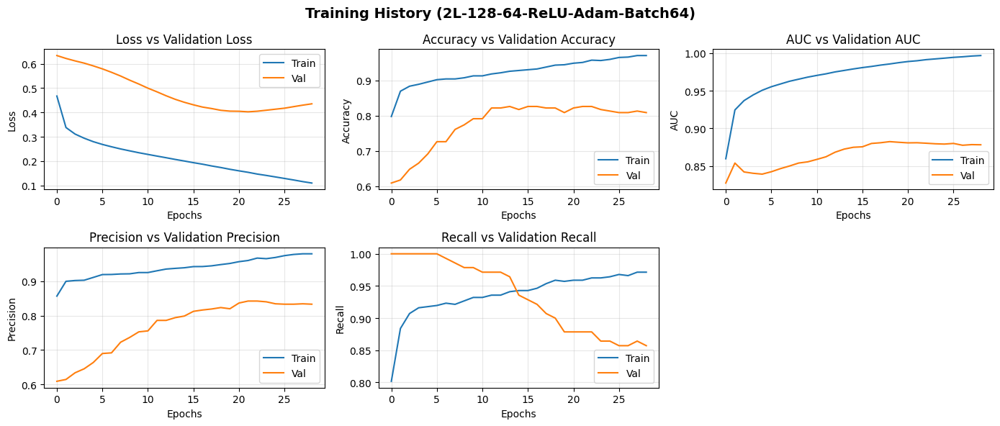

1 experiment(s) excluded due to 100% recall

Experiments Results
#   Experiment                                               Train Acc   Test Acc   Test AUC  Precision     Recall      Gap  Epochs     Time
-------------------------------------------------------------------------------------------------------------------------------------------------
1   1L-64-ReLU-Adam                                              87.05%      86.11%      94.36%      86.10%      92.00%     0.94%      25     2.1s ★
2   1L-128-ReLU-Adam                                             87.92%      86.81%      93.72%      87.03%      92.00%     1.12%      29     2.3s  
3   1L-256-ReLU-Adam                                             88.57%      86.11%      92.70%      86.49%      91.43%     2.46%      30     2.4s  
4   2L-64-32-ReLU-Adam                                           89.66%      86.81%      93.43%      84.42%      96.00%     2.86%      23     2.3s  
5   2L-128-64-ReLU-Adam                             

In [46]:
X_simple_imputation = df_simple_imputation[features_success]
y_simple_imputation = df_simple_imputation[target_column]

classes_simple_imputation = np.unique(y_simple_imputation)
weights_simple_imputation = compute_class_weight(class_weight='balanced',
                                     classes=classes_simple_imputation,
                                     y=y_simple_imputation)
cw_simple_imputation = dict(zip(classes_simple_imputation, weights_simple_imputation))
print(f"\nClass weights: {cw_simple_imputation}")

X_train_simple_imputation, X_test_simple_imputation, y_train_simple_imputation, y_test_simple_imputation = train_test_split(
    X_simple_imputation, y_simple_imputation,
    test_size=0.2,
    random_state=42,
    stratify=y_simple_imputation
)

scaler_simple_imputation = MinMaxScaler()
X_train_simple_imputation_sc = scaler_simple_imputation.fit_transform(X_train_simple_imputation)
X_test_simple_imputation_sc = scaler_simple_imputation.transform(X_test_simple_imputation)

a4_model, a4_best_architecture_results, a4_best_architecture_exp_parameters = run_experiments(experiments, X_train_simple_imputation_sc, y_train_simple_imputation, X_test_simple_imputation_sc, y_test_simple_imputation, cw_simple_imputation)

## Approach #5: Single Iterative Imputer

In [47]:
df_single_iterative_imputer = df_original.copy()

# Drop missingness flags if they exist
df_single_iterative_imputer = df_single_iterative_imputer.drop(
    columns=['hs_avg_missing', 'math_score_missing'],
    errors='ignore'
)

# Define all columns to impute
all_cols = df_single_iterative_imputer.drop(columns=['FirstYearPersistence']).columns.tolist()

print(f"Columns to impute: {all_cols}")
print(f"\nMissing before imputation:")
print(df_single_iterative_imputer.isnull().sum())

# Apply single IterativeImputer to all columns at once  
iter_imp = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=20,
    tol=1e-2,
    random_state=42
)

# Fit and transform all feature columns
df_iter_cols = df_single_iterative_imputer[all_cols].copy()
df_iter_imputed = pd.DataFrame(
    iter_imp.fit_transform(df_iter_cols),
    columns=all_cols,
    index=df_iter_cols.index
)

# Fill imputed values back
df_single_iterative_imputer[all_cols] = df_iter_imputed

# Round categorical columns back to valid integers
categorical_cols = ['First Language', 'Previous Education',
                    'Age Group', 'English Grade']

for col in categorical_cols:
    df_single_iterative_imputer[col] = df_single_iterative_imputer[col].round().clip(
        df_original[col].min(),
        df_original[col].max()
    ).astype(int)

print(f"\nShape: {df_single_iterative_imputer.shape}")
print(f"Total missing: {df_single_iterative_imputer.isnull().sum().sum()}")
print(f"\nMissing per column:")
print(df_single_iterative_imputer.isnull().sum())

Columns to impute: ['First Term Gpa', 'Second Term Gpa', 'First Language', 'Funding', 'FastTrack', 'Coop', 'Residency', 'Gender', 'Previous Education', 'Age Group', 'High School Average Mark', 'Math Score', 'English Grade']

Missing before imputation:
First Term Gpa               17
Second Term Gpa             160
First Language              111
Funding                       0
FastTrack                     0
Coop                          0
Residency                     0
Gender                        0
Previous Education           92
Age Group                     4
High School Average Mark    743
Math Score                  462
English Grade                45
FirstYearPersistence          0
dtype: int64

Shape: (1437, 14)
Total missing: 0

Missing per column:
First Term Gpa              0
Second Term Gpa             0
First Language              0
Funding                     0
FastTrack                   0
Coop                        0
Residency                   0
Gender              

Average GPA distribution:
count    1437.000000
mean        2.741090
std         1.159727
min        -0.242144
25%         2.104833
50%         2.961539
75%         3.635416
max         4.638735
Name: Average Gpa, dtype: float64

Threshold GPA >= 1.5:
  GPA only:          1210 students (84.2%)
  GPA + Persistence: 1078 students (75.0%)

Threshold GPA >= 2.0:
  GPA only:          1111 students (77.3%)
  GPA + Persistence: 1009 students (70.2%)

Threshold GPA >= 2.5:
  GPA only:          945 students (65.8%)
  GPA + Persistence: 875 students (60.9%)

Threshold GPA >= 3.0:
  GPA only:          701 students (48.8%)
  GPA + Persistence: 661 students (46.0%)
Student Success Distribution:
Student_Success
1    875
0    562
Name: count, dtype: int64
Student_Success
1    0.608907
0    0.391093
Name: proportion, dtype: float64

Breakdown:
Persisted AND GPA >= 2.5: 875
Did not persist:                  299
Persisted but low GPA:            263
Did not persist but high GPA:     70
interval columns n

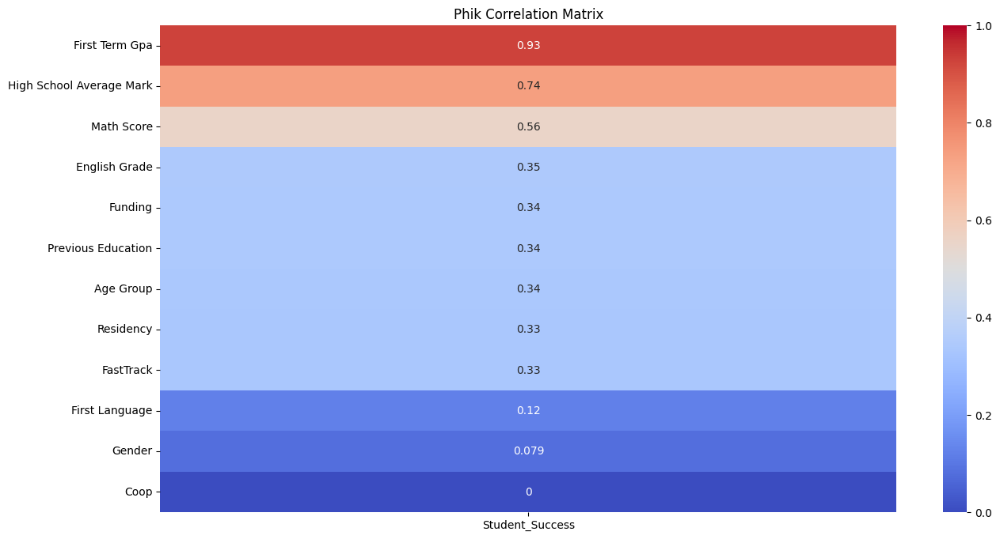

Threshold: 0.25
Selected features: 9
Excluded features: 3

Selected: ['First Term Gpa', 'High School Average Mark', 'Math Score', 'English Grade', 'Funding', 'Previous Education', 'Age Group', 'Residency', 'FastTrack']


In [48]:
df_single_iterative_imputer['Average Gpa'] = (df_single_iterative_imputer['First Term Gpa'] + df_single_iterative_imputer['Second Term Gpa']) / 2

print("Average GPA distribution:")
print(df_single_iterative_imputer['Average Gpa'].describe())

for threshold in [1.5, 2.0, 2.5, 3.0]:
    gpa_pass = (df_single_iterative_imputer['Average Gpa'] >= threshold).sum()
    combined = ((df_single_iterative_imputer['Average Gpa'] >= threshold) & 
                (df_single_iterative_imputer['FirstYearPersistence'] == 1)).sum()
    print(f"\nThreshold GPA >= {threshold}:")
    print(f"  GPA only:          {gpa_pass} students ({gpa_pass/len(df_single_iterative_imputer)*100:.1f}%)")
    print(f"  GPA + Persistence: {combined} students ({combined/len(df_single_iterative_imputer)*100:.1f}%)")

threshold = 2.5

df_single_iterative_imputer['Student_Success'] = ((df_single_iterative_imputer['Average Gpa'] >= threshold) & (df_single_iterative_imputer['FirstYearPersistence'] == 1)).astype(int)

# Verify distribution
print("Student Success Distribution:")
print(df_single_iterative_imputer['Student_Success'].value_counts())
print(df_single_iterative_imputer['Student_Success'].value_counts(normalize=True))

# Cross check with components
print(f"\nBreakdown:")
print(f"Persisted AND GPA >= {threshold}: {(df_single_iterative_imputer['Student_Success']==1).sum()}")
print(f"Did not persist:                  {(df_single_iterative_imputer['FirstYearPersistence']==0).sum()}")
print(f"Persisted but low GPA:            {((df_single_iterative_imputer['FirstYearPersistence']==1) & (df_single_iterative_imputer['Average Gpa'] < threshold)).sum()}")
print(f"Did not persist but high GPA:     {((df_single_iterative_imputer['FirstYearPersistence']==0) & (df_single_iterative_imputer['Average Gpa'] >= threshold)).sum()}")

always_exclude = [
    'Student_Success',      # target
    'FirstYearPersistence', # used to create target
    'Average Gpa',          # used to create target
    'Second Term Gpa',      # used to create Average GPA
    'hs_avg_missing',       # flag columns
    'math_score_missing'
]

features_success, scores_success = select_features_phik(
    df=df_single_iterative_imputer,
    target_col='Student_Success',
    threshold=0.25,
    exclude_cols=always_exclude,
    verbose=True
)


Class weights: {np.int64(0): np.float64(1.2784697508896796), np.int64(1): np.float64(0.8211428571428572)}

Running 1L-64-ReLU-Adam...


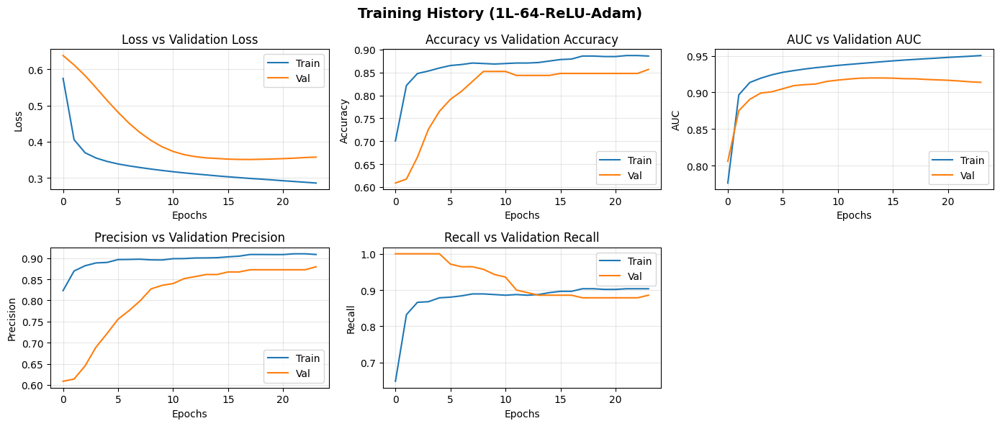


Running 1L-128-ReLU-Adam...


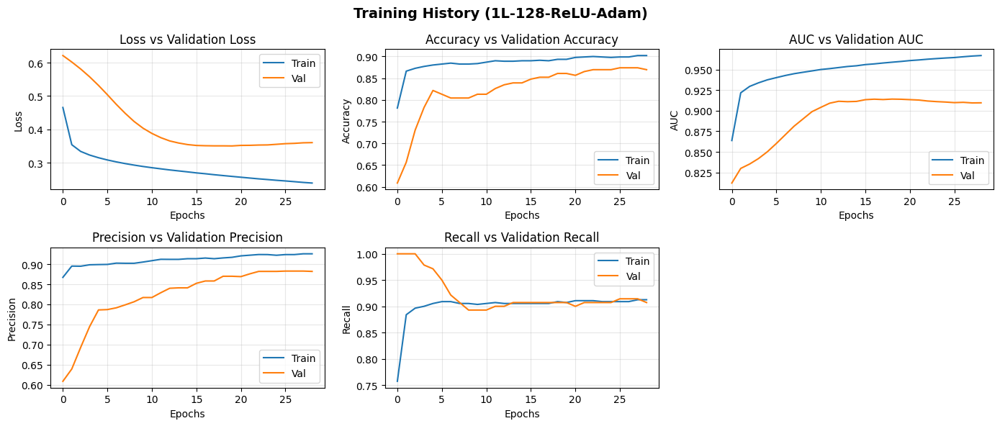


Running 1L-256-ReLU-Adam...


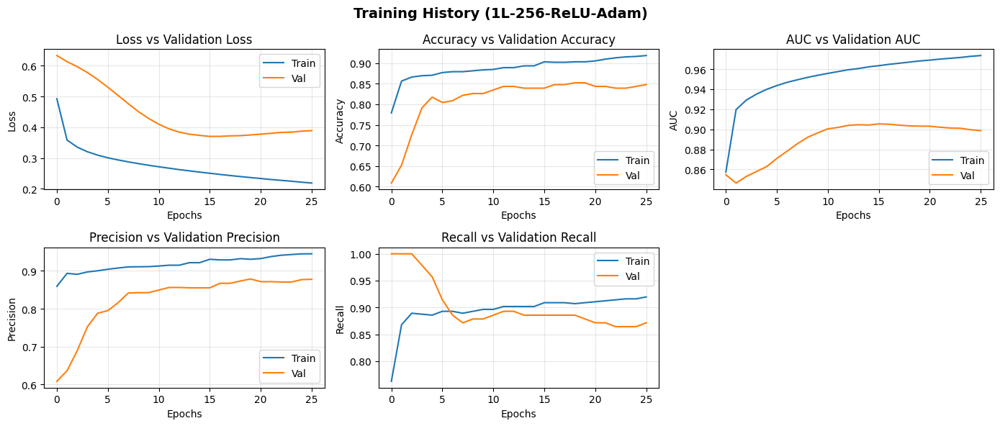


Running 2L-64-32-ReLU-Adam...


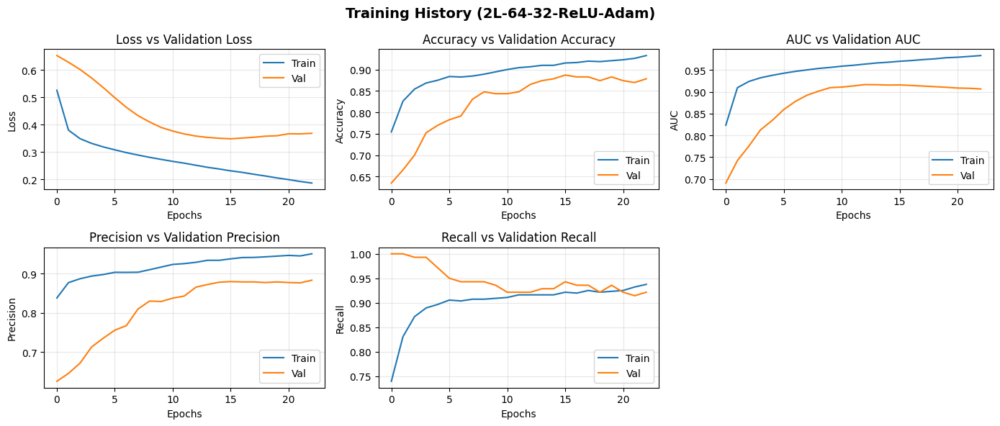


Running 2L-128-64-ReLU-Adam...


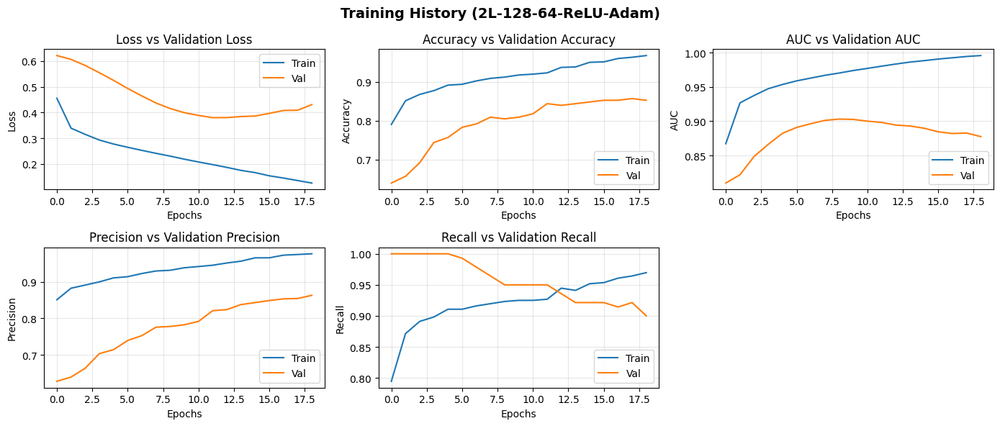


Running 2L-256-128-ReLU-Adam...


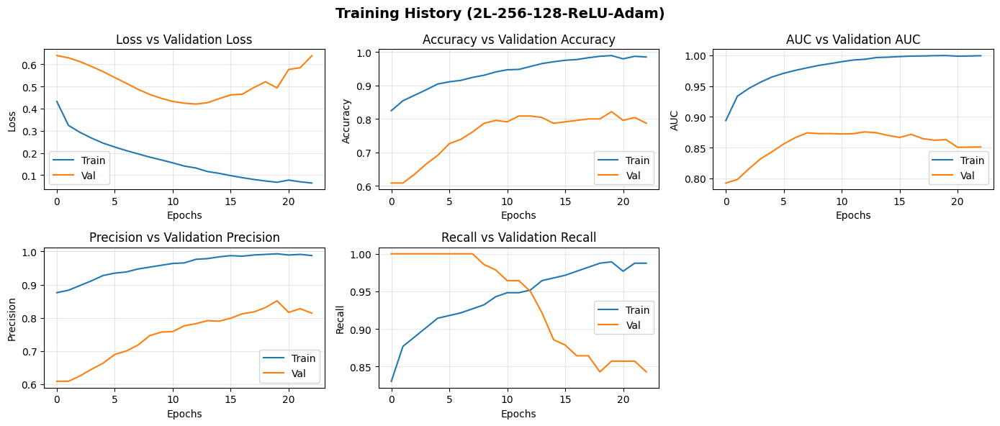


Running 3L-128-64-32-ReLU-Adam...


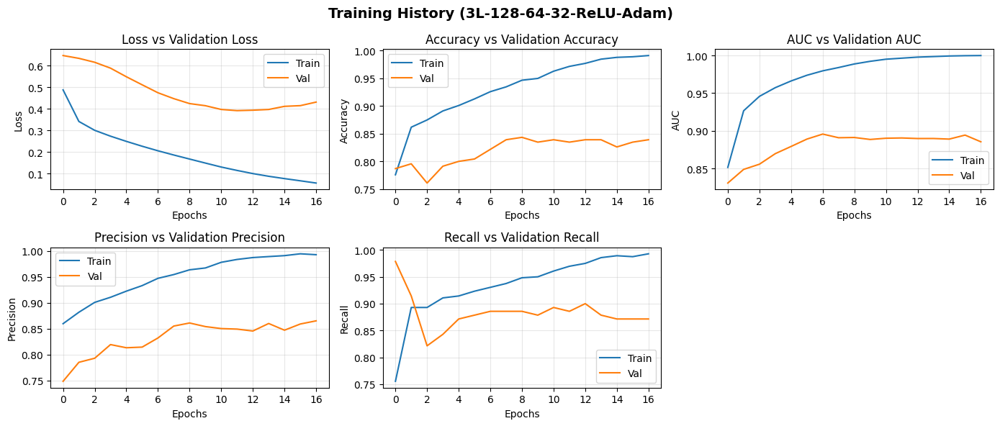


Running 3L-256-128-64-ReLU-Adam...


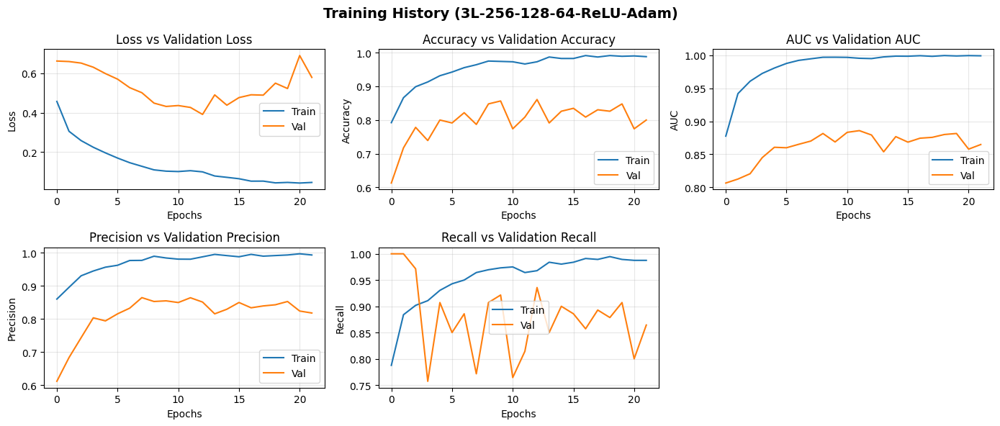


Running 2L-128-64-Tanh-Adam...


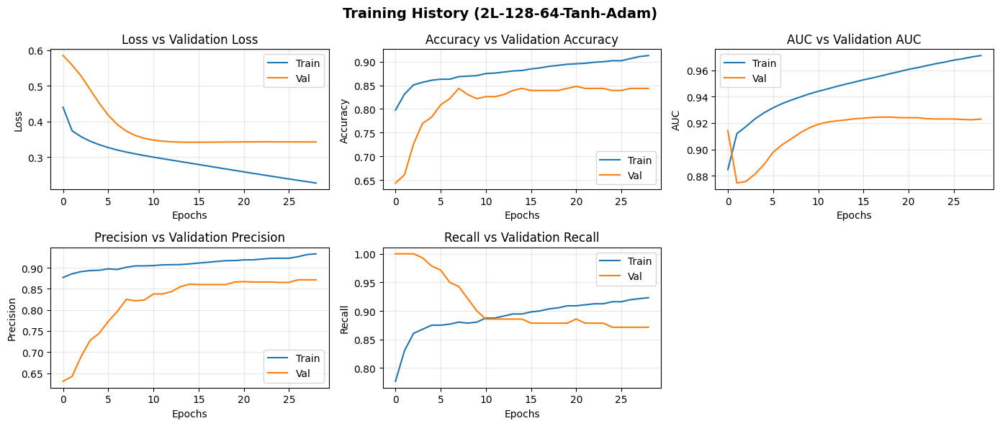


Running 2L-128-64-ELU-Adam...


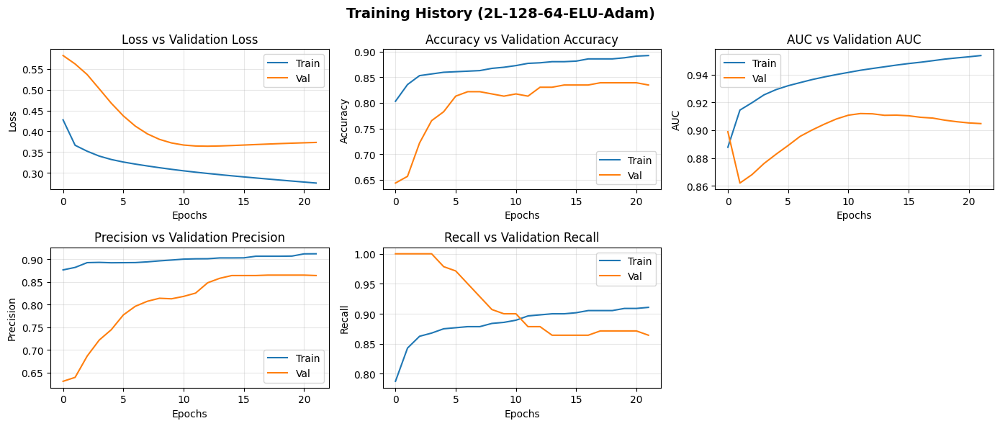


Running 2L-128-64-Sigmoid-Adam...


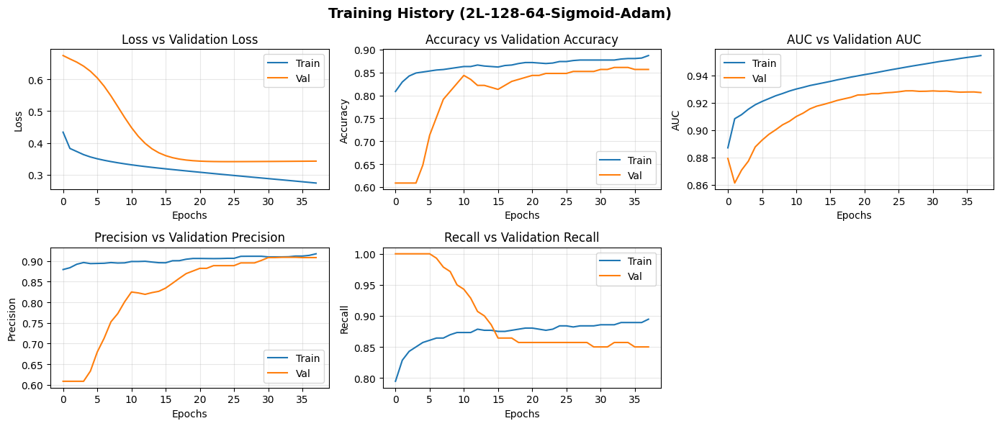


Running 2L-128-64-ReLU-Drop0.1...


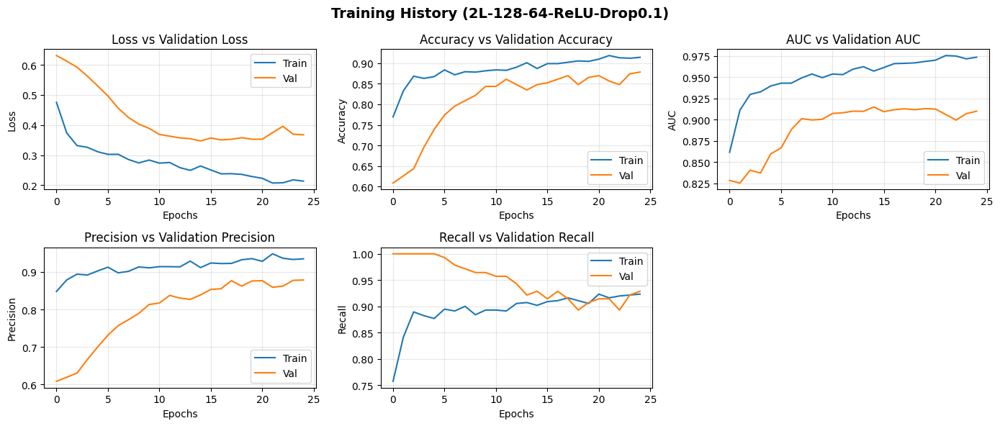


Running 2L-128-64-ReLU-Drop0.5...


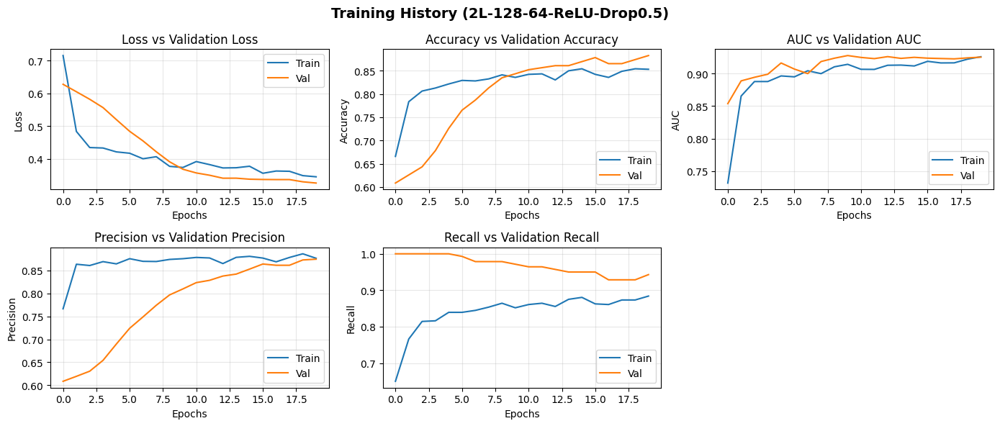


Running 2L-128-64-ReLU-SGD...


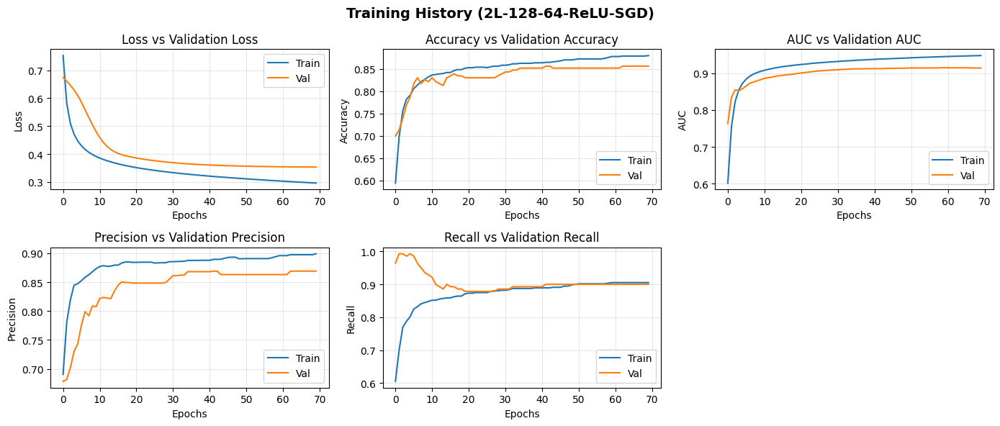


Running 2L-128-64-ReLU-RMSprop...


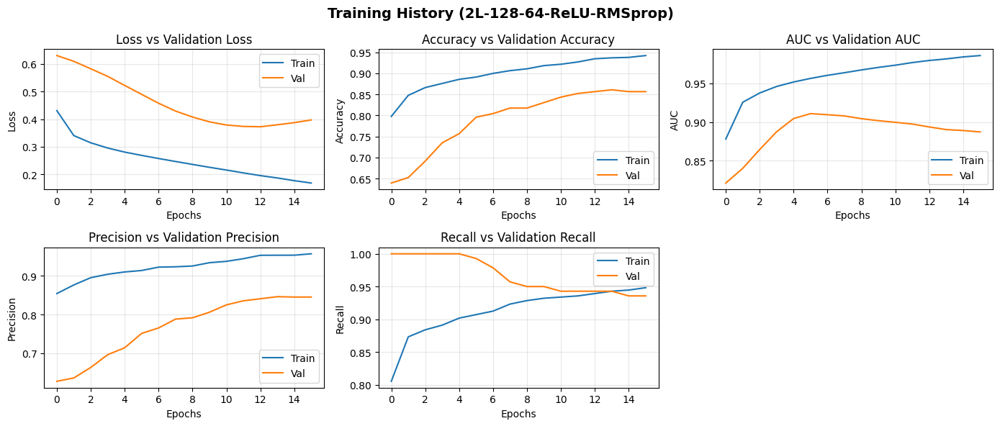


Running 2L-128-64-ReLU-Adamax...


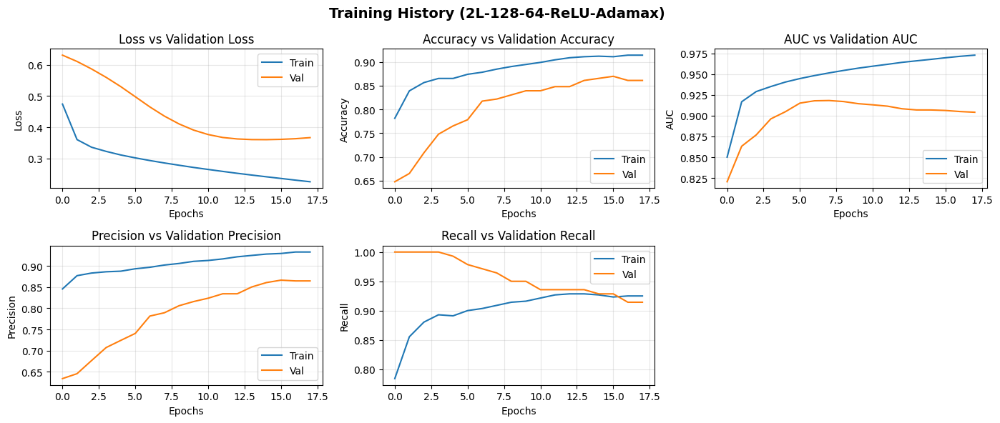


Running 2L-128-64-ReLU-Adam-LR0.01...


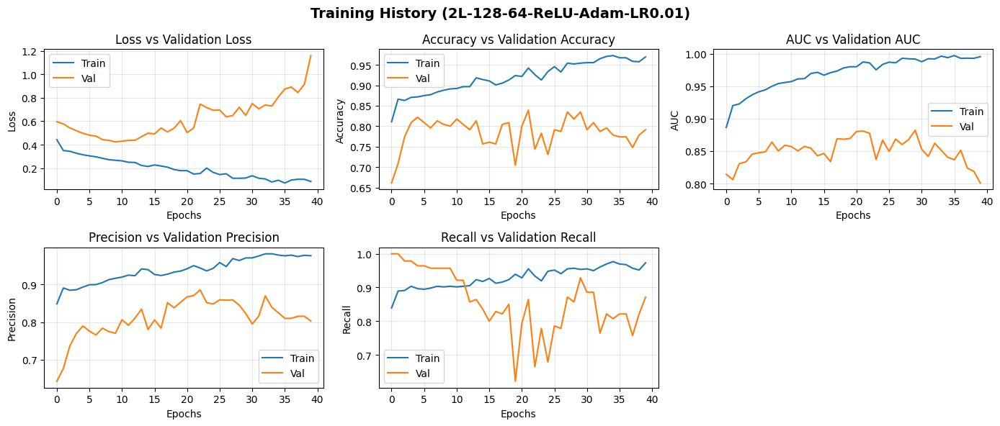


Running 2L-128-64-ReLU-Adam-LR0.0001...


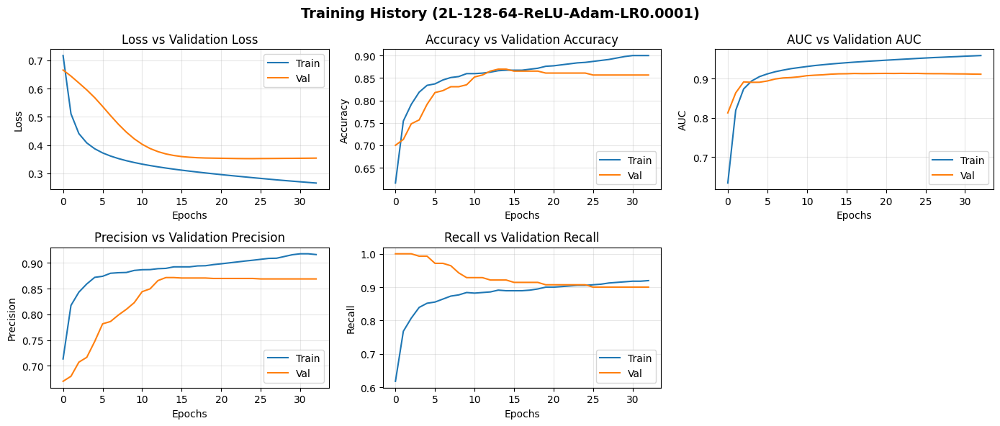


Running 2L-128-64-ReLU-Adam-Batch16...


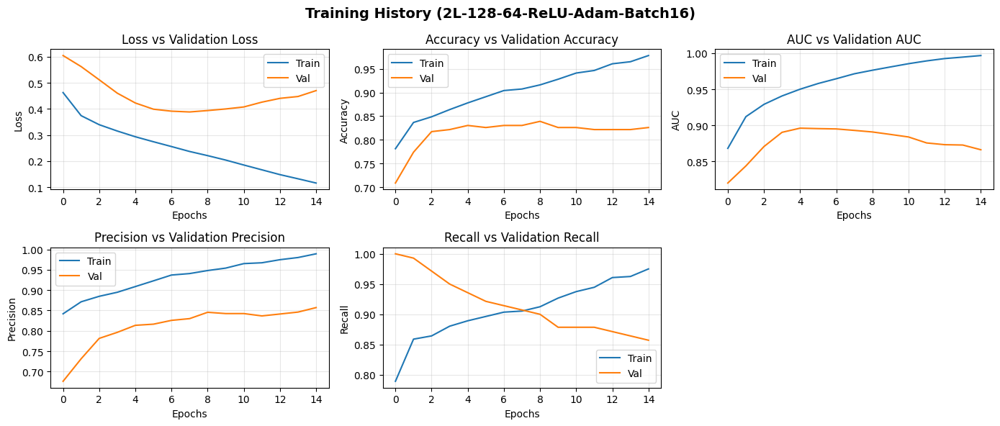


Running 2L-128-64-ReLU-Adam-Batch64...


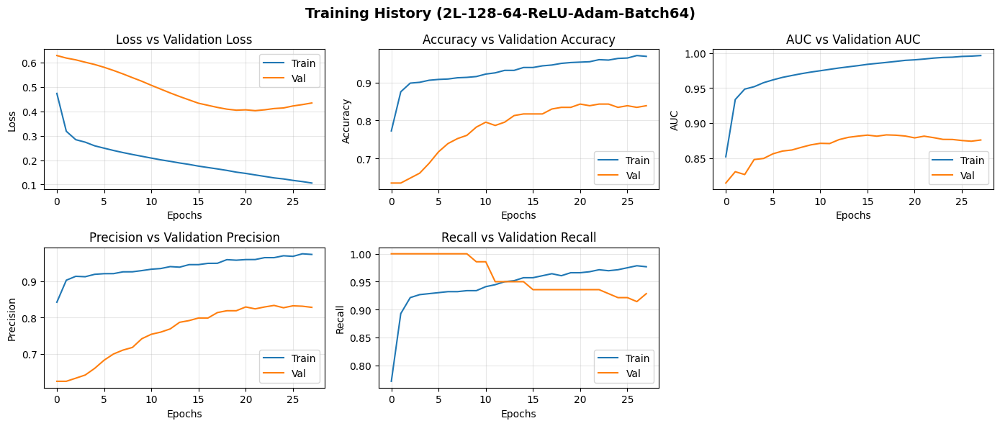


Experiments Results
#   Experiment                                               Train Acc   Test Acc   Test AUC  Precision     Recall      Gap  Epochs     Time
-------------------------------------------------------------------------------------------------------------------------------------------------
1   1L-64-ReLU-Adam                                              87.16%      87.85%      94.79%      88.04%      92.57%     0.69%      24     2.1s ★
2   1L-128-ReLU-Adam                                             89.34%      89.24%      94.67%      88.71%      94.29%     0.10%      29     2.3s  
3   1L-256-ReLU-Adam                                             90.32%      88.19%      94.25%      88.11%      93.14%     2.12%      26     2.3s  
4   2L-64-32-ReLU-Adam                                           90.64%      86.46%      94.33%      86.56%      92.00%     4.18%      23     2.3s  
5   2L-128-64-ReLU-Adam                                          91.19%      84.72%      93.87% 

In [49]:
X_single_iterative_imputer = df_single_iterative_imputer[features_success]
y_single_iterative_imputer = df_single_iterative_imputer[target_column]

classes_single_iterative_imputer = np.unique(y_single_iterative_imputer)
weights_single_iterative_imputer = compute_class_weight(class_weight='balanced', classes=classes_single_iterative_imputer, y=y_single_iterative_imputer)
cw_single_iterative_imputer = dict(zip(classes_single_iterative_imputer, weights_single_iterative_imputer))
print(f"\nClass weights: {cw_single_iterative_imputer}")

X_train_single_iterative_imputer, X_test_single_iterative_imputer, y_train_single_iterative_imputer, y_test_single_iterative_imputer = train_test_split(
    X_single_iterative_imputer, y_single_iterative_imputer,
    test_size=0.2,
    random_state=42,
    stratify=y_single_iterative_imputer
)

scaler_single_iterative_imputer = MinMaxScaler()
X_train_single_iterative_imputer_sc = scaler_single_iterative_imputer.fit_transform(X_train_single_iterative_imputer)
X_test_single_iterative_imputer_sc = scaler_single_iterative_imputer.transform(X_test_single_iterative_imputer)
a5_model, a5_best_architecture_results, a5_best_architecture_exp_parameters = run_experiments(experiments, X_train_single_iterative_imputer_sc, y_train_single_iterative_imputer, X_test_single_iterative_imputer_sc, y_test_single_iterative_imputer, cw_single_iterative_imputer, plot_history=True)

## Approach #6: Adding Missingness Flags

In [50]:
df_missing_flags = df_original.copy()
df_missing_flags = df_missing_flags.drop(
    columns=['hs_avg_missing', 'math_score_missing'],
    errors='ignore'
)

missing_cols = df_missing_flags.columns[df_missing_flags.isnull().any()].tolist()
missing_cols = [c for c in missing_cols if c != 'FirstYearPersistence']

print(f"Columns with missing values:")
for col in missing_cols:
    count = df_missing_flags[col].isnull().sum()
    pct   = count / len(df_missing_flags) * 100
    print(f"  {col:<30} {count:>4} rows ({pct:.2f}%)")

Columns with missing values:
  First Term Gpa                   17 rows (1.18%)
  Second Term Gpa                 160 rows (11.13%)
  First Language                  111 rows (7.72%)
  Previous Education               92 rows (6.40%)
  Age Group                         4 rows (0.28%)
  High School Average Mark        743 rows (51.70%)
  Math Score                      462 rows (32.15%)
  English Grade                    45 rows (3.13%)


In [51]:
for col in missing_cols:
    flag_col = col.lower().replace(' ', '_') + '_missing'
    df_missing_flags[flag_col] = df_missing_flags[col].isnull().astype(int)
    print(f"Added flag: {flag_col} — {df_missing_flags[flag_col].sum()} flagged rows")

df_missing_flags[missing_cols] = df_missing_flags[missing_cols].fillna(0)

Added flag: first_term_gpa_missing — 17 flagged rows
Added flag: second_term_gpa_missing — 160 flagged rows
Added flag: first_language_missing — 111 flagged rows
Added flag: previous_education_missing — 92 flagged rows
Added flag: age_group_missing — 4 flagged rows
Added flag: high_school_average_mark_missing — 743 flagged rows
Added flag: math_score_missing — 462 flagged rows
Added flag: english_grade_missing — 45 flagged rows


Average GPA distribution:
count    1437.000000
mean        2.659286
std         1.237063
min         0.000000
25%         1.985715
50%         2.912500
75%         3.618371
max         4.500000
Name: Average Gpa, dtype: float64

Threshold GPA >= 1.5:
  GPA only:          1169 students (81.4%)
  GPA + Persistence: 1078 students (75.0%)

Threshold GPA >= 2.0:
  GPA only:          1074 students (74.7%)
  GPA + Persistence: 1008 students (70.1%)

Threshold GPA >= 2.5:
  GPA only:          919 students (64.0%)
  GPA + Persistence: 874 students (60.8%)

Threshold GPA >= 3.0:
  GPA only:          686 students (47.7%)
  GPA + Persistence: 660 students (45.9%)
Student Success Distribution:
Student_Success
1    874
0    563
Name: count, dtype: int64
Student_Success
1    0.608212
0    0.391788
Name: proportion, dtype: float64

Breakdown:
Persisted AND GPA >= 2.5: 874
Did not persist:                  299
Persisted but low GPA:            264
Did not persist but high GPA:     45
interval columns n

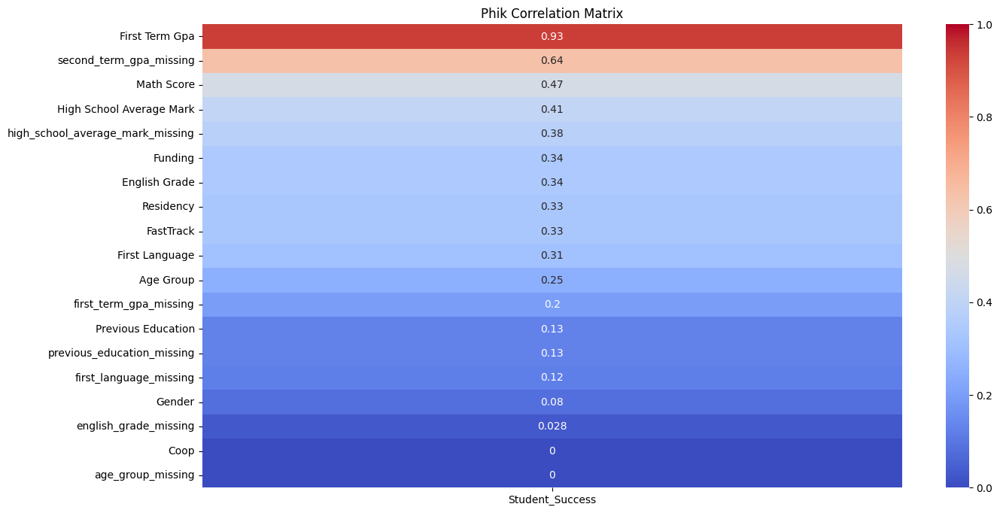

Threshold: 0.25
Selected features: 11
Excluded features: 8

Selected: ['First Term Gpa', 'second_term_gpa_missing', 'Math Score', 'High School Average Mark', 'high_school_average_mark_missing', 'Funding', 'English Grade', 'Residency', 'FastTrack', 'First Language', 'Age Group']


In [52]:
df_missing_flags['Average Gpa'] = (df_missing_flags['First Term Gpa'] + df_missing_flags['Second Term Gpa']) / 2

print("Average GPA distribution:")
print(df_missing_flags['Average Gpa'].describe())

for threshold in [1.5, 2.0, 2.5, 3.0]:
    gpa_pass = (df_missing_flags['Average Gpa'] >= threshold).sum()
    combined = ((df_missing_flags['Average Gpa'] >= threshold) & 
                (df_missing_flags['FirstYearPersistence'] == 1)).sum()
    print(f"\nThreshold GPA >= {threshold}:")
    print(f"  GPA only:          {gpa_pass} students ({gpa_pass/len(df_missing_flags)*100:.1f}%)")
    print(f"  GPA + Persistence: {combined} students ({combined/len(df_missing_flags)*100:.1f}%)")

threshold = 2.5

df_missing_flags['Student_Success'] = ((df_missing_flags['Average Gpa'] >= threshold) & (df_missing_flags['FirstYearPersistence'] == 1)).astype(int)

# Verify distribution
print("Student Success Distribution:")
print(df_missing_flags['Student_Success'].value_counts())
print(df_missing_flags['Student_Success'].value_counts(normalize=True))

# Cross check with components
print(f"\nBreakdown:")
print(f"Persisted AND GPA >= {threshold}: {(df_missing_flags['Student_Success']==1).sum()}")
print(f"Did not persist:                  {(df_missing_flags['FirstYearPersistence']==0).sum()}")
print(f"Persisted but low GPA:            {((df_missing_flags['FirstYearPersistence']==1) & (df_missing_flags['Average Gpa'] < threshold)).sum()}")
print(f"Did not persist but high GPA:     {((df_missing_flags['FirstYearPersistence']==0) & (df_missing_flags['Average Gpa'] >= threshold)).sum()}")

always_exclude = [
    'Student_Success',      # target
    'FirstYearPersistence', # used to create target
    'Average Gpa',          # used to create target
    'Second Term Gpa',      # used to create Average GPA
    'hs_avg_missing',       # flag columns
    'math_score_missing'
]

features_success, scores_success = select_features_phik(
    df=df_missing_flags,
    target_col='Student_Success',
    threshold=0.25,
    exclude_cols=always_exclude,
    verbose=True
)


Class weights: {np.int64(0): np.float64(1.2761989342806395), np.int64(1): np.float64(0.8220823798627003)}

Running 1L-64-ReLU-Adam...


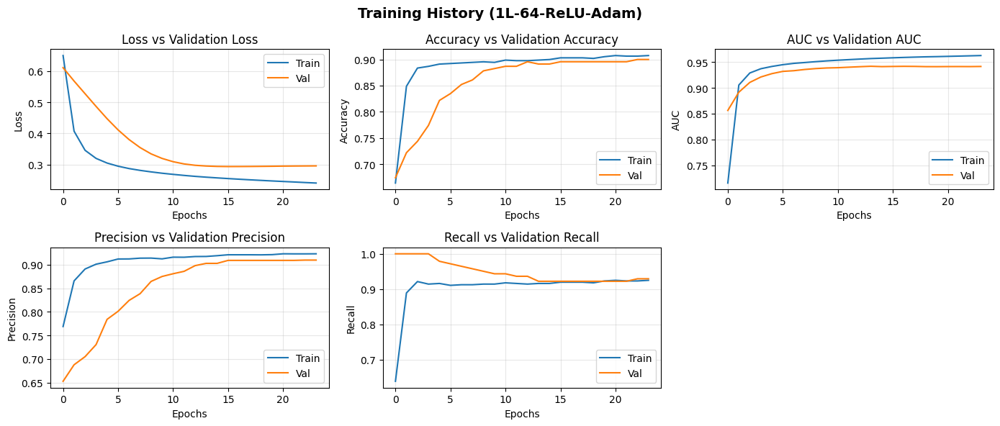


Running 1L-128-ReLU-Adam...


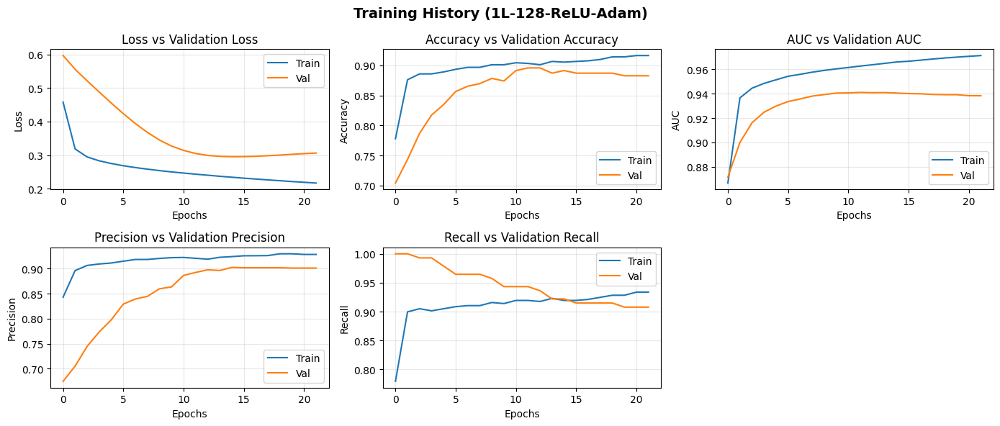


Running 1L-256-ReLU-Adam...


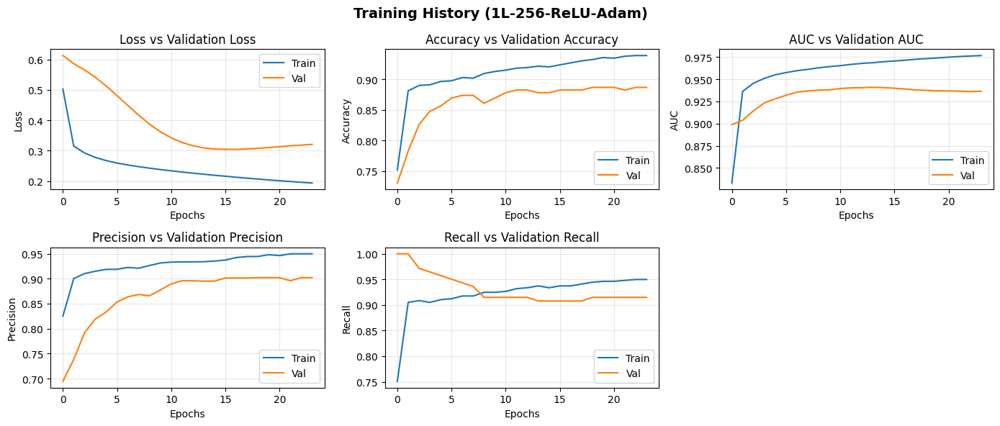


Running 2L-64-32-ReLU-Adam...


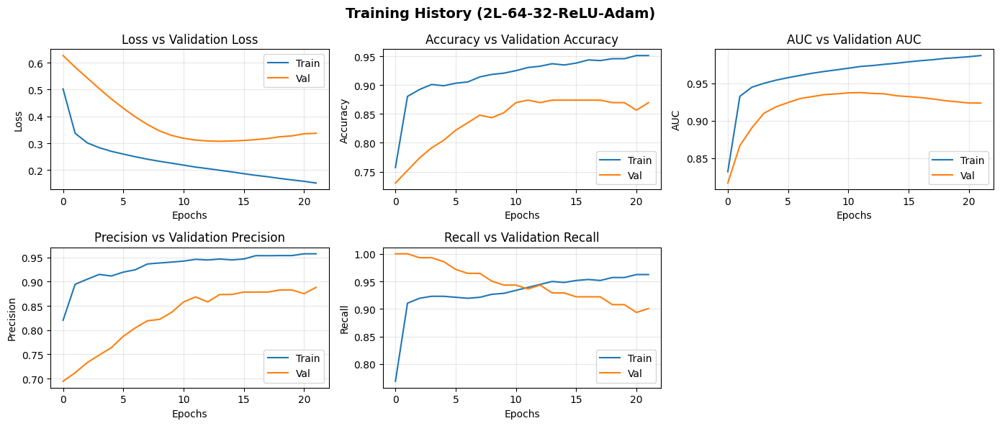


Running 2L-128-64-ReLU-Adam...


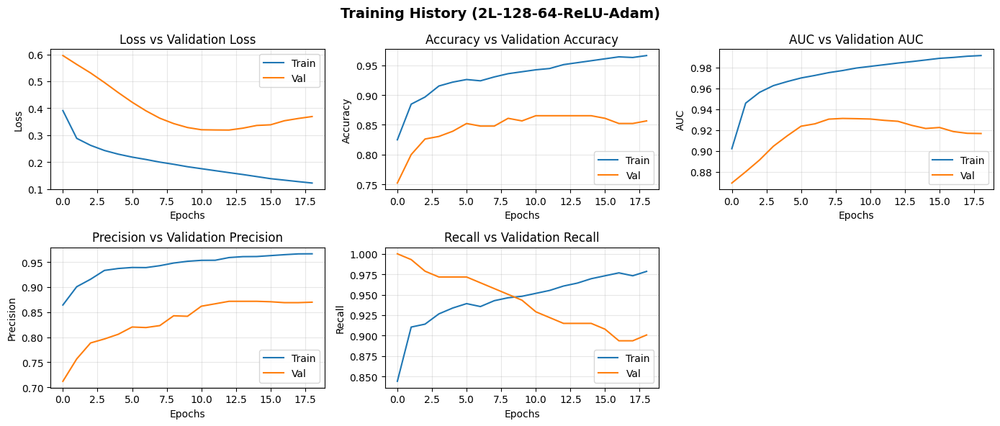


Running 2L-256-128-ReLU-Adam...


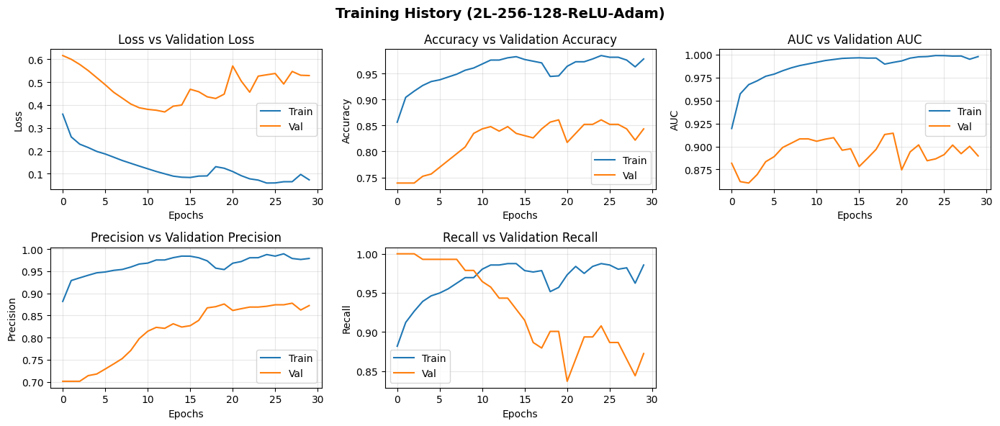


Running 3L-128-64-32-ReLU-Adam...


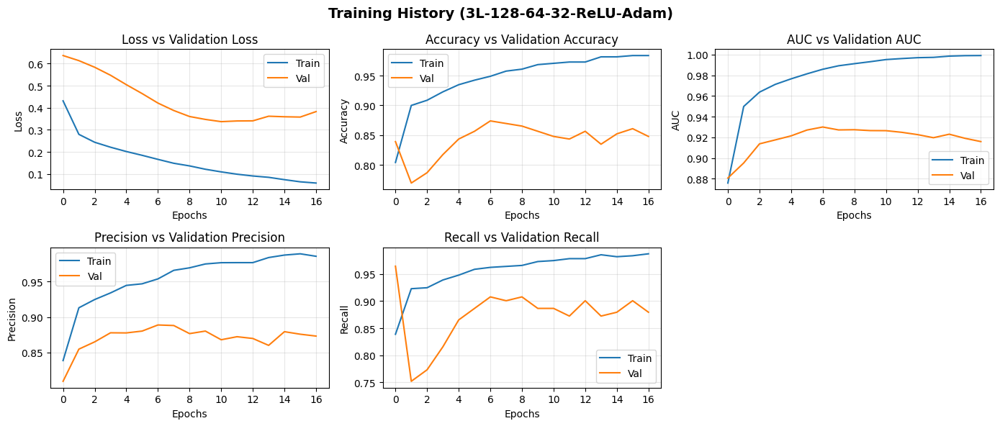


Running 3L-256-128-64-ReLU-Adam...


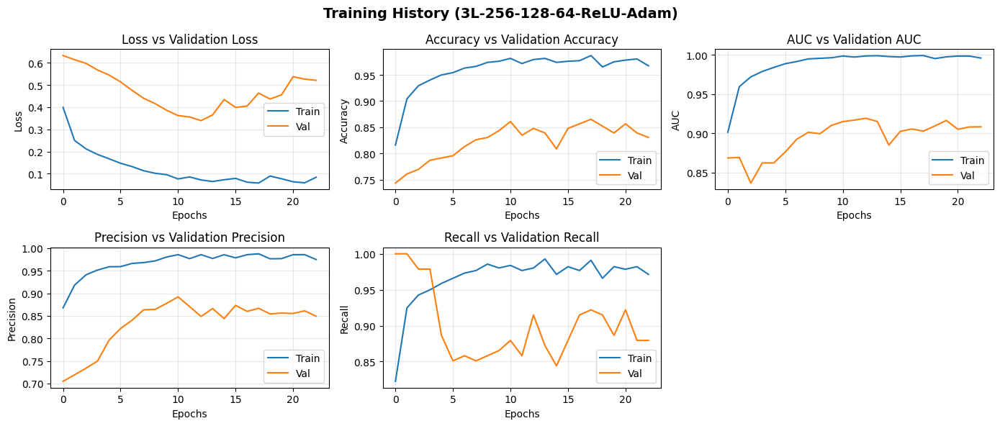


Running 2L-128-64-Tanh-Adam...


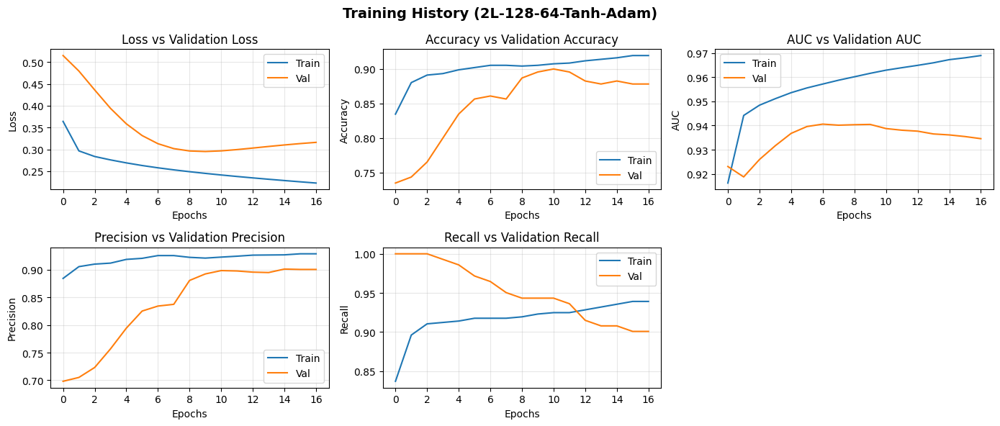


Running 2L-128-64-ELU-Adam...


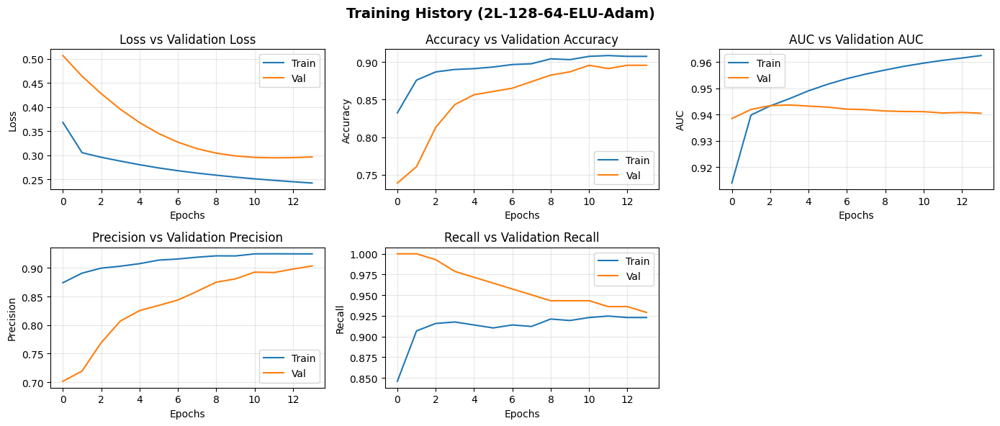


Running 2L-128-64-Sigmoid-Adam...


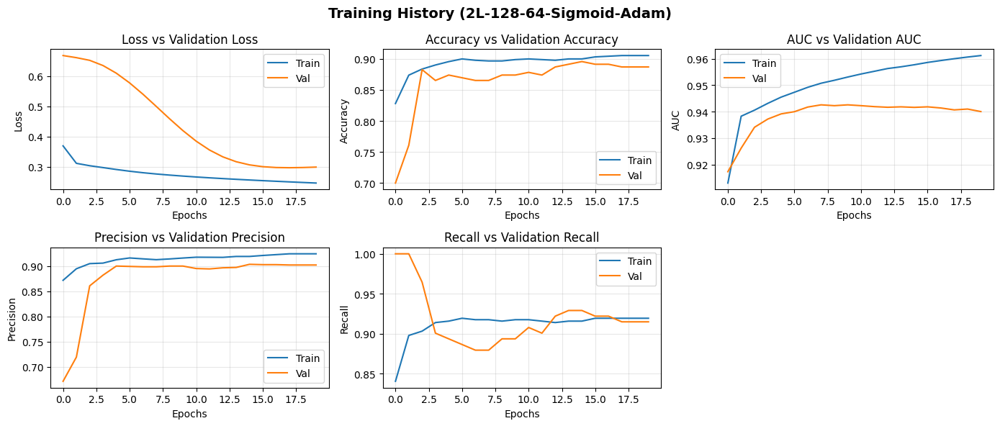


Running 2L-128-64-ReLU-Drop0.1...


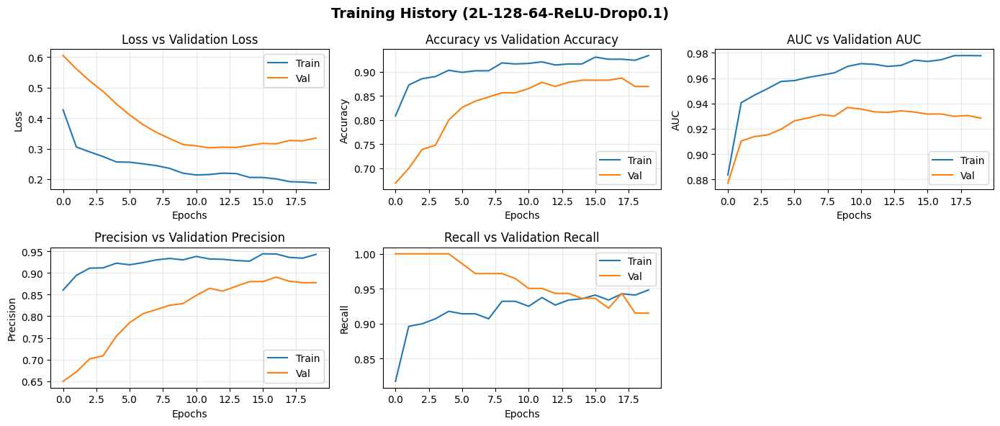


Running 2L-128-64-ReLU-Drop0.5...


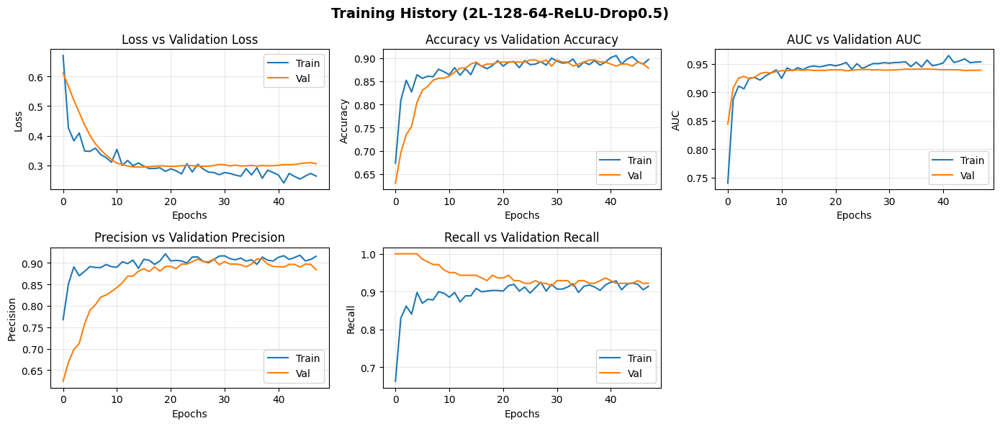


Running 2L-128-64-ReLU-SGD...


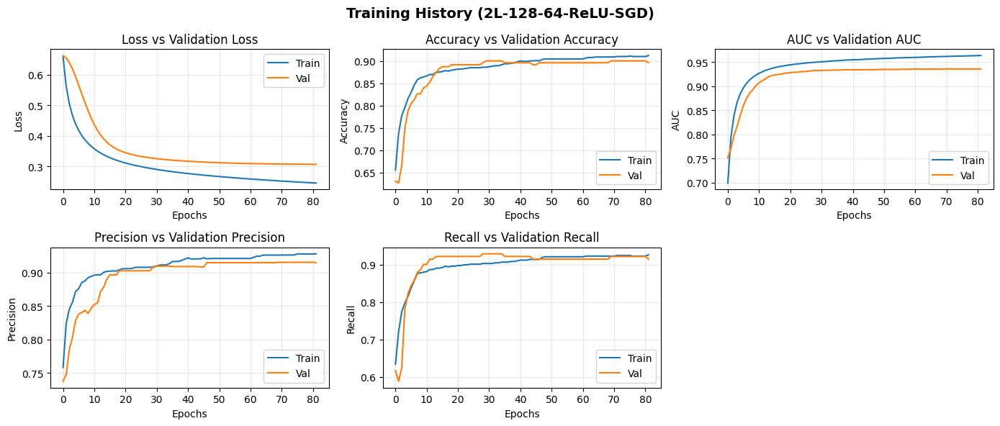


Running 2L-128-64-ReLU-RMSprop...


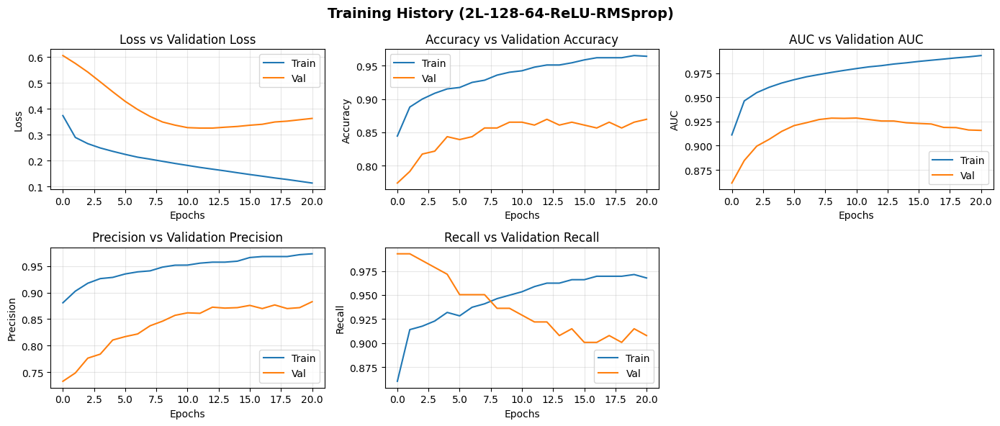


Running 2L-128-64-ReLU-Adamax...


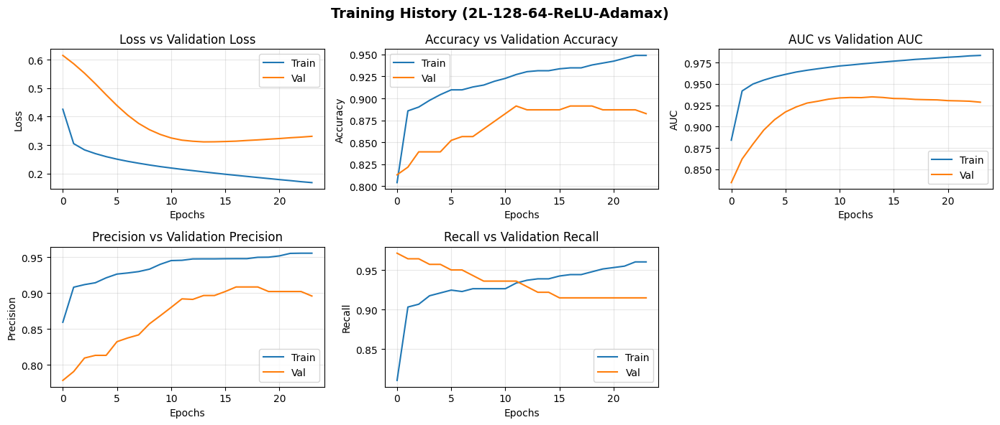


Running 2L-128-64-ReLU-Adam-LR0.01...


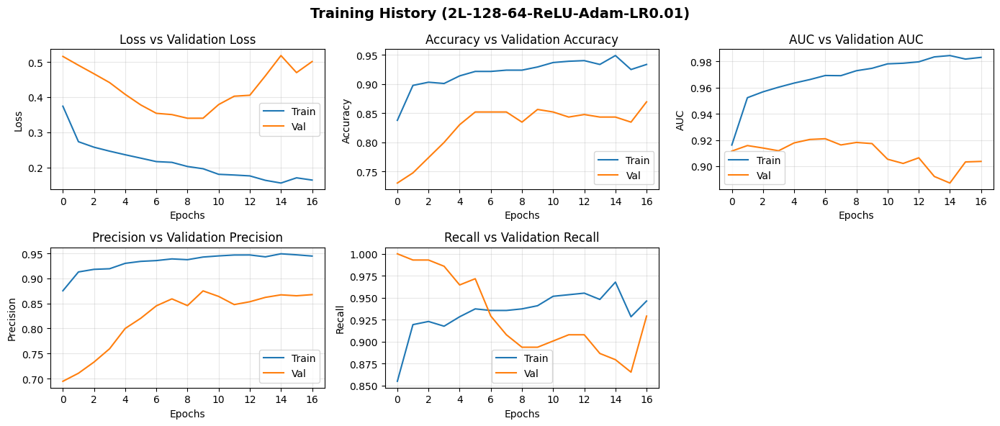


Running 2L-128-64-ReLU-Adam-LR0.0001...


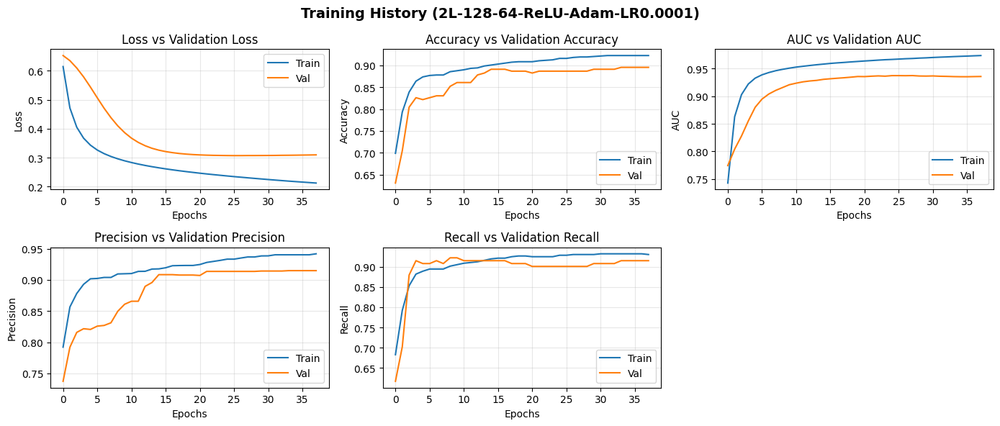


Running 2L-128-64-ReLU-Adam-Batch16...


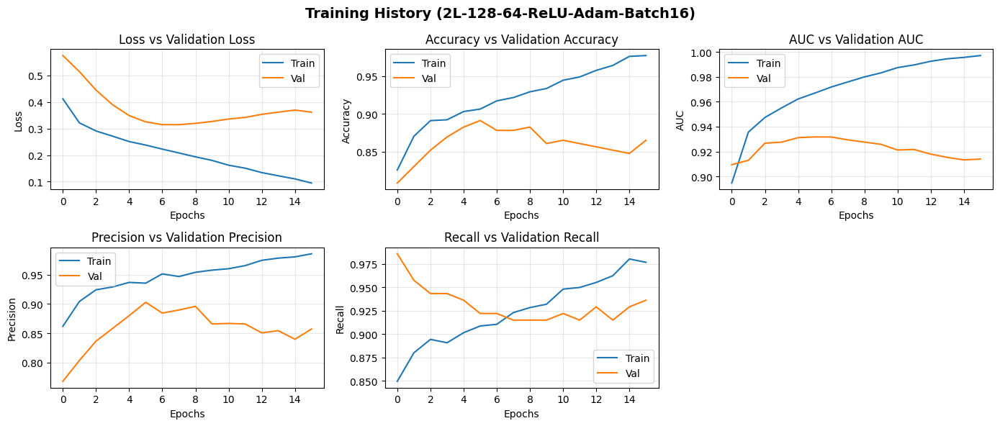


Running 2L-128-64-ReLU-Adam-Batch64...


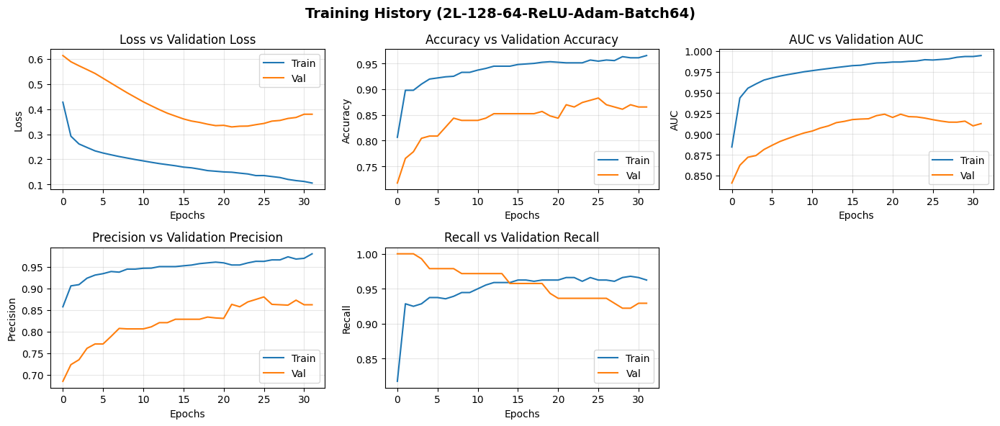


Experiments Results
#   Experiment                                               Train Acc   Test Acc   Test AUC  Precision     Recall      Gap  Epochs     Time
-------------------------------------------------------------------------------------------------------------------------------------------------
1   1L-64-ReLU-Adam                                              89.88%      87.85%      96.28%      88.46%      92.00%     2.03%      24     2.1s  
2   1L-128-ReLU-Adam                                             90.32%      89.58%      96.47%      88.36%      95.43%     0.73%      22     2.0s ★
3   1L-256-ReLU-Adam                                             92.17%      87.85%      95.94%      89.33%      90.86%     4.32%      24     2.1s  
4   2L-64-32-ReLU-Adam                                           93.04%      88.19%      95.61%      86.53%      95.43%     4.84%      22     2.2s  
5   2L-128-64-ReLU-Adam                                          93.58%      89.24%      95.85% 

In [53]:
X_missing_flags = df_missing_flags[features_success]
y_missing_flags = df_missing_flags[target_column]
classes_missing_flags   = np.unique(y_missing_flags)
weights_missing_flags   = compute_class_weight(class_weight='balanced',
                                               classes=classes_missing_flags,
                                               y=y_missing_flags)
cw_missing_flags = dict(zip(classes_missing_flags, weights_missing_flags))
print(f"\nClass weights: {cw_missing_flags}")

X_train_missing_flags, X_test_missing_flags, y_train_missing_flags, y_test_missing_flags = train_test_split(
    X_missing_flags, y_missing_flags,
    test_size=0.2,
    random_state=42,
    stratify=y_missing_flags
)

scaler_missing_flags     = MinMaxScaler()
X_train_missing_flags_sc = scaler_missing_flags.fit_transform(X_train_missing_flags)
X_test_missing_flags_sc  = scaler_missing_flags.transform(X_test_missing_flags)

a6_model, a6_best_architecture_results, a6_best_architecture_exp_parameters = run_experiments(experiments, X_train_missing_flags_sc, y_train_missing_flags, X_test_missing_flags_sc, y_test_missing_flags, cw_missing_flags, plot_history=True)